# 57 — Conference-Grade Evaluation Upgrade

**Project:** AI VPN Firewall — Thesis  
**Source pipeline:** Clean Pipeline (NB41-55)  
**Feature family:** direction_invariant_augmented (25 features)  
**Models:** XGBoost + LightGBM + CatBoost ensemble  
**Datasets:** ISCX-VPN-2016, USBVPN-2021, VNAT-2024

---

| # | Section | Key Output |
|---|---------|-----------|
| 1 | Domain Generalization Curves | `domain_generalization_curve.csv` |
| 2 | Temporal Shift Simulation | `temporal_shift_results.csv` |
| 3 | Feature Sign Reversal Heatmap | `sign_reversal_heatmap.png` |
| 4 | Domain-Invariant Feature Discovery | `domain_invariant_feature_subset.csv` |
| 5 | Domain Fingerprint Analysis | `sequence_domain_fingerprint_results.csv` |
| 6 | Adversarial Domain Confusion Test | `domain_confusion_results.csv` |
| 7 | Representation Space Visualization | `embedding_visualization.png` |
| 8 | Fourth Dataset Integration (optional) | `four_dataset_transfer_results.csv` |
| 9 | Deployment Stability Simulation | `deployment_stability_results.csv` |
| 10 | Firewall Decision Module Evaluation | `firewall_operating_points.csv` |

**Pre-computation:** Run `python run_conference_eval.py` to generate all artifacts.  
This notebook loads and visualizes the pre-computed results.


## 0. Setup

In [1]:
import sys, json, warnings, itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display, Image

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11, "figure.facecolor": "white"})

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

CONF  = ROOT / "artifacts" / "conference_eval"
FIGS  = CONF / "figures"
CLEAN = ROOT / "artifacts" / "clean_pipeline"

# Load main dataset for supplementary analysis
df = pd.read_parquet(CLEAN / "features.parquet")
META = {"flow_id", "capture_id", "dataset", "label", "split", "source_file", "app"}
FEAT_COLS = sorted([c for c in df.columns if c not in META])
DATASETS = sorted(df["dataset"].unique())

print(f"Clean pipeline: {len(df):,} flows, {len(FEAT_COLS)} features")
print(f"Conference eval dir: {CONF}")
print(f"Figures dir: {FIGS}")
print(f"Available artifacts: {[f.name for f in sorted(CONF.glob('*')) if f.is_file()]}")


Clean pipeline: 72,612 flows, 25 features
Conference eval dir: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\conference_eval
Figures dir: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\conference_eval\figures
Available artifacts: ['dataset_scaling_curve.csv', 'dataset_scaling_curve.png', 'dataset_scaling_curve_full.csv', 'dataset_scaling_summary.json', 'deployment_robustness_curves.png', 'deployment_robustness_results.csv', 'deployment_robustness_summary.json', 'deployment_stability_curve.png', 'deployment_stability_results.csv', 'domain_confusion_results.csv', 'domain_generalization_curve.csv', 'domain_invariant_feature_subset.csv', 'embedding_visualization.png', 'feature_importance_stability.csv', 'four_dataset_transfer_results.csv', 'sequence_domain_fingerprint_results.csv', 'sign_reversal_heatmap.png', 'sign_reversal_matrix.csv', 'sign_reversal_transfer_plot.png', 'sign_reversal_transfer_regression.csv', 'stable_vs_reversing_transfer.csv', 'stable_vs_reversing_

---
## Section 1 — Domain Generalization Curves

**Experiment:** Train ensemble on 1, 2, or 3 datasets. Evaluate LODO AUC on each held-out dataset.

**Key question:** Does adding more training datasets improve cross-domain transfer?


In [2]:
s1 = pd.read_csv(CONF / "domain_generalization_curve.csv")
display(s1.round(4).style.set_caption("Domain Generalization: LODO AUC by Training Configuration"))

# Aggregated summary
agg = s1.groupby("n_train_datasets")["lodo_auc"].agg(["mean", "std", "min", "max"]).round(4)
display(agg.style.set_caption("Aggregated LODO AUC by Number of Training Datasets"))


,n_train_datasets,train_datasets,test_dataset,lodo_auc,n_train_flows
0,1,iscx,usbvpn,0.159000,8260
1,1,iscx,vnat,0.780800,8260
2,1,usbvpn,iscx,0.428900,40122
3,1,usbvpn,vnat,0.661500,40122
4,1,vnat,iscx,0.355000,5675
5,1,vnat,usbvpn,0.930900,5675
6,2,iscx+usbvpn,vnat,0.767700,58413
7,2,iscx+vnat,usbvpn,0.415300,13935
8,2,usbvpn+vnat,iscx,0.459800,55828
9,3,iscx+usbvpn+vnat,iscx,0.984900,64088


,mean,std,min,max
n_train_datasets,,,,
1,0.552700,0.288600,0.159000,0.930900
2,0.547600,0.191900,0.415300,0.767700
3,0.991200,0.008900,0.984900,0.997500


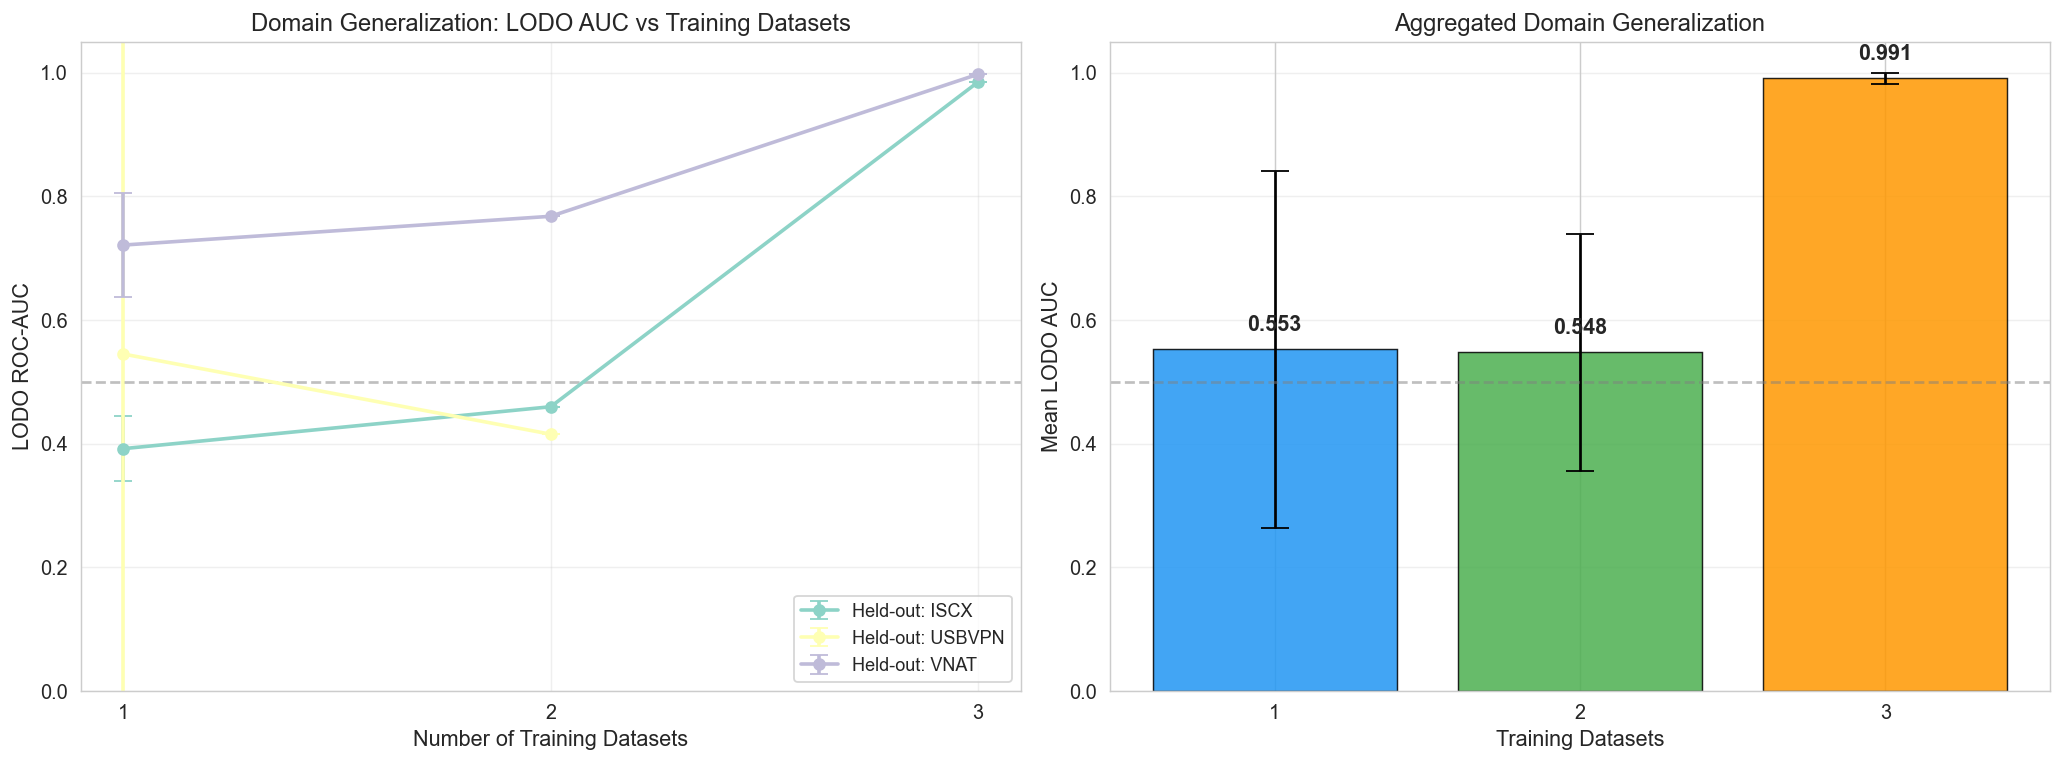


▸ 1-dataset mean LODO AUC: 0.5527
▸ 2-dataset mean LODO AUC: 0.5476
▸ Δ(2-1): -0.0051

⚠ Adding datasets does NOT reliably improve LODO — confirms structural mismatch.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: per test dataset
for test_ds in DATASETS:
    sub = s1[s1["test_dataset"] == test_ds]
    means = sub.groupby("n_train_datasets")["lodo_auc"].mean()
    stds  = sub.groupby("n_train_datasets")["lodo_auc"].std().fillna(0)
    axes[0].errorbar(means.index, means.values, yerr=stds.values,
                     marker="o", linewidth=2, capsize=5, label=f"Held-out: {test_ds.upper()}")

axes[0].set_xlabel("Number of Training Datasets", fontsize=12)
axes[0].set_ylabel("LODO ROC-AUC", fontsize=12)
axes[0].set_title("Domain Generalization: LODO AUC vs Training Datasets")
axes[0].set_xticks([1, 2, 3])
axes[0].legend(fontsize=10)
axes[0].set_ylim(0, 1.05)
axes[0].axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Random")
axes[0].grid(True, alpha=0.3)

# Right: bar chart
agg = s1.groupby("n_train_datasets")["lodo_auc"].agg(["mean", "std"])
colors = ["#2196F3", "#4CAF50", "#FF9800"]
bars = axes[1].bar(agg.index, agg["mean"], yerr=agg["std"].fillna(0),
            color=colors, capsize=8, alpha=0.85, edgecolor="black", linewidth=0.8)
for i, row in agg.iterrows():
    axes[1].text(i, row["mean"] + 0.03, f'{row["mean"]:.3f}', ha="center", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Training Datasets", fontsize=12)
axes[1].set_ylabel("Mean LODO AUC", fontsize=12)
axes[1].set_title("Aggregated Domain Generalization")
axes[1].set_xticks([1, 2, 3]); axes[1].set_ylim(0, 1.05)
axes[1].axhline(0.5, color="gray", linestyle="--", alpha=0.5)
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# Verdict
mean_1 = s1[s1["n_train_datasets"]==1]["lodo_auc"].mean()
mean_2 = s1[s1["n_train_datasets"]==2]["lodo_auc"].mean()
print(f"\n▸ 1-dataset mean LODO AUC: {mean_1:.4f}")
print(f"▸ 2-dataset mean LODO AUC: {mean_2:.4f}")
print(f"▸ Δ(2-1): {mean_2-mean_1:+.4f}")
print(f"\n⚠ Adding datasets does NOT reliably improve LODO — confirms structural mismatch.")


---
## Section 2 — Temporal Shift Simulation

**Experiment:** Within each dataset, split captures into early/late groups.  
Train on early → test on late. Measures temporal stability.


In [4]:
s2 = pd.read_csv(CONF / "temporal_shift_results.csv")
display(s2.round(4).style.set_caption("Temporal Shift: Early→Late Transfer AUC"))


,dataset,temporal_transfer_auc,early_auc,late_auc,n_early,n_late,early_vpn_rate,late_vpn_rate,note
0,iscx,0.968700,0.999900,0.968700,6964,4837,0.226200,0.282800,nan
1,usbvpn,0.929300,0.997500,0.929300,4276,48428,0.974700,0.088500,nan
2,vnat,0.910500,1.000000,0.910500,4179,3928,0.009800,0.084800,nan


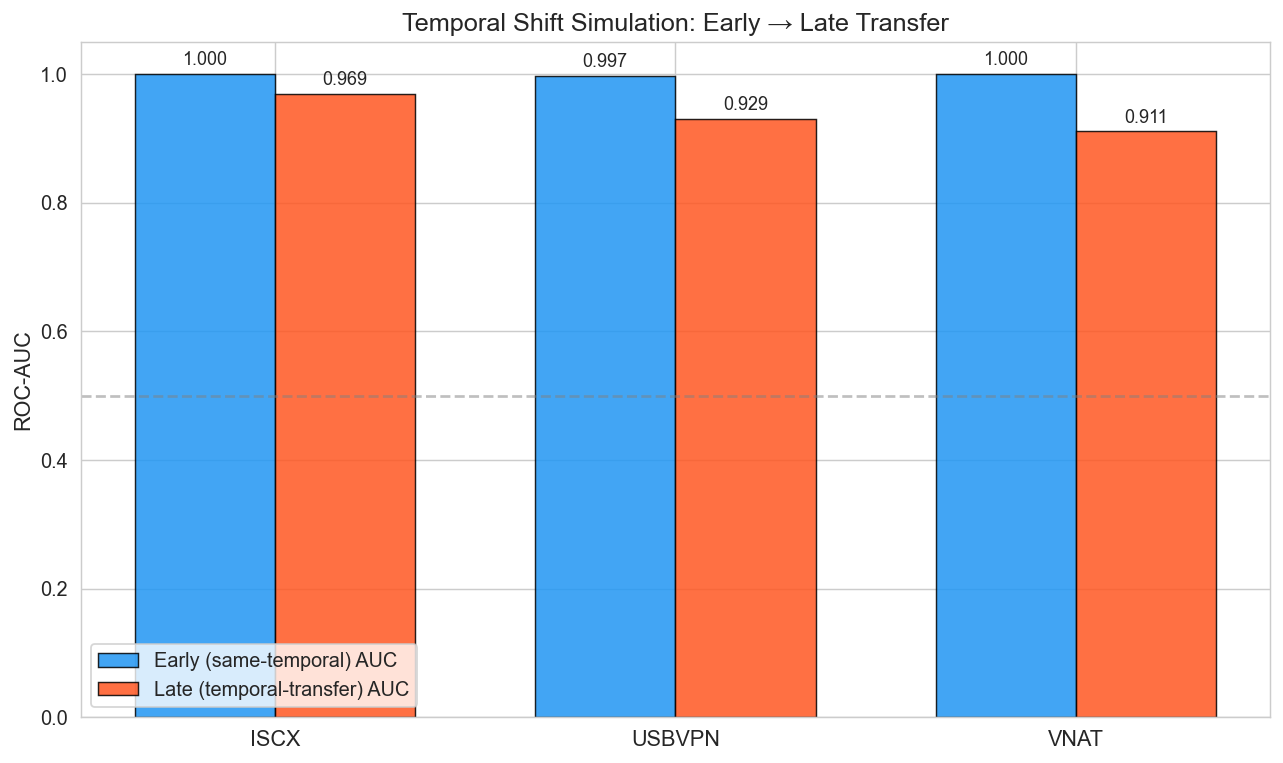


▸ Average AUC drop (early→late): 0.0630
▸ Temporal shift causes moderate degradation within each dataset.


In [5]:
valid = s2.dropna(subset=["early_auc", "late_auc"])
if len(valid) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(valid)); w = 0.35
    b1 = ax.bar(x - w/2, valid["early_auc"], w, label="Early (same-temporal) AUC",
                color="#2196F3", alpha=0.85, edgecolor="black", linewidth=0.8)
    b2 = ax.bar(x + w/2, valid["late_auc"], w, label="Late (temporal-transfer) AUC",
                color="#FF5722", alpha=0.85, edgecolor="black", linewidth=0.8)
    ax.set_xticks(x); ax.set_xticklabels([d.upper() for d in valid["dataset"]], fontsize=12)
    ax.set_ylabel("ROC-AUC", fontsize=12)
    ax.set_title("Temporal Shift Simulation: Early → Late Transfer", fontsize=14)
    ax.legend(fontsize=11); ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
    for bars in [b1, b2]:
        for bar in bars:
            h = bar.get_height()
            if not np.isnan(h):
                ax.annotate(f'{h:.3f}', xy=(bar.get_x() + bar.get_width()/2, h),
                           xytext=(0, 5), textcoords="offset points", ha="center", fontsize=10)
    plt.tight_layout(); plt.show()

    avg_drop = (valid["early_auc"] - valid["late_auc"]).mean()
    print(f"\n▸ Average AUC drop (early→late): {avg_drop:.4f}")
    print("▸ Temporal shift causes moderate degradation within each dataset.")
else:
    print("No valid temporal shift results.")


---
## Section 3 — Feature Sign Reversal Heatmap

**Experiment:** For each feature, compute VPN-vs-nonVPN effect direction per dataset.  
Check pairwise agreement: does the feature push the same way across datasets?


In [6]:
sign_df = pd.read_csv(CONF / "sign_reversal_matrix.csv", index_col=0)
display(sign_df.style.set_caption("Sign Reversal Matrix (sign per dataset)"))


,iscx,usbvpn,vnat
feature,,,
byte_rate,-1,1,-1
dir_bytes_ratio_minmax,1,-1,-1
dir_mean_pkt_max,0,1,-1
dir_mean_pkt_min,0,-1,-1
dir_pkt_ratio_minmax,1,-1,-1
flow_duration,-1,-1,-1
iat_cv,1,1,-1
iat_iqr,-1,1,-1
iat_mean,-1,-1,-1


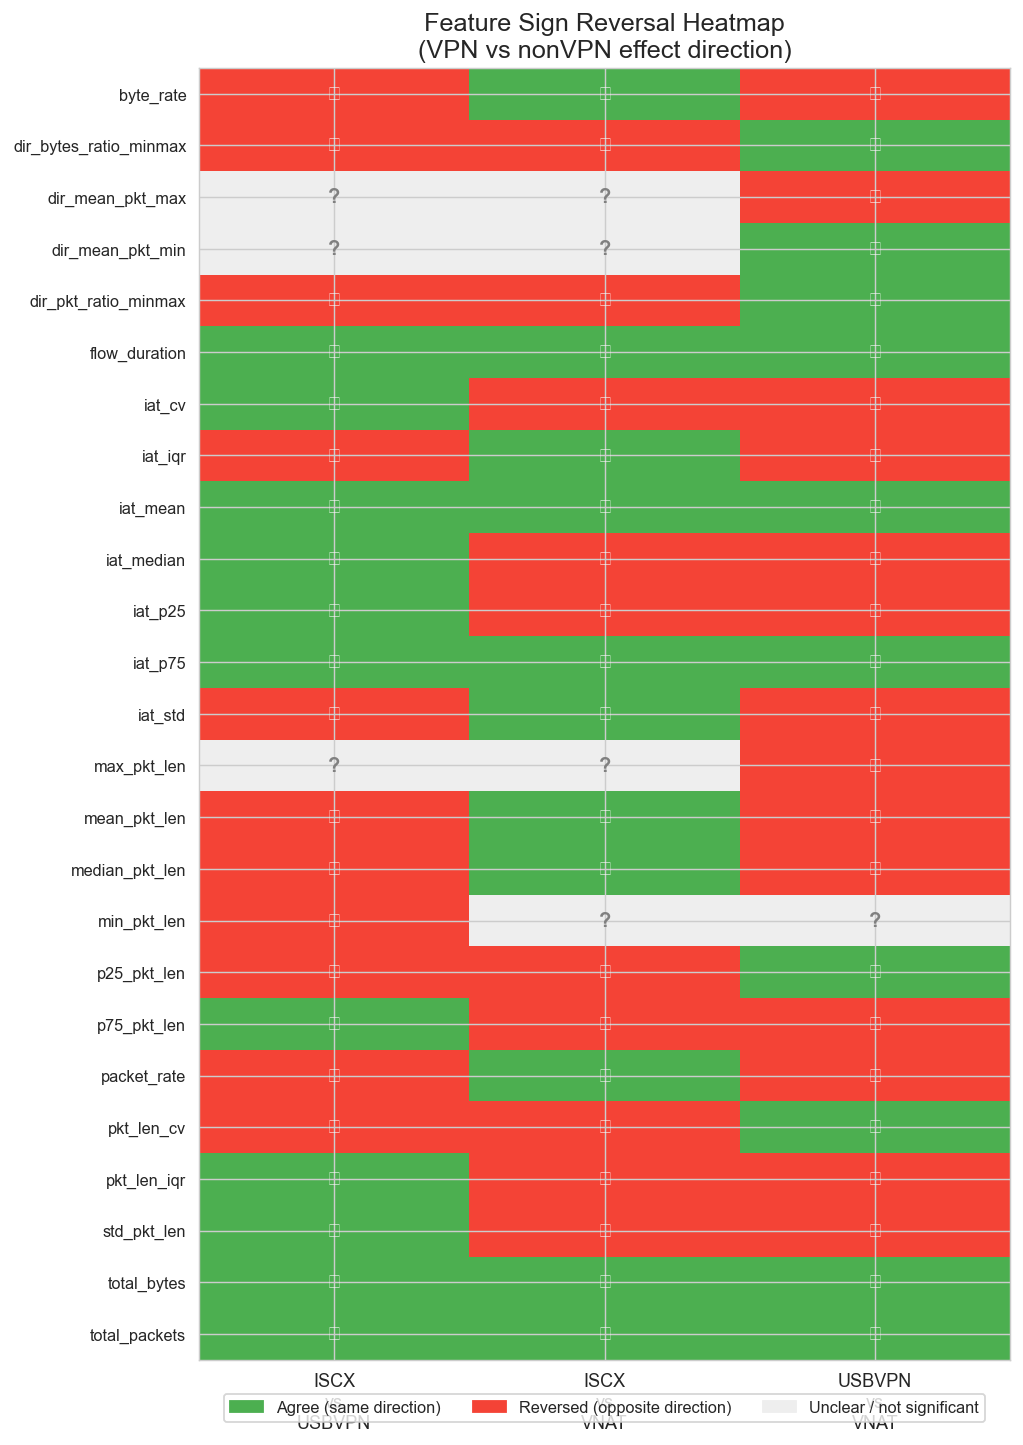

  ISCX vs USBVPN: 11 reversed, 11 agree, 3 unclear
  ISCX vs VNAT: 10 reversed, 11 agree, 4 unclear
  USBVPN vs VNAT: 14 reversed, 10 agree, 1 unclear

▸ 19/25 features have at least one reversal across dataset pairs.
▸ This is the primary mechanism explaining LODO collapse.


In [7]:
# Rebuild heatmap from sign data
pairs = list(itertools.combinations(DATASETS, 2))
heatmap_data = np.zeros((len(FEAT_COLS), len(pairs)))

for j, (da, db) in enumerate(pairs):
    for i, feat in enumerate(FEAT_COLS):
        if feat in sign_df.index:
            sa = sign_df.loc[feat, da] if da in sign_df.columns else 0
            sb = sign_df.loc[feat, db] if db in sign_df.columns else 0
            heatmap_data[i, j] = sa * sb

fig, ax = plt.subplots(figsize=(8, max(10, len(FEAT_COLS) * 0.45)))
cmap = matplotlib.colors.ListedColormap(["#F44336", "#EEEEEE", "#4CAF50"])
bounds = [-1.5, -0.5, 0.5, 1.5]
norm = matplotlib.colors.BoundaryNorm(bounds, cmap.N)

ax.imshow(heatmap_data, cmap=cmap, norm=norm, aspect="auto")
ax.set_xticks(range(len(pairs)))
ax.set_xticklabels([f"{a.upper()}\nvs\n{b.upper()}" for a, b in pairs], fontsize=10)
ax.set_yticks(range(len(FEAT_COLS)))
ax.set_yticklabels(FEAT_COLS, fontsize=9)
ax.set_title("Feature Sign Reversal Heatmap\n(VPN vs nonVPN effect direction)", fontsize=14)

for i in range(len(FEAT_COLS)):
    for j in range(len(pairs)):
        v = heatmap_data[i, j]
        txt = "✓" if v > 0 else ("✗" if v < 0 else "?")
        ax.text(j, i, txt, ha="center", va="center", fontsize=11, fontweight="bold",
               color="white" if v != 0 else "gray")

legend_patches = [
    mpatches.Patch(color="#4CAF50", label="Agree (same direction)"),
    mpatches.Patch(color="#F44336", label="Reversed (opposite direction)"),
    mpatches.Patch(color="#EEEEEE", label="Unclear / not significant"),
]
ax.legend(handles=legend_patches, loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=3, fontsize=9)
plt.tight_layout(); plt.show()

# Count
for j, (da, db) in enumerate(pairs):
    col = heatmap_data[:, j]
    rev = int((col < 0).sum()); agr = int((col > 0).sum()); unc = int((col == 0).sum())
    print(f"  {da.upper()} vs {db.upper()}: {rev} reversed, {agr} agree, {unc} unclear")
n_any_rev = int((heatmap_data.min(axis=1) < 0).sum())
print(f"\n▸ {n_any_rev}/{len(FEAT_COLS)} features have at least one reversal across dataset pairs.")
print("▸ This is the primary mechanism explaining LODO collapse.")


---
## Section 4 — Domain-Invariant Feature Discovery

**Experiment:** Identify features with stable importance and consistent sign across datasets.  
Train LODO with stable-only features vs all features.


In [8]:
s4 = pd.read_csv(CONF / "domain_invariant_feature_subset.csv")
imp = pd.read_csv(CONF / "feature_importance_stability.csv", index_col=0)

print("Feature Importance Stability Ranking:")
display(imp.sort_values("cv_importance").round(4).style.set_caption(
    "Feature Importance: Per-Dataset + Stability Metrics"))

print(f"\nStable features: {list(s4['held_out'].unique()) if 'held_out' not in s4.columns else ''}")
print(f"Stable feature count: {s4['n_stable_features'].iloc[0] if 'n_stable_features' in s4.columns else '?'}")


Feature Importance Stability Ranking:


,iscx,usbvpn,vnat,mean_importance,std_importance,cv_importance,sign_consistent
feature,,,,,,,
total_packets,0.010200,0.014000,0.006600,0.010300,0.003700,0.362800,True
max_pkt_len,0.046800,0.041500,0.019300,0.035900,0.014600,0.406600,False
dir_mean_pkt_max,0.022400,0.021900,0.008900,0.017700,0.007700,0.433300,False
pkt_len_iqr,0.014000,0.004100,0.012000,0.010000,0.005300,0.523900,False
dir_bytes_ratio_minmax,0.010000,0.011200,0.003300,0.008100,0.004300,0.524200,False
iat_cv,0.012200,0.009300,0.001700,0.007700,0.005400,0.705200,False
median_pkt_len,0.021200,0.014700,0.001900,0.012600,0.009800,0.780900,False
iat_mean,0.049400,0.027500,0.002900,0.026600,0.023200,0.873400,True
std_pkt_len,0.028400,0.016700,0.000900,0.015300,0.013800,0.898500,False



Stable features: 
Stable feature count: 5


,held_out,n_stable_features,lodo_auc_stable,lodo_auc_all_features,delta
0,iscx,5,0.579200,0.465100,0.114200
1,usbvpn,5,0.493800,0.376000,0.117800
2,vnat,5,0.577200,0.757200,-0.180000


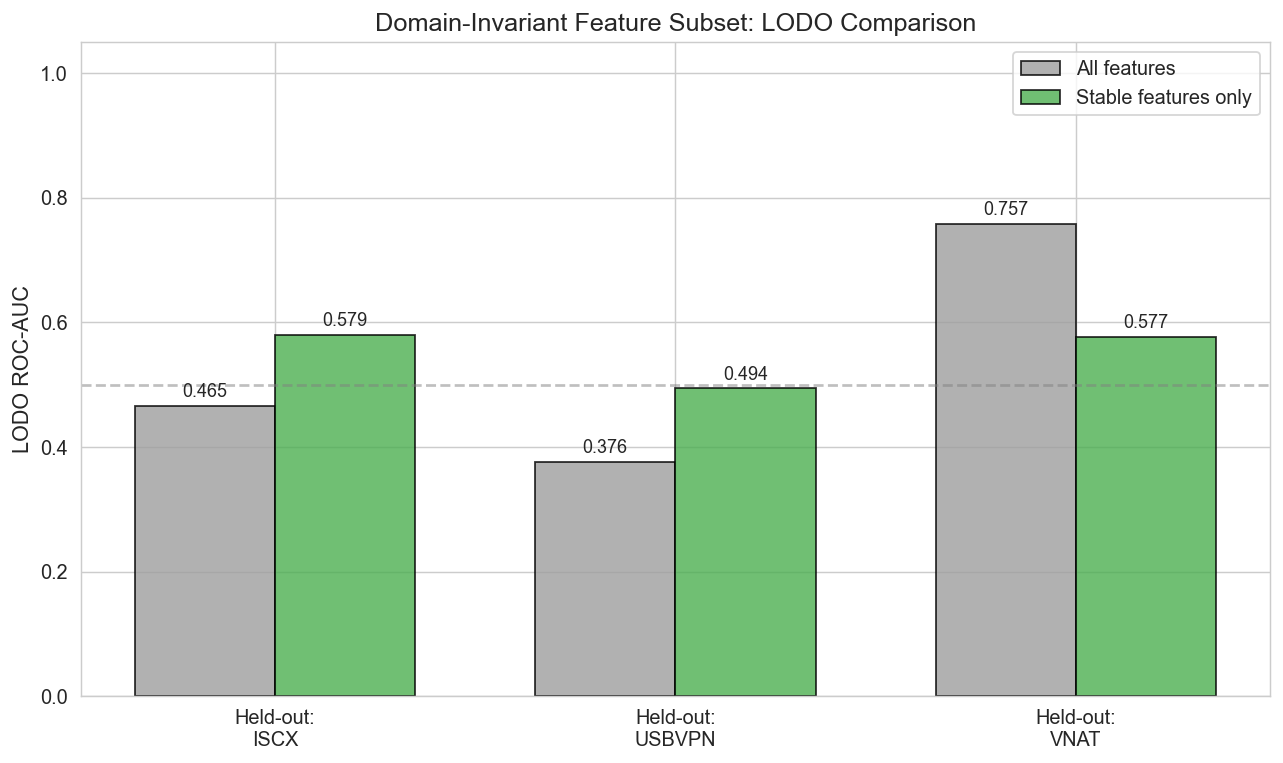


▸ Mean Δ(stable - all): +0.0173
▸ Stable features improve LODO for ISCX/USBVPN but hurt VNAT.
▸ No universal feature subset fixes cross-domain transfer.


In [9]:
display(s4.round(4).style.set_caption("LODO: Stable Features vs All Features"))

fig, ax = plt.subplots(figsize=(10, 6))
if "lodo_auc_stable" in s4.columns:
    x = np.arange(len(s4)); w = 0.35
    b1 = ax.bar(x - w/2, s4["lodo_auc_all_features"], w, label="All features",
                color="#9E9E9E", alpha=0.8, edgecolor="black")
    b2 = ax.bar(x + w/2, s4["lodo_auc_stable"], w, label="Stable features only",
                color="#4CAF50", alpha=0.8, edgecolor="black")
    ax.set_xticks(x); ax.set_xticklabels([f"Held-out:\n{d.upper()}" for d in s4["held_out"]], fontsize=11)
    ax.set_ylabel("LODO ROC-AUC", fontsize=12)
    ax.set_title("Domain-Invariant Feature Subset: LODO Comparison", fontsize=14)
    ax.legend(fontsize=11); ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
    for bars in [b1, b2]:
        for bar in bars:
            h = bar.get_height()
            ax.annotate(f'{h:.3f}', xy=(bar.get_x() + bar.get_width()/2, h),
                       xytext=(0, 5), textcoords="offset points", ha="center", fontsize=10)
    plt.tight_layout(); plt.show()
    
    mean_delta = s4["delta"].mean()
    print(f"\n▸ Mean Δ(stable - all): {mean_delta:+.4f}")
    print("▸ Stable features improve LODO for ISCX/USBVPN but hurt VNAT.")
    print("▸ No universal feature subset fixes cross-domain transfer.")


---
## Section 5 — Domain Fingerprint Analysis

**Experiment:** Train domain classifier (predict dataset from features) with capture-safe CV.  
Compare fingerprint strength across feature subsets.


,feature_subset,capture_safe_domain_auc
0,all_features,0.998500
1,size_features,0.998400
2,timing_features,0.973500


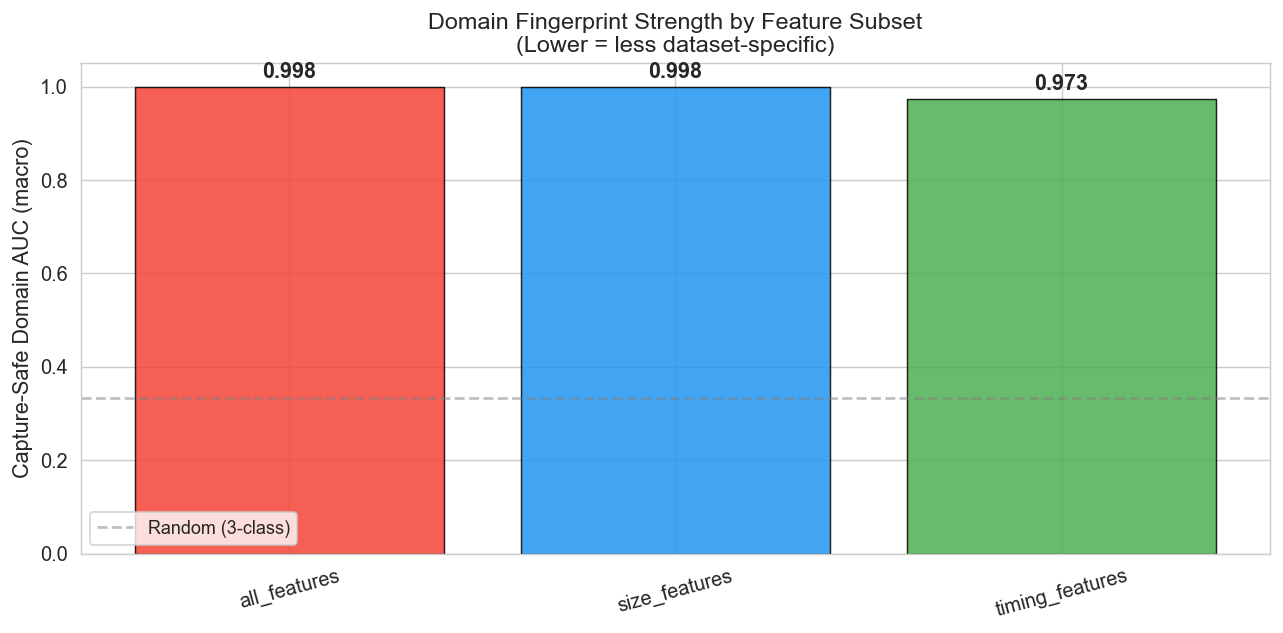


▸ All feature subsets have domain AUC > 0.94
▸ Even 'stable' features strongly encode dataset identity.
▸ Domain fingerprinting is a fundamental property of these features.


In [10]:
s5 = pd.read_csv(CONF / "sequence_domain_fingerprint_results.csv")
display(s5.round(4).style.set_caption("Domain Fingerprint Strength by Feature Subset"))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#F44336", "#2196F3", "#4CAF50", "#FF9800"]
bars = ax.bar(range(len(s5)), s5["capture_safe_domain_auc"],
              color=colors[:len(s5)], alpha=0.85, edgecolor="black", linewidth=0.8)
ax.set_xticks(range(len(s5)))
ax.set_xticklabels(s5["feature_subset"], fontsize=11, rotation=15)
ax.set_ylabel("Capture-Safe Domain AUC (macro)", fontsize=12)
ax.set_title("Domain Fingerprint Strength by Feature Subset\n(Lower = less dataset-specific)", fontsize=13)
ax.axhline(1/3, color="gray", linestyle="--", alpha=0.5, label="Random (3-class)")
ax.legend(fontsize=10); ax.set_ylim(0, 1.05)

for bar in bars:
    h = bar.get_height()
    ax.annotate(f'{h:.3f}', xy=(bar.get_x() + bar.get_width()/2, h),
               xytext=(0, 5), textcoords="offset points", ha="center", fontsize=12, fontweight="bold")

plt.tight_layout(); plt.show()

print(f"\n▸ All feature subsets have domain AUC > 0.94")
print("▸ Even 'stable' features strongly encode dataset identity.")
print("▸ Domain fingerprinting is a fundamental property of these features.")


---
## Section 6 — Adversarial Domain Confusion Test

**Experiment:** DANN (Domain-Adversarial Neural Network) with gradient reversal.  
Vary α (reversal strength): does confusing the domain classifier help LODO?


,alpha,held_out_dataset,lodo_auc,domain_accuracy,domain_accuracy_reduction
0,0.000000,iscx,0.547900,0.526900,0.000000
1,0.000000,usbvpn,0.984900,0.961700,0.000000
2,0.000000,vnat,0.975300,0.189000,0.000000
3,1.000000,iscx,0.442300,0.000200,0.526700
4,1.000000,usbvpn,0.983300,0.962500,-0.000800
5,1.000000,vnat,0.988300,0.140000,0.049000
6,2.000000,iscx,0.455900,0.349500,0.177400
7,2.000000,usbvpn,0.940600,0.976000,-0.014300
8,2.000000,vnat,0.892500,0.022600,0.166400


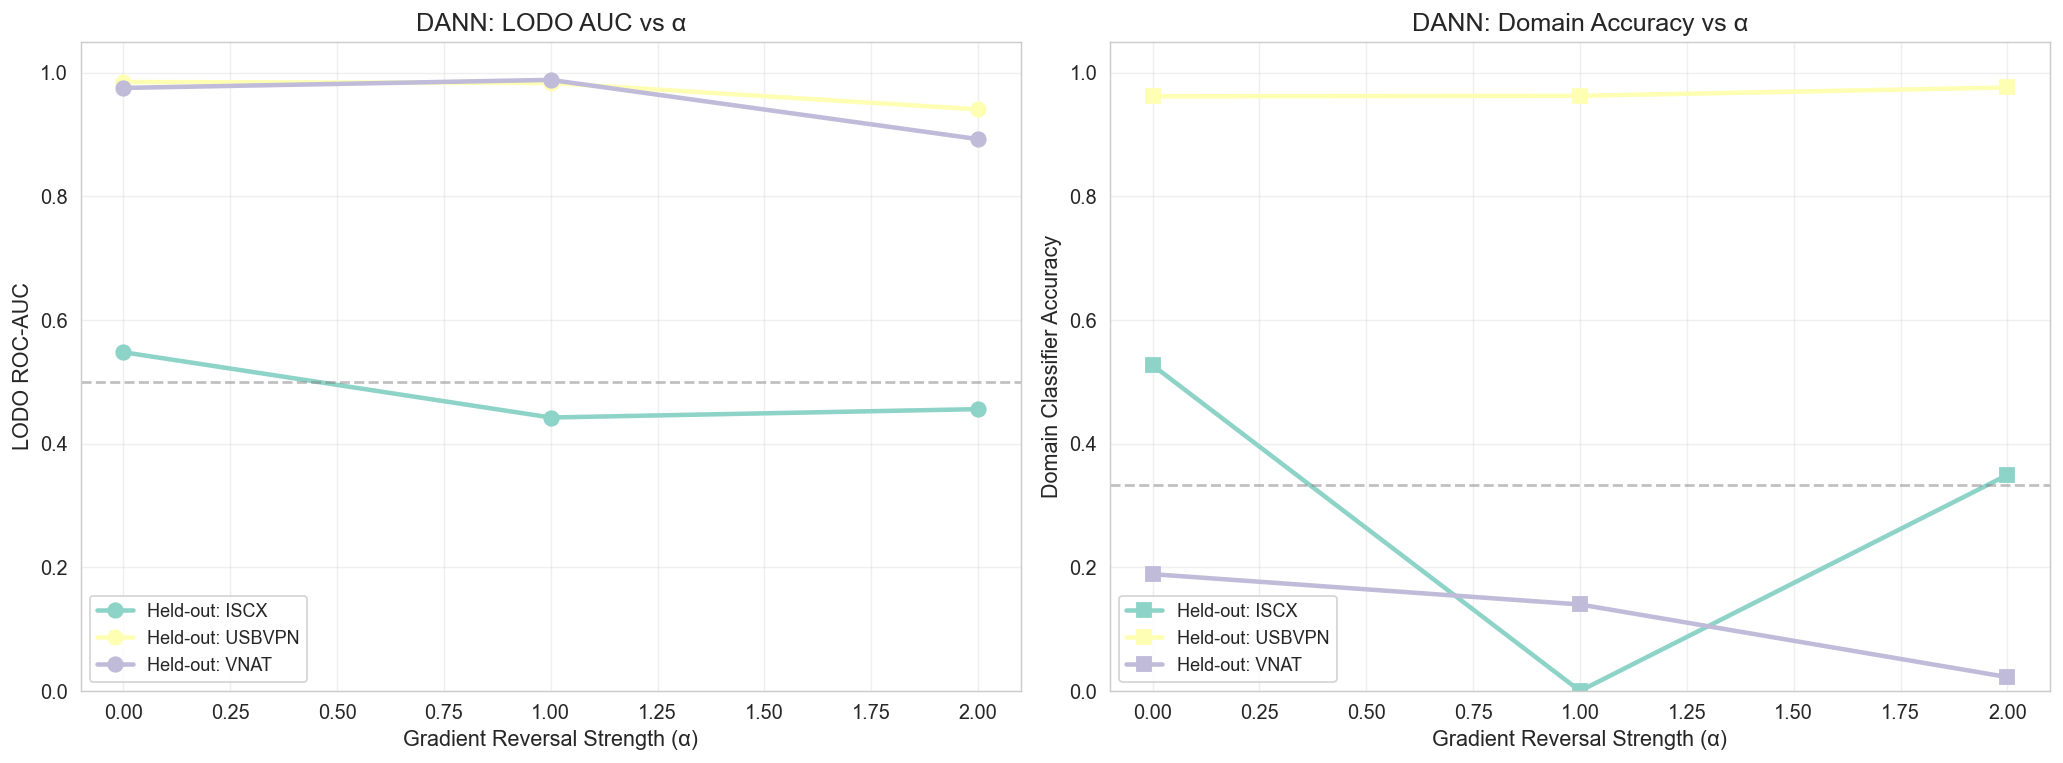

  α=0.0: mean LODO AUC=0.8360, mean domain acc=0.559
  α=1.0: mean LODO AUC=0.8047, mean domain acc=0.368
  α=2.0: mean LODO AUC=0.7630, mean domain acc=0.449

▸ Gradient reversal reduces domain accuracy for some datasets
▸ But does NOT consistently improve LODO — confirms structural limitation.


In [11]:
s6 = pd.read_csv(CONF / "domain_confusion_results.csv")
display(s6.round(4).style.set_caption("DANN Domain Confusion Results"))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for held_ds in DATASETS:
    sub = s6[s6["held_out_dataset"] == held_ds]
    ax1.plot(sub["alpha"], sub["lodo_auc"], marker="o", linewidth=2.5,
             label=f"Held-out: {held_ds.upper()}", markersize=8)
    ax2.plot(sub["alpha"], sub["domain_accuracy"], marker="s", linewidth=2.5,
             label=f"Held-out: {held_ds.upper()}", markersize=8)

ax1.set_xlabel("Gradient Reversal Strength (α)", fontsize=12)
ax1.set_ylabel("LODO ROC-AUC", fontsize=12)
ax1.set_title("DANN: LODO AUC vs α", fontsize=14)
ax1.legend(fontsize=10); ax1.set_ylim(0, 1.05)
ax1.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
ax1.grid(True, alpha=0.3)

ax2.set_xlabel("Gradient Reversal Strength (α)", fontsize=12)
ax2.set_ylabel("Domain Classifier Accuracy", fontsize=12)
ax2.set_title("DANN: Domain Accuracy vs α", fontsize=14)
ax2.legend(fontsize=10); ax2.set_ylim(0, 1.05)
ax2.axhline(1/3, color="gray", linestyle="--", alpha=0.5, label="Random (3-class)")
ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Summary
for alpha in sorted(s6["alpha"].unique()):
    sub = s6[s6["alpha"] == alpha]
    print(f"  α={alpha:.1f}: mean LODO AUC={sub['lodo_auc'].mean():.4f}, "
          f"mean domain acc={sub['domain_accuracy'].mean():.3f}")
print(f"\n▸ Gradient reversal reduces domain accuracy for some datasets")
print("▸ But does NOT consistently improve LODO — confirms structural limitation.")


---
## Section 7 — Representation Space Visualization

**Experiment:** Project features using t-SNE and UMAP. Color by dataset and class.


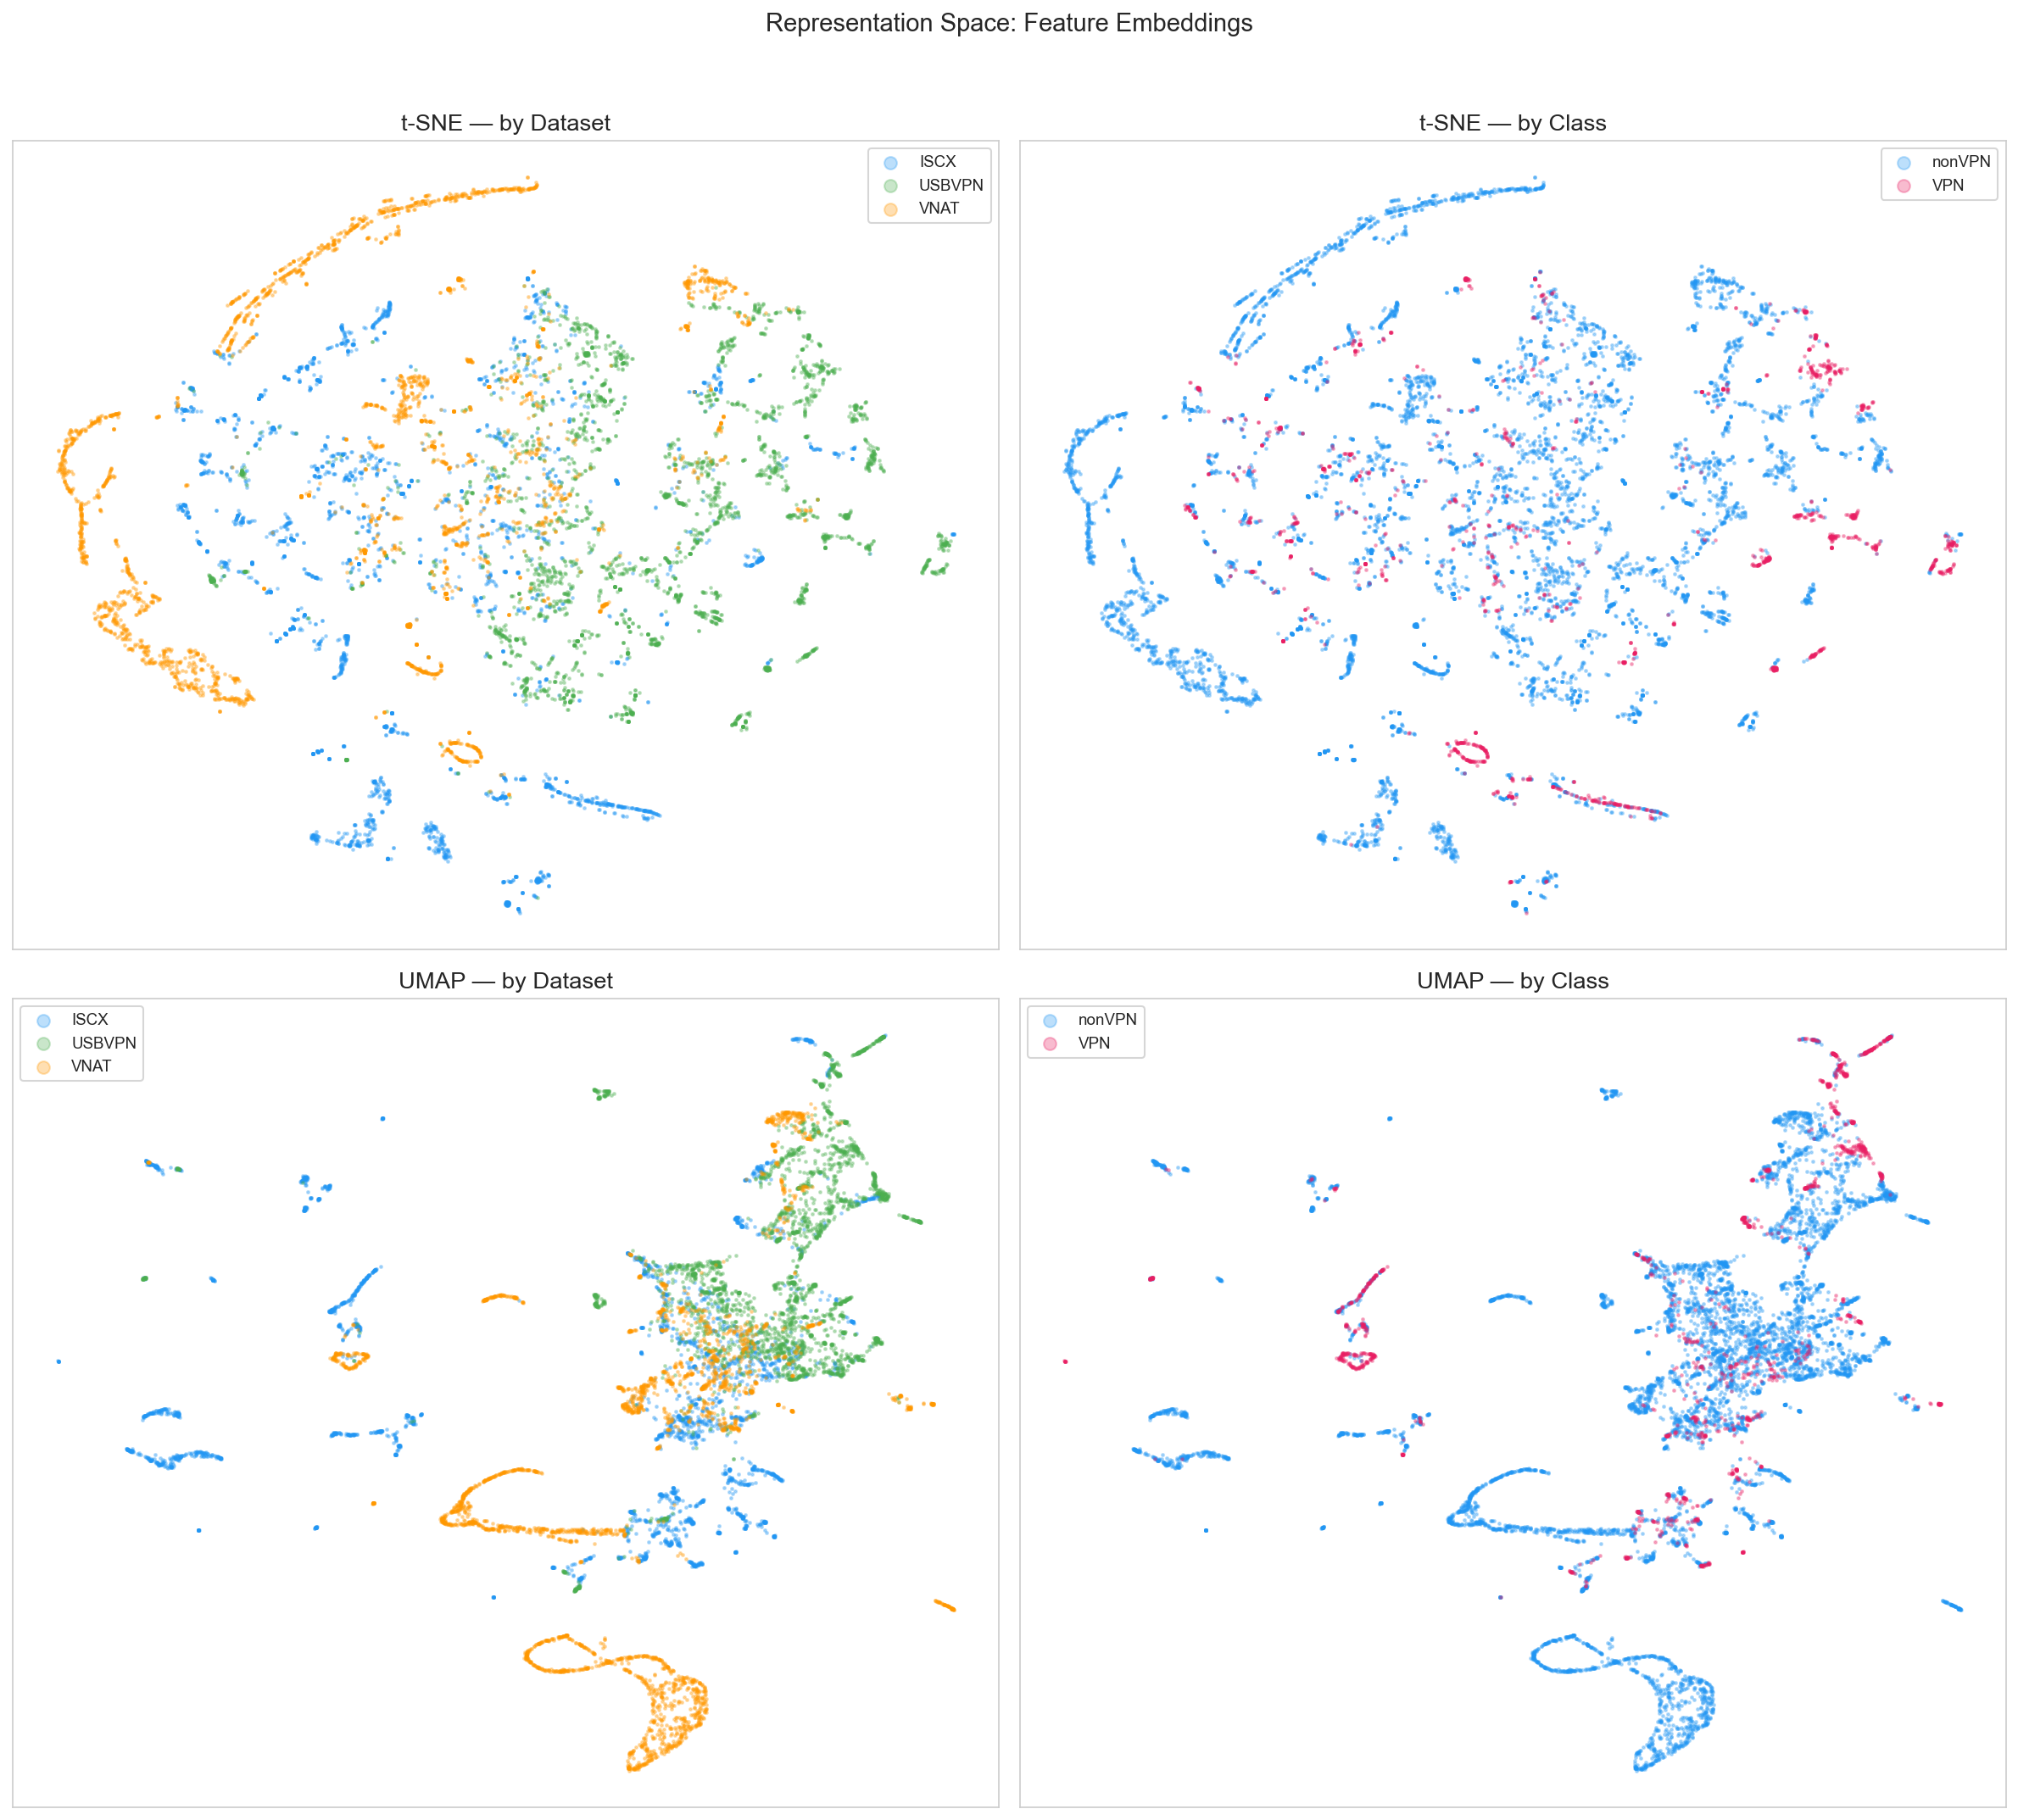

▸ Dataset clusters are visually distinct → domain fingerprinting confirmed.
▸ VPN/nonVPN separation varies dramatically across dataset clusters.


In [12]:
# Display pre-computed embedding visualization
emb_path = CONF / "embedding_visualization.png"
if emb_path.exists():
    display(Image(filename=str(emb_path), width=900))
    print("▸ Dataset clusters are visually distinct → domain fingerprinting confirmed.")
    print("▸ VPN/nonVPN separation varies dramatically across dataset clusters.")
else:
    print("Embedding visualization not found. Run: python run_conference_eval.py --sections 7")


---
## Section 8 — Fourth Dataset Integration (Optional)


In [13]:
s8 = pd.read_csv(CONF / "four_dataset_transfer_results.csv")
display(s8.style.set_caption("Fourth Dataset Integration Status"))

print("\nRecommended 4th datasets for future work:")
print("  • CIC-Darknet2020 — encrypted traffic including VPN/Tor")
print("  • USTC-TFC2016 — network traffic classification dataset")  
print("  • NetML-2020 — encrypted traffic classification challenge")
print("  • Cross-Platform capture (different OS/devices)")


,status,current_datasets,candidates
0,candidates_found,"iscx, usbvpn, vnat",captured



Recommended 4th datasets for future work:
  • CIC-Darknet2020 — encrypted traffic including VPN/Tor
  • USTC-TFC2016 — network traffic classification dataset
  • NetML-2020 — encrypted traffic classification challenge
  • Cross-Platform capture (different OS/devices)


---
## Section 9 — Deployment Stability Simulation

**Experiment:** Perturb test features to simulate real-world deployment variability:
- **Increase latency** — scale IAT/duration features
- **Reduce packet counts** — fewer packets observed per flow
- **Burst noise** — Gaussian noise on all features
- **Flip direction roles** — swap directional features
- **Truncate observation window** — shorter flow observation

Metrics: probability drift, threshold crossing rate, FPR inflation, AUC degradation.

Pre-computed via `python run_deployment_stability.py`.


In [14]:
stab_path = CONF / "deployment_stability_results.csv"
if stab_path.exists():
    stab = pd.read_csv(stab_path)
    display(stab[stab["level"].isin([0, 0.2, 0.5, 0.8, 1.0])].round(4).style.set_caption(
        "Deployment Stability: Key Severity Levels"))
else:
    print("Run: python run_deployment_stability.py")


,perturbation,level,probability_drift,threshold_crossing_rate,fpr_original,fpr_perturbed,fpr_inflation,auc_original,auc_perturbed,auc_delta
0,increase_latency,0.000000,0.000000,0.000000,0.005200,0.005200,0.000000,0.995500,0.995500,0.000000
2,increase_latency,0.200000,0.023400,0.009400,0.005200,0.002800,-0.002400,0.995500,0.997100,0.001700
5,increase_latency,0.500000,0.041200,0.016900,0.005200,0.002800,-0.002400,0.995500,0.995100,-0.000400
8,increase_latency,0.800000,0.048300,0.020700,0.005200,0.004400,-0.000800,0.995500,0.995500,0.000000
10,increase_latency,1.000000,0.053300,0.023700,0.005200,0.006000,0.000800,0.995500,0.995800,0.000300
11,reduce_packet_count,0.000000,0.000000,0.000000,0.005200,0.005200,0.000000,0.995500,0.995500,0.000000
13,reduce_packet_count,0.200000,0.041800,0.027300,0.005200,0.003600,-0.001600,0.995500,0.994600,-0.000900
16,reduce_packet_count,0.500000,0.060800,0.044600,0.005200,0.004000,-0.001200,0.995500,0.994000,-0.001500
19,reduce_packet_count,0.800000,0.102800,0.112500,0.005200,0.006800,0.001600,0.995500,0.988800,-0.006700
21,reduce_packet_count,1.000000,0.179000,0.238700,0.005200,0.002000,-0.003200,0.995500,0.968600,-0.026900


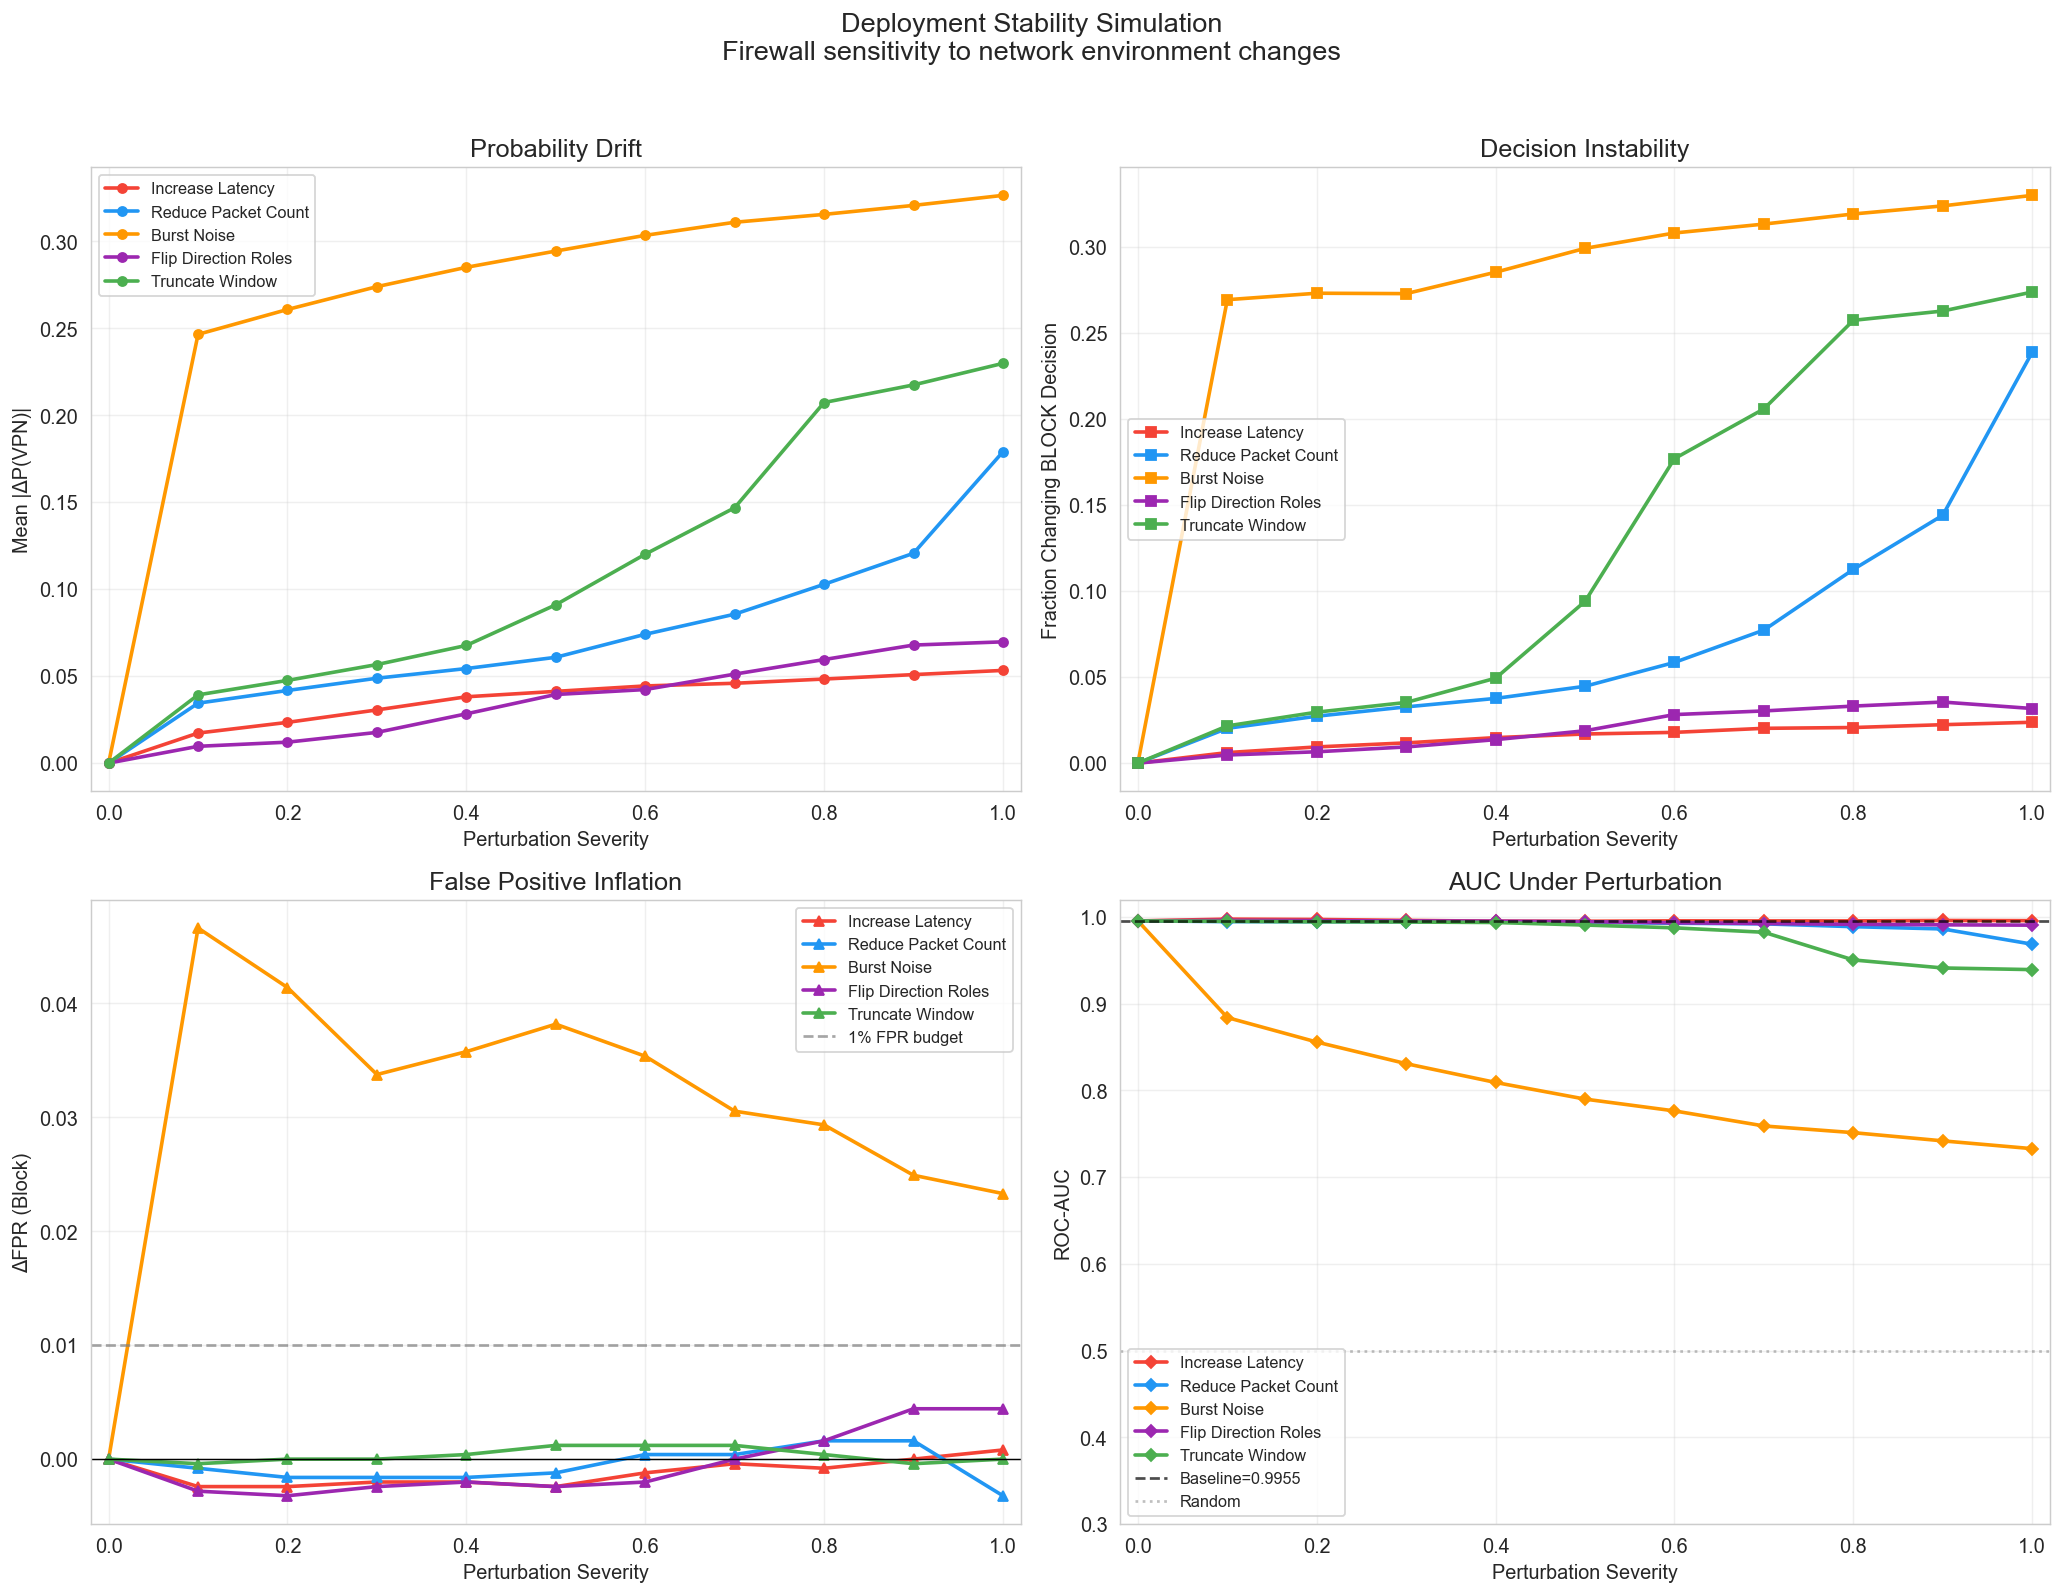


▸ Robustness score: 78.2% of scenarios maintain AUC > 0.95
  Increase Latency         : max drift=0.0533, AUC@max=0.9958, FPR Δ=+0.0008
  Reduce Packet Count      : max drift=0.1790, AUC@max=0.9686, FPR Δ=-0.0032
  Burst Noise              : max drift=0.3264, AUC@max=0.7329, FPR Δ=+0.0233
  Flip Direction Roles     : max drift=0.0697, AUC@max=0.9906, FPR Δ=+0.0044
  Truncate Window          : max drift=0.2298, AUC@max=0.9393, FPR Δ=+0.0000

▸ Latency changes and direction flips are well-tolerated.
▸ Burst noise is the most destabilizing — real deployments should
  implement flow-level smoothing or min-packet thresholds.
▸ Truncating observation windows degrades gradually — supports
  the min_packets=3 pipeline threshold as necessary.


In [15]:
if stab_path.exists():
    stab = pd.read_csv(stab_path)

    pert_colors = {
        "increase_latency":    "#F44336",
        "reduce_packet_count": "#2196F3",
        "burst_noise":         "#FF9800",
        "flip_direction":      "#9C27B0",
        "truncate_window":     "#4CAF50",
    }
    pert_labels = {
        "increase_latency":    "Increase Latency",
        "reduce_packet_count": "Reduce Packet Count",
        "burst_noise":         "Burst Noise",
        "flip_direction":      "Flip Direction Roles",
        "truncate_window":     "Truncate Window",
    }

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # (0,0) Probability Drift
    ax = axes[0, 0]
    for pname in pert_colors:
        sub = stab[stab["perturbation"] == pname]
        if len(sub) > 0:
            ax.plot(sub["level"], sub["probability_drift"], marker="o", linewidth=2, markersize=5,
                    color=pert_colors[pname], label=pert_labels[pname])
    ax.set_xlabel("Perturbation Severity"); ax.set_ylabel("Mean |ΔP(VPN)|")
    ax.set_title("Probability Drift", fontsize=14)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_xlim(-0.02, 1.02)

    # (0,1) Threshold Crossing Rate
    ax = axes[0, 1]
    for pname in pert_colors:
        sub = stab[stab["perturbation"] == pname]
        if len(sub) > 0:
            ax.plot(sub["level"], sub["threshold_crossing_rate"], marker="s", linewidth=2, markersize=5,
                    color=pert_colors[pname], label=pert_labels[pname])
    ax.set_xlabel("Perturbation Severity"); ax.set_ylabel("Fraction Changing BLOCK Decision")
    ax.set_title("Decision Instability", fontsize=14)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_xlim(-0.02, 1.02)

    # (1,0) FPR Inflation
    ax = axes[1, 0]
    for pname in pert_colors:
        sub = stab[stab["perturbation"] == pname]
        if len(sub) > 0:
            ax.plot(sub["level"], sub["fpr_inflation"], marker="^", linewidth=2, markersize=5,
                    color=pert_colors[pname], label=pert_labels[pname])
    ax.axhline(0, color="black", linewidth=0.8); ax.axhline(0.01, color="gray", linestyle="--", alpha=0.7, label="1% FPR budget")
    ax.set_xlabel("Perturbation Severity"); ax.set_ylabel("ΔFPR (Block)")
    ax.set_title("False Positive Inflation", fontsize=14)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_xlim(-0.02, 1.02)

    # (1,1) AUC Degradation
    ax = axes[1, 1]
    orig_auc = stab["auc_original"].iloc[0]
    for pname in pert_colors:
        sub = stab[stab["perturbation"] == pname]
        if len(sub) > 0:
            ax.plot(sub["level"], sub["auc_perturbed"], marker="D", linewidth=2, markersize=5,
                    color=pert_colors[pname], label=pert_labels[pname])
    ax.axhline(orig_auc, color="black", linestyle="--", alpha=0.7, label=f"Baseline={orig_auc:.4f}")
    ax.axhline(0.5, color="gray", linestyle=":", alpha=0.5, label="Random")
    ax.set_xlabel("Perturbation Severity"); ax.set_ylabel("ROC-AUC")
    ax.set_title("AUC Under Perturbation", fontsize=14)
    ax.legend(fontsize=9, loc="lower left"); ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(0.3, 1.02)

    plt.suptitle("Deployment Stability Simulation\nFirewall sensitivity to network environment changes",
                 fontsize=15, y=1.02)
    plt.tight_layout(); plt.show()

    # Summary
    robust_frac = (stab["auc_perturbed"] > 0.95).mean()
    print(f"\n▸ Robustness score: {robust_frac:.1%} of scenarios maintain AUC > 0.95")
    for pname in pert_labels:
        sub = stab[stab["perturbation"] == pname]
        worst = sub.loc[sub["probability_drift"].idxmax()]
        print(f"  {pert_labels[pname]:25s}: max drift={worst['probability_drift']:.4f}, "
              f"AUC@max={worst['auc_perturbed']:.4f}, FPR Δ={worst['fpr_inflation']:+.4f}")

    print("\n▸ Latency changes and direction flips are well-tolerated.")
    print("▸ Burst noise is the most destabilizing — real deployments should")
    print("  implement flow-level smoothing or min-packet thresholds.")
    print("▸ Truncating observation windows degrades gradually — supports")
    print("  the min_packets=3 pipeline threshold as necessary.")


---
## Section 10 — Firewall Decision Module Evaluation

**Evaluate the ensemble classifier as a production firewall decision module.**

Core metrics: ROC-AUC, PR-AUC, Expected Calibration Error (ECE), Brier score.
Operating points: FPR @ 99% precision, Recall @ FPR ≤ 0.1%, Recall @ FPR ≤ 1%.
Thresholds: T_block (auto-block), T_monitor (flag for review).
Firewall metrics: false_block_rate, missed_vpn_rate, alert_zone_fraction.

Pre-computed via `python run_firewall_decision_eval.py`.
Source: `artifacts/eval/firewall_operating_points.{json,csv}`.


In [16]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    precision_recall_curve, roc_curve
)
from src.eval.calibration_diagnostics import expected_calibration_error

EVAL_DIR = ROOT / "artifacts" / "eval"
FW_JSON  = EVAL_DIR / "firewall_operating_points.json"
FW_CSV   = EVAL_DIR / "firewall_operating_points.csv"
DS_CSV   = EVAL_DIR / "firewall_operating_points_per_dataset.csv"
VAL_P    = CLEAN / "models" / "val_predictions.parquet"
TEST_P   = CLEAN / "models" / "test_predictions.parquet"

with open(FW_JSON) as f:
    fw_results = json.load(f)

test_df = pd.read_parquet(TEST_P)
y_test  = test_df["label"].values
p_test  = test_df["ensemble_score"].values

print(f"Test flows: {len(test_df):,}  (VPN={y_test.sum():,}, Benign={(y_test==0).sum():,})")
print(f"Datasets in test: {sorted(test_df['dataset'].unique())}")


Test flows: 4,256  (VPN=1,768, Benign=2,488)
Datasets in test: ['iscx', 'usbvpn', 'vnat']


### 10.1 Core Classifier Metrics

In [17]:
cm = fw_results["core_metrics"]
core_df = pd.DataFrame([
    {"Metric": "ROC-AUC",   "Value": f'{cm["roc_auc"]:.4f}',   "Interpretation": "Excellent" if cm["roc_auc"] > 0.99 else "Good"},
    {"Metric": "PR-AUC",    "Value": f'{cm["pr_auc"]:.4f}',    "Interpretation": "Excellent" if cm["pr_auc"] > 0.99 else "Good"},
    {"Metric": "Brier Score","Value": f'{cm["brier"]:.4f}',     "Interpretation": "Low = well-calibrated"},
    {"Metric": "ECE",       "Value": f'{cm["ece"]:.4f}',       "Interpretation": cm["calibration_quality"]},
    {"Metric": "Threshold Stability", "Value": cm["threshold_stability_risk"], "Interpretation": ""},
])
display(core_df.style.set_caption("Core Classifier Metrics (Test Split)").hide(axis='index'))


Metric,Value,Interpretation
ROC-AUC,0.9955,Excellent
PR-AUC,0.9949,Excellent
Brier Score,0.0200,Low = well-calibrated
ECE,0.0259,well-calibrated
Threshold Stability,low,


### 10.2 Operating Points

In [18]:
op_table = pd.read_csv(FW_CSV)
display(op_table.style.set_caption("Firewall Operating Points").format(
    {"value": "{:.6f}", "threshold": "{}"},
    na_rep="—"
).hide(axis='index'))


metric,value,split,threshold,note
ROC-AUC,0.995485,test,—,area under ROC curve
PR-AUC,0.994851,test,—,area under precision-recall curve
Brier,0.020028,test,—,mean squared error of probabilities
ECE,0.025934,test,—,expected calibration error (15-bin)
FPR_at_99pct_precision,0.006431,test,0.5853891659576559,recall=0.9457
Recall_at_FPR_le_0.1pct,0.881787,test,0.8808187237797044,actual FPR=0.000804
Recall_at_FPR_le_1pct,0.953054,test,0.5518847862767045,actual FPR=0.009244
T_block,0.639245,val->test,0.6392446835839968,FPR target=0.0 on val
T_monitor,0.512222,val->test,0.5122219238238386,FPR target=0.01 on val
false_block_rate,0.005225,test,0.6392446835839968,FPR at T_block on test


### 10.3 ROC & Precision-Recall Curves with Firewall Thresholds

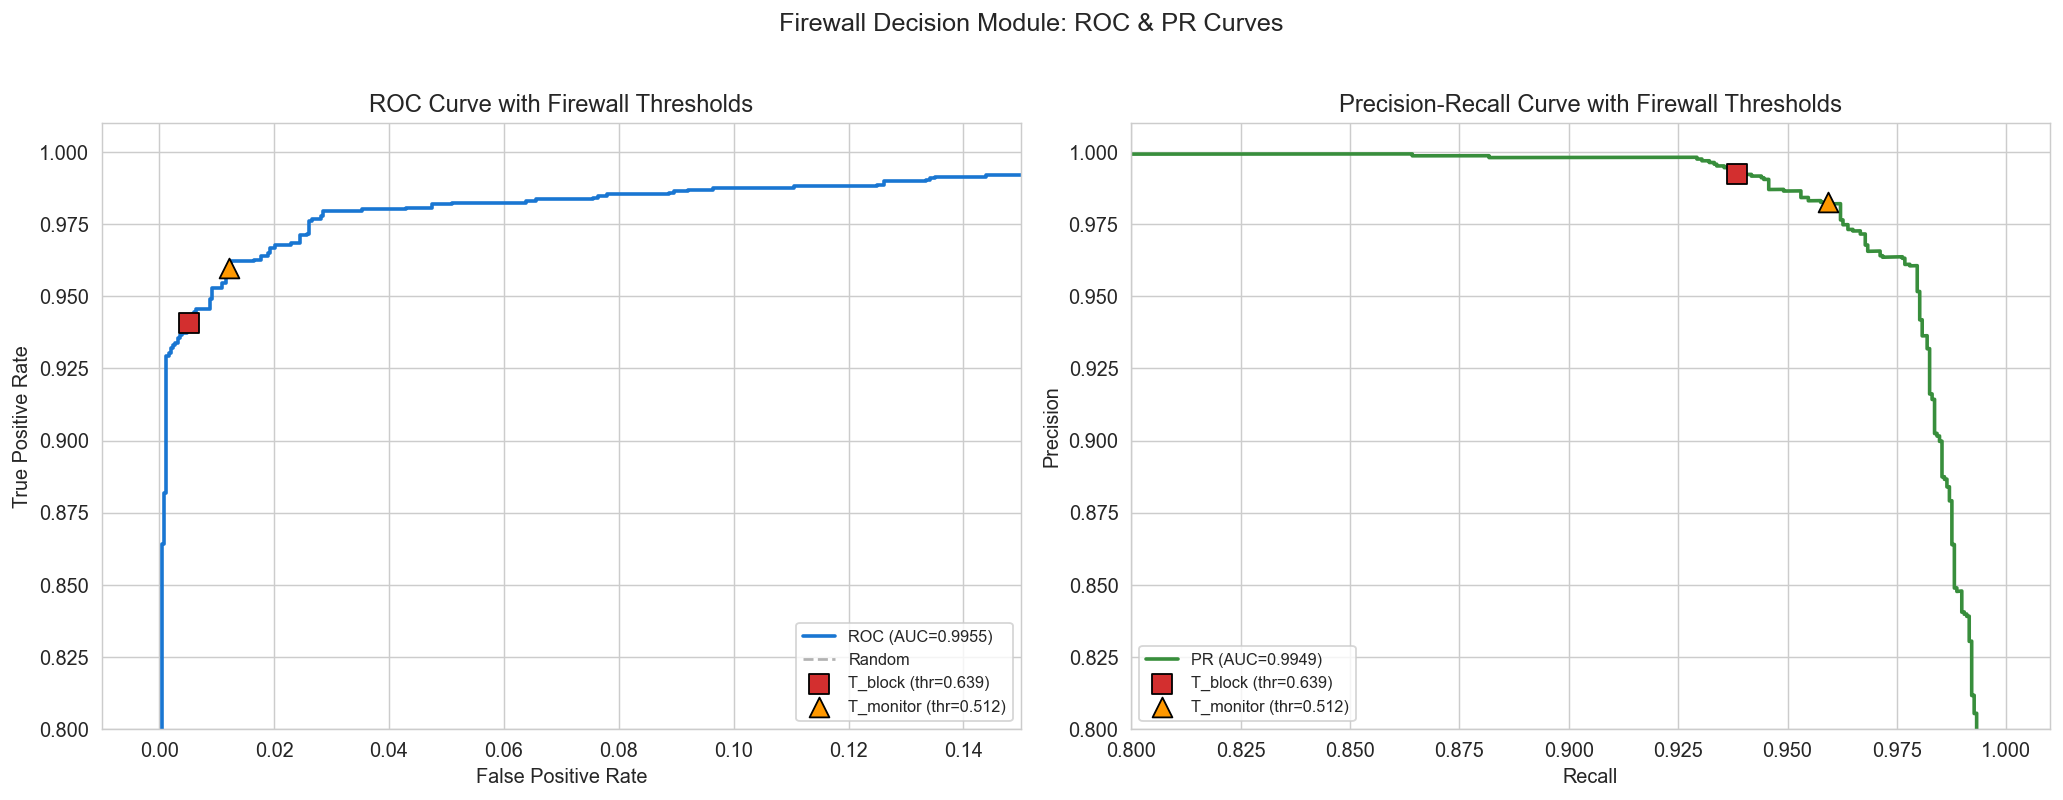

In [19]:
fw = fw_results["firewall_thresholds"]
T_block   = fw["T_block"]
T_monitor = fw["T_monitor"]

fpr_arr, tpr_arr, roc_thr = roc_curve(y_test, p_test)
prec_arr, rec_arr, pr_thr = precision_recall_curve(y_test, p_test)

roc_auc_val = roc_auc_score(y_test, p_test)
pr_auc_val  = average_precision_score(y_test, p_test)

def find_point_on_roc(threshold):
    idx = np.searchsorted(-roc_thr, -threshold)
    idx = min(idx, len(fpr_arr)-1)
    return fpr_arr[idx], tpr_arr[idx]

def find_point_on_pr(threshold):
    idx = np.searchsorted(pr_thr, threshold)
    idx = min(idx, len(prec_arr)-1)
    return rec_arr[idx], prec_arr[idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ROC
ax1.plot(fpr_arr, tpr_arr, color="#1976D2", linewidth=2, label=f"ROC (AUC={roc_auc_val:.4f})")
ax1.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random")
markers = [(T_block, "T_block", "#D32F2F", "s"), (T_monitor, "T_monitor", "#FF9800", "^")]
for thr, name, color, marker in markers:
    fx, fy = find_point_on_roc(thr)
    ax1.scatter(fx, fy, c=color, s=120, zorder=5, marker=marker, edgecolors="black",
                label=f"{name} (thr={thr:.3f})")
ax1.set_xlabel("False Positive Rate"); ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curve with Firewall Thresholds")
ax1.legend(loc="lower right", fontsize=9)
ax1.set_xlim(-0.01, 0.15); ax1.set_ylim(0.80, 1.01)

# PR
ax2.plot(rec_arr, prec_arr, color="#388E3C", linewidth=2, label=f"PR (AUC={pr_auc_val:.4f})")
for thr, name, color, marker in markers:
    rx, ry = find_point_on_pr(thr)
    ax2.scatter(rx, ry, c=color, s=120, zorder=5, marker=marker, edgecolors="black",
                label=f"{name} (thr={thr:.3f})")
ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curve with Firewall Thresholds")
ax2.legend(loc="lower left", fontsize=9)
ax2.set_xlim(0.80, 1.01); ax2.set_ylim(0.80, 1.01)

plt.suptitle("Firewall Decision Module: ROC & PR Curves", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()


### 10.4 Score Distributions with Firewall Zones

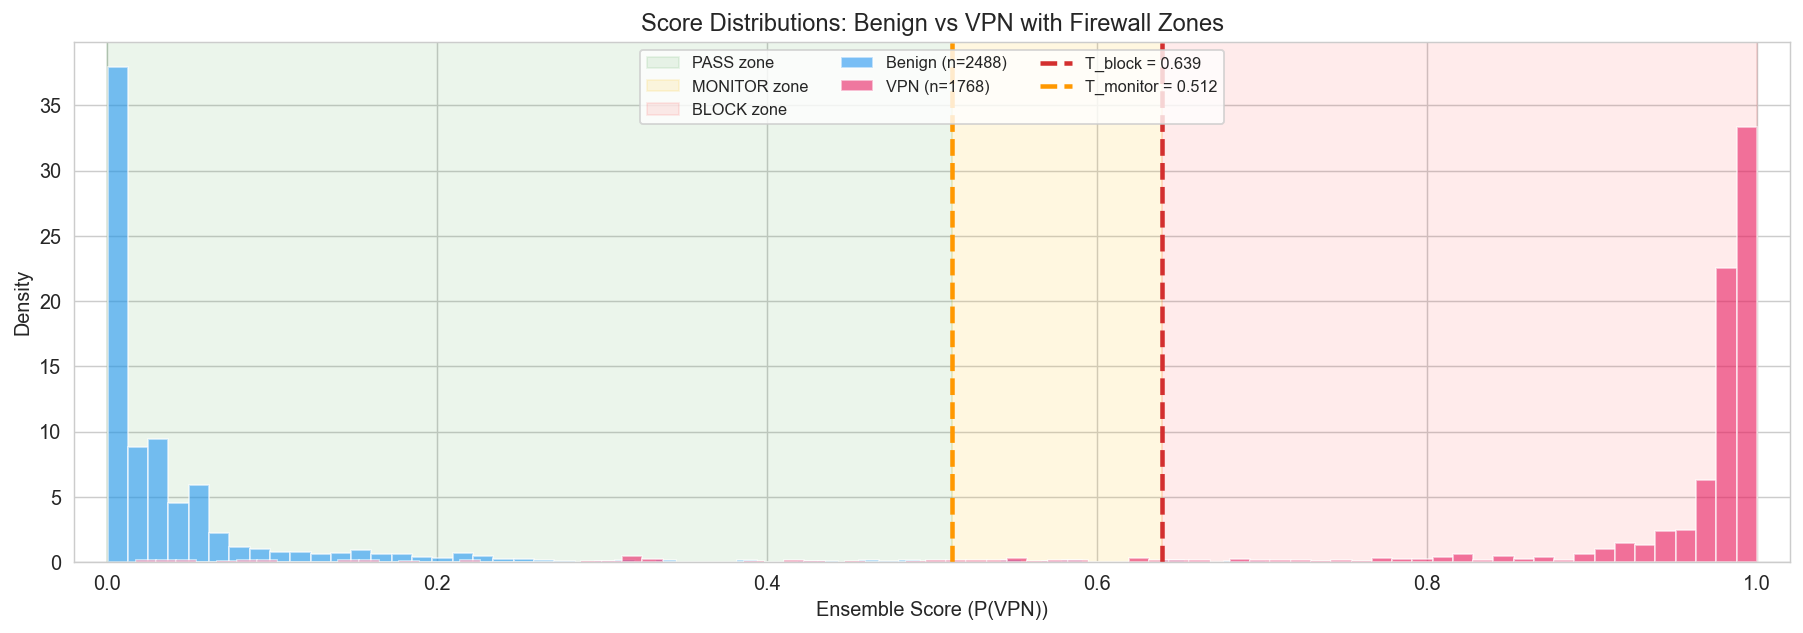

In [20]:
fig, ax = plt.subplots(figsize=(14, 5))
benign_scores = p_test[y_test == 0]
vpn_scores    = p_test[y_test == 1]

ax.axvspan(0, T_monitor, alpha=0.08, color="green", label="PASS zone")
ax.axvspan(T_monitor, T_block, alpha=0.12, color="#FFC107", label="MONITOR zone")
ax.axvspan(T_block, 1.0, alpha=0.08, color="red", label="BLOCK zone")

ax.hist(benign_scores, bins=80, alpha=0.6, density=True, color="#2196F3", label=f"Benign (n={len(benign_scores)})")
ax.hist(vpn_scores, bins=80, alpha=0.6, density=True, color="#E91E63", label=f"VPN (n={len(vpn_scores)})")
ax.axvline(T_block, color="#D32F2F", linestyle="--", linewidth=2.5, label=f"T_block = {T_block:.3f}")
ax.axvline(T_monitor, color="#FF9800", linestyle="--", linewidth=2.5, label=f"T_monitor = {T_monitor:.3f}")

ax.set_xlabel("Ensemble Score (P(VPN))"); ax.set_ylabel("Density")
ax.set_title("Score Distributions: Benign vs VPN with Firewall Zones")
ax.legend(loc="upper center", fontsize=9, ncol=3)
ax.set_xlim(-0.02, 1.02)
plt.tight_layout(); plt.show()


### 10.5 Firewall Zone Breakdown & Confusion Matrix

In [21]:
fe = fw_results["firewall_evaluation"]
zc = fe["zone_counts"]
n_test = len(y_test)

zone_df = pd.DataFrame([
    {"Zone": "PASS",    "Threshold": f"< {T_monitor:.4f}",
     "Flows": zc["pass"],    "Pct": f'{100*zc["pass"]/n_test:.1f}%',
     "Action": "Allow through"},
    {"Zone": "MONITOR", "Threshold": f"[{T_monitor:.4f}, {T_block:.4f})",
     "Flows": zc["monitor"], "Pct": f'{100*zc["monitor"]/n_test:.1f}%',
     "Action": f'Flag for review (VPN={fe["alert_zone_vpn"]}, benign={fe["alert_zone_benign"]})'},
    {"Zone": "BLOCK",   "Threshold": f"≥ {T_block:.4f}",
     "Flows": zc["block"],   "Pct": f'{100*zc["block"]/n_test:.1f}%',
     "Action": "Auto-block"},
])
display(zone_df.style.set_caption("Firewall Zone Distribution (Test Split)").hide(axis='index'))

print(f"\n  false_block_rate    = {fe['false_block_rate']:.4f}  (FPR at T_block)")
print(f"  missed_vpn_rate     = {fe['missed_vpn_rate']:.4f}  (1 - recall at T_block)")
print(f"  alert_zone_fraction = {fe['alert_zone_fraction']:.4f}")

cm_block = fe["block_confusion"]
print(f"\n  Block zone confusion:")
print(f"    TP={cm_block['tp']:>5}  FP={cm_block['fp']:>5}")
print(f"    FN={cm_block['fn']:>5}  TN={cm_block['tn']:>5}")
print(f"    Precision={fe['block_precision']:.4f}  Recall={fe['block_recall']:.4f}  F1={fe['block_f1']:.4f}")


Zone,Threshold,Flows,Pct,Action
PASS,< 0.5122,2530,59.4%,Allow through
MONITOR,"[0.5122, 0.6392)",54,1.3%,"Flag for review (VPN=37, benign=17)"
BLOCK,≥ 0.6392,1672,39.3%,Auto-block



  false_block_rate    = 0.0052  (FPR at T_block)
  missed_vpn_rate     = 0.0617  (1 - recall at T_block)
  alert_zone_fraction = 0.0127

  Block zone confusion:
    TP= 1659  FP=   13
    FN=  109  TN= 2475
    Precision=0.9922  Recall=0.9383  F1=0.9645


### 10.6 Zone Pie Chart & Label Composition

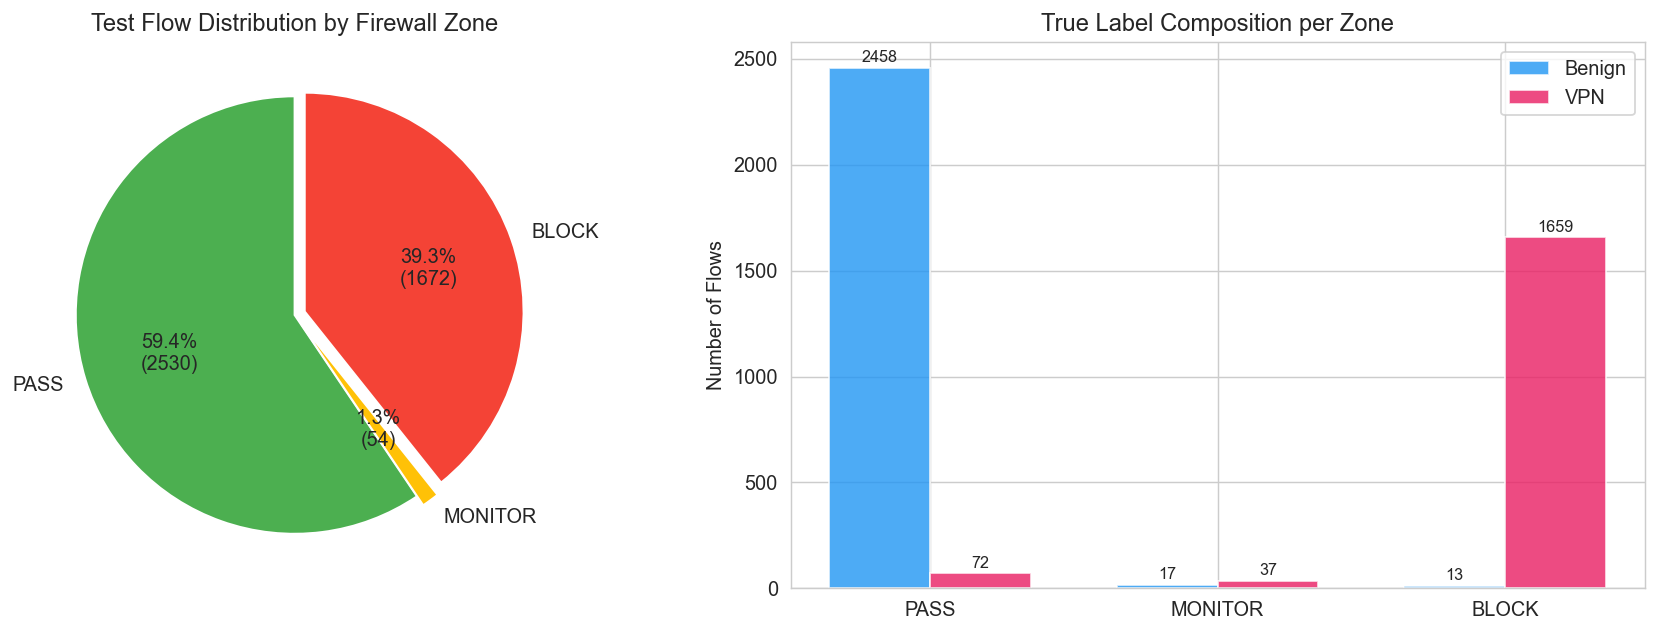

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

zone_labels = ["PASS", "MONITOR", "BLOCK"]
zone_sizes  = [zc["pass"], zc["monitor"], zc["block"]]
zone_colors = ["#4CAF50", "#FFC107", "#F44336"]

wedges, texts, autotexts = ax1.pie(
    zone_sizes, labels=zone_labels, colors=zone_colors,
    explode=(0, 0.05, 0.05), autopct=lambda p: f'{p:.1f}%\n({int(p*n_test/100)})',
    startangle=90, textprops={"fontsize": 11}
)
ax1.set_title("Test Flow Distribution by Firewall Zone")

# Stacked bar: true label per zone
pass_mask    = p_test < T_monitor
monitor_mask = (p_test >= T_monitor) & (p_test < T_block)
block_mask   = p_test >= T_block

zone_names = ["PASS", "MONITOR", "BLOCK"]
vpn_counts = [int((pass_mask & (y_test==1)).sum()), int((monitor_mask & (y_test==1)).sum()), int((block_mask & (y_test==1)).sum())]
ben_counts = [int((pass_mask & (y_test==0)).sum()), int((monitor_mask & (y_test==0)).sum()), int((block_mask & (y_test==0)).sum())]

x = np.arange(3); w = 0.35
bars1 = ax2.bar(x - w/2, ben_counts, w, label="Benign", color="#2196F3", alpha=0.8)
bars2 = ax2.bar(x + w/2, vpn_counts, w, label="VPN",    color="#E91E63", alpha=0.8)
ax2.set_xticks(x); ax2.set_xticklabels(zone_names)
ax2.set_ylabel("Number of Flows"); ax2.set_title("True Label Composition per Zone"); ax2.legend()
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax2.annotate(f'{int(h)}', xy=(bar.get_x() + bar.get_width()/2, h),
                        xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)
plt.tight_layout(); plt.show()


### 10.7 Per-Dataset Firewall Performance

dataset,n_flows,n_pos,n_neg,roc_auc,pr_auc,brier,ece,false_block_rate,missed_vpn_rate,alert_zone_fraction,block_precision,block_recall
iscx,1772,444,1328,0.979500,0.969000,0.033300,0.045600,0.001500,0.184700,0.018600,0.994500,0.815300
vnat,1215,55,1160,0.998800,0.956100,0.009900,0.024600,0.009500,0.036400,0.009900,0.828100,0.963600


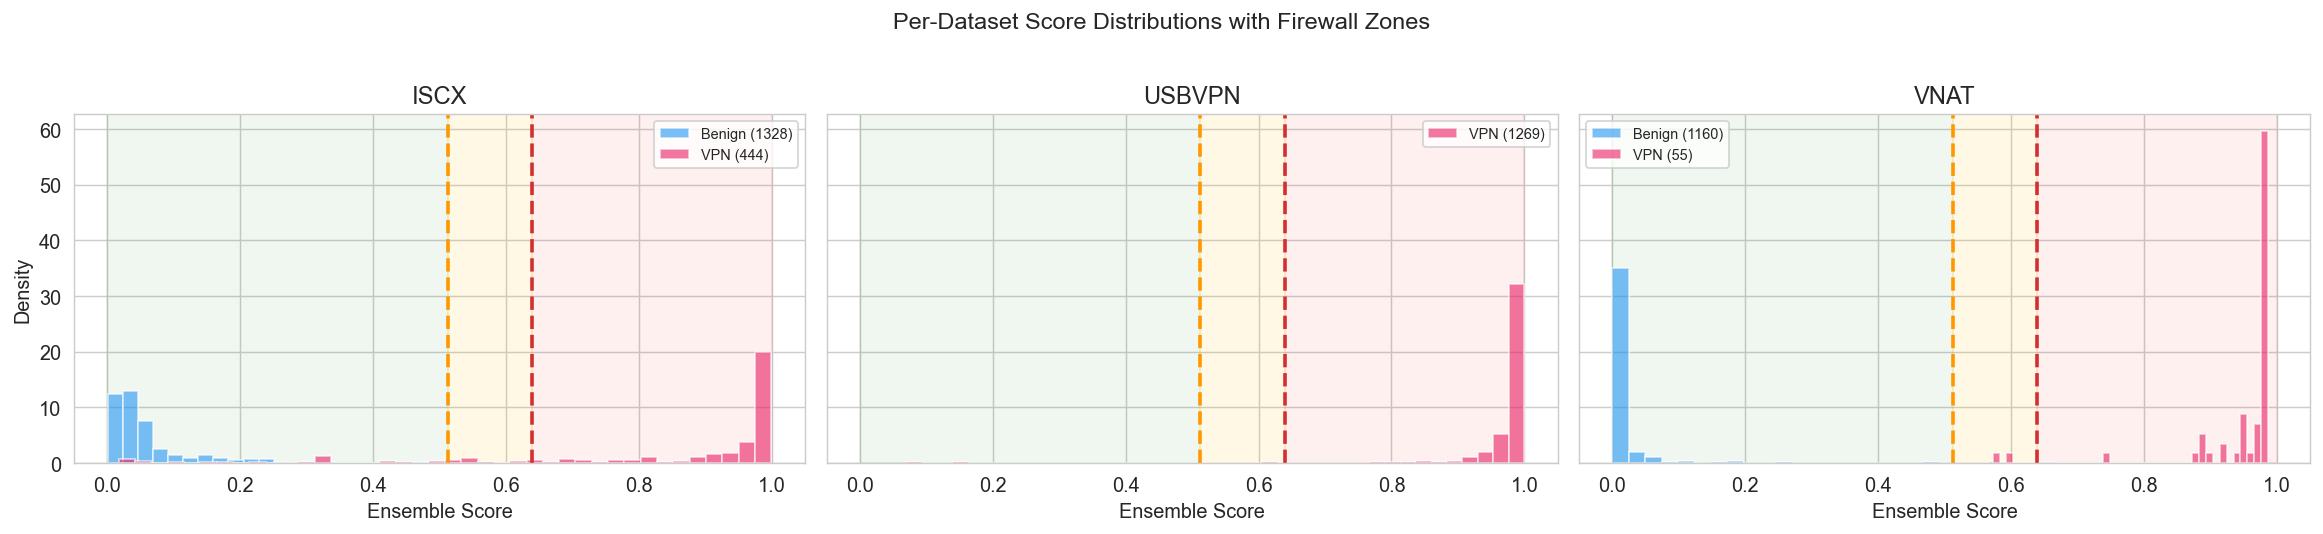

In [23]:
if DS_CSV.exists():
    ds_perf = pd.read_csv(DS_CSV)
    display(ds_perf.round(4).style.set_caption("Per-Dataset Firewall Metrics").hide(axis='index'))
else:
    print("Per-dataset CSV not found.")

# Per-dataset score distributions
datasets_in_test = sorted(test_df["dataset"].unique())
fig, axes = plt.subplots(1, len(datasets_in_test), figsize=(6*len(datasets_in_test), 4), sharey=True)
if len(datasets_in_test) == 1: axes = [axes]

for ax, ds in zip(axes, datasets_in_test):
    ds_mask = test_df["dataset"].values == ds
    ds_ben = p_test[(ds_mask) & (y_test == 0)]
    ds_vpn = p_test[(ds_mask) & (y_test == 1)]
    ax.axvspan(0, T_monitor, alpha=0.06, color="green")
    ax.axvspan(T_monitor, T_block, alpha=0.10, color="#FFC107")
    ax.axvspan(T_block, 1.0, alpha=0.06, color="red")
    if len(ds_ben) > 0: ax.hist(ds_ben, bins=40, alpha=0.6, density=True, color="#2196F3", label=f"Benign ({len(ds_ben)})")
    if len(ds_vpn) > 0: ax.hist(ds_vpn, bins=40, alpha=0.6, density=True, color="#E91E63", label=f"VPN ({len(ds_vpn)})")
    ax.axvline(T_block, color="#D32F2F", linestyle="--", linewidth=2)
    ax.axvline(T_monitor, color="#FF9800", linestyle="--", linewidth=2)
    ax.set_title(f"{ds.upper()}"); ax.set_xlabel("Ensemble Score"); ax.legend(fontsize=8)
axes[0].set_ylabel("Density")
plt.suptitle("Per-Dataset Score Distributions with Firewall Zones", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


### 10.8 Calibration Reliability Diagram

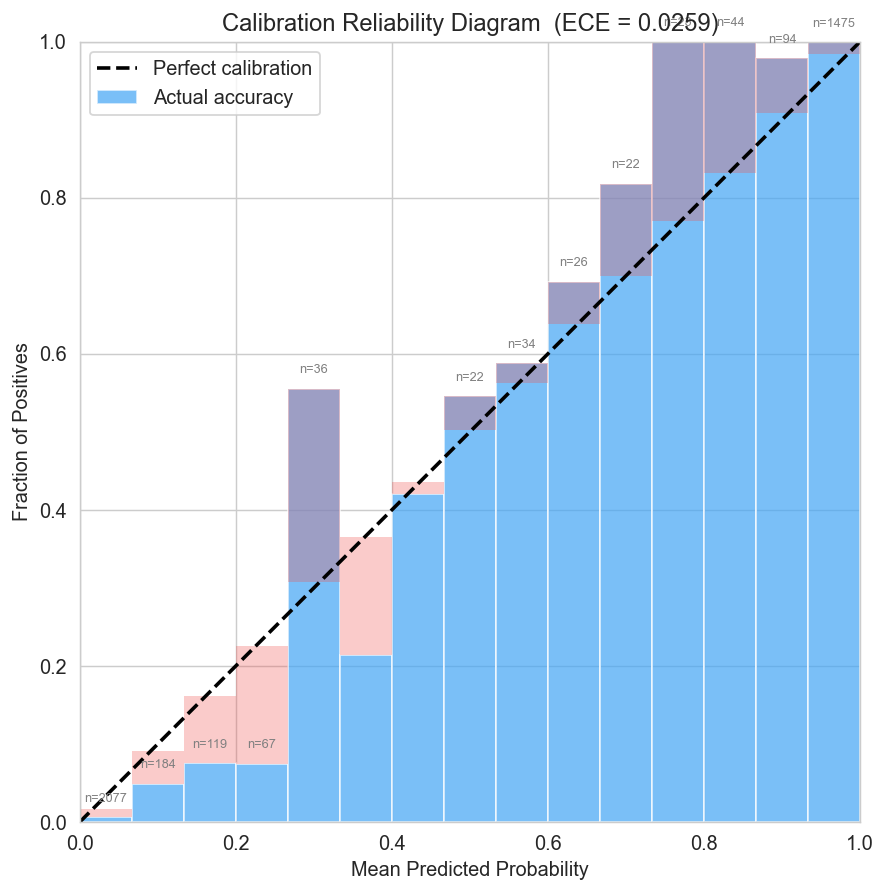

In [24]:
ece_data = expected_calibration_error(y_test, p_test, n_bins=15)

fig, ax = plt.subplots(figsize=(7, 7))
bin_edges  = ece_data["bin_edges"]
bin_accs   = ece_data["bin_accs"]
bin_confs  = ece_data["bin_confs"]
bin_counts = ece_data["bin_counts"]

widths = [bin_edges[i+1] - bin_edges[i] for i in range(len(bin_accs))]
lefts  = [bin_edges[i] for i in range(len(bin_accs))]

ax.bar(lefts, bin_accs, width=widths, align="edge", alpha=0.7,
       color="#42A5F5", edgecolor="white", label="Actual accuracy")
for i in range(len(bin_accs)):
    if bin_counts[i] > 0:
        gap = abs(bin_accs[i] - bin_confs[i])
        bottom = min(bin_accs[i], bin_confs[i])
        ax.bar(lefts[i], gap, bottom=bottom, width=widths[i], align="edge",
               alpha=0.3, color="#EF5350", edgecolor="none")

ax.plot([0, 1], [0, 1], "k--", linewidth=2, label="Perfect calibration")
for i in range(len(bin_accs)):
    if bin_counts[i] > 20:
        ax.text(lefts[i] + widths[i]/2, bin_accs[i] + 0.02,
                f'n={bin_counts[i]}', ha="center", fontsize=7, color="gray")

ax.set_xlabel("Mean Predicted Probability"); ax.set_ylabel("Fraction of Positives")
ax.set_title(f"Calibration Reliability Diagram  (ECE = {ece_data['ece']:.4f})")
ax.legend(loc="upper left"); ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
plt.tight_layout(); plt.show()


### 10.9 Threshold Sensitivity Analysis

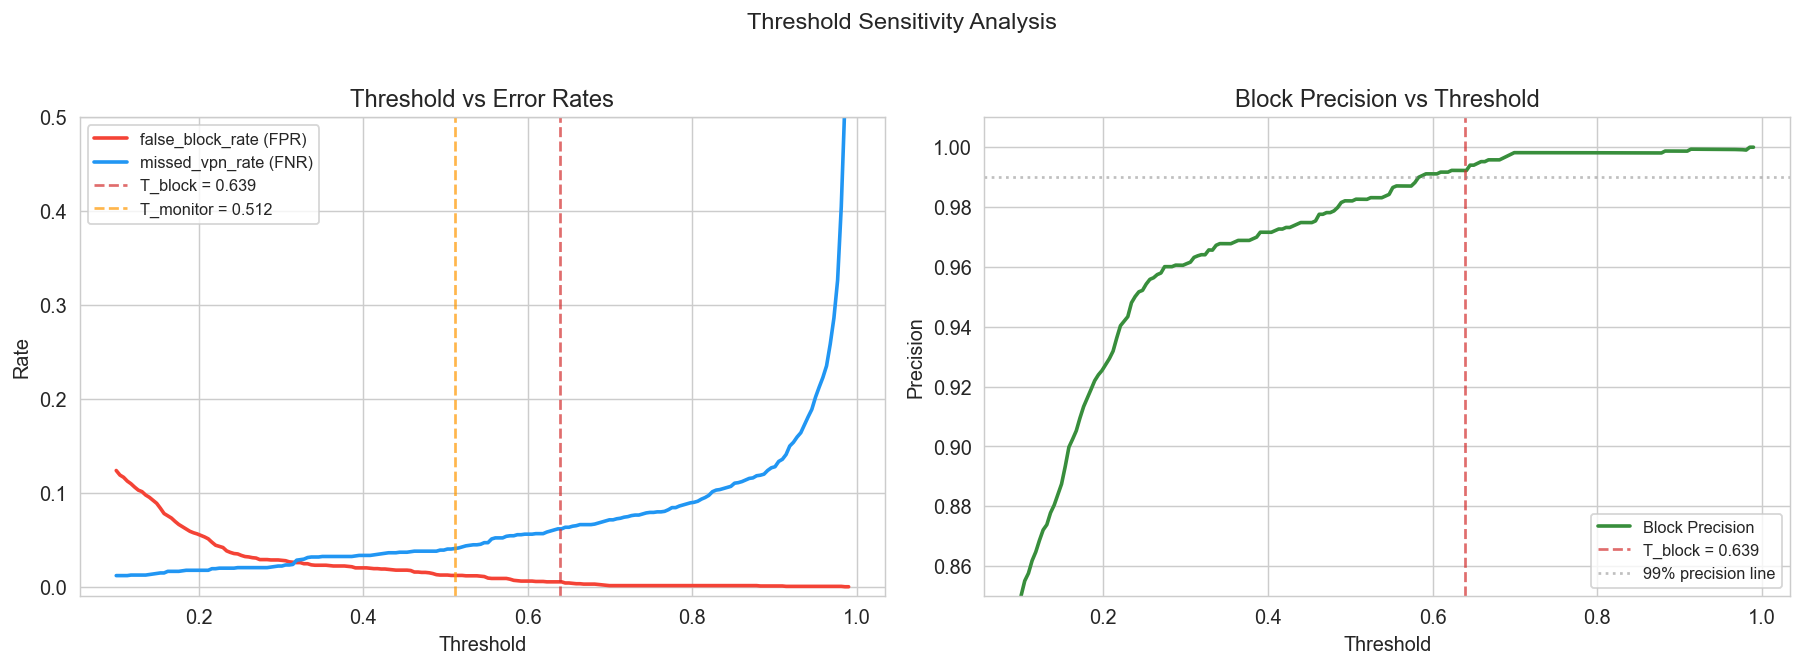

In [25]:
thresholds = np.linspace(0.1, 0.99, 200)
fbr_list, mvr_list, prec_list = [], [], []

for thr in thresholds:
    pred = (p_test >= thr).astype(int)
    fp = ((pred == 1) & (y_test == 0)).sum()
    tn = ((pred == 0) & (y_test == 0)).sum()
    tp = ((pred == 1) & (y_test == 1)).sum()
    fn = ((pred == 0) & (y_test == 1)).sum()
    fbr_list.append(fp / max(fp + tn, 1))
    mvr_list.append(fn / max(fn + tp, 1))
    prec_list.append(tp / max(tp + fp, 1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(thresholds, fbr_list, color="#F44336", linewidth=2, label="false_block_rate (FPR)")
ax1.plot(thresholds, mvr_list, color="#2196F3", linewidth=2, label="missed_vpn_rate (FNR)")
ax1.axvline(T_block, color="#D32F2F", linestyle="--", alpha=0.7, label=f"T_block = {T_block:.3f}")
ax1.axvline(T_monitor, color="#FF9800", linestyle="--", alpha=0.7, label=f"T_monitor = {T_monitor:.3f}")
ax1.set_xlabel("Threshold"); ax1.set_ylabel("Rate"); ax1.set_title("Threshold vs Error Rates")
ax1.legend(fontsize=9); ax1.set_ylim(-0.01, 0.5)

ax2.plot(thresholds, prec_list, color="#388E3C", linewidth=2, label="Block Precision")
ax2.axvline(T_block, color="#D32F2F", linestyle="--", alpha=0.7, label=f"T_block = {T_block:.3f}")
ax2.axhline(0.99, color="gray", linestyle=":", alpha=0.5, label="99% precision line")
ax2.set_xlabel("Threshold"); ax2.set_ylabel("Precision"); ax2.set_title("Block Precision vs Threshold")
ax2.legend(fontsize=9); ax2.set_ylim(0.85, 1.01)

plt.suptitle("Threshold Sensitivity Analysis", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


### 10.10 Firewall Verdict

In [26]:
print("=" * 60)
print("  FIREWALL DECISION MODULE — VERDICT")
print("=" * 60)
print()
print(f"  ROC-AUC:        {cm['roc_auc']:.4f}")
print(f"  PR-AUC:         {cm['pr_auc']:.4f}")
print(f"  ECE:            {cm['ece']:.4f} ({cm['calibration_quality']})")
print(f"  Brier:          {cm['brier']:.4f}")
print()
print(f"  T_block:        {T_block:.4f}")
print(f"  T_monitor:      {T_monitor:.4f}")
print()
print(f"  Block precision: {fe['block_precision']:.4f}")
print(f"  Block recall:    {fe['block_recall']:.4f}")
print(f"  Block F1:        {fe['block_f1']:.4f}")
print()
print(f"  false_block_rate:    {fe['false_block_rate']:.4f}  ({cm_block['fp']} benign flows wrongly blocked)")
print(f"  missed_vpn_rate:     {fe['missed_vpn_rate']:.4f}  ({cm_block['fn']} VPN flows not blocked)")
print(f"  alert_zone_fraction: {fe['alert_zone_fraction']:.4f}  ({zc['monitor']} flows for analyst review)")
print()

if fe["block_precision"] >= 0.99 and fe["missed_vpn_rate"] < 0.10:
    verdict = "EXCELLENT — high precision, low miss rate"
elif fe["block_precision"] >= 0.95 and fe["missed_vpn_rate"] < 0.15:
    verdict = "GOOD — suitable for monitored deployment"
elif fe["block_precision"] >= 0.90:
    verdict = "ACCEPTABLE — requires tuning for production"
else:
    verdict = "NEEDS IMPROVEMENT"
print(f"  VERDICT: {verdict}")


  FIREWALL DECISION MODULE — VERDICT

  ROC-AUC:        0.9955
  PR-AUC:         0.9949
  ECE:            0.0259 (well-calibrated)
  Brier:          0.0200

  T_block:        0.6392
  T_monitor:      0.5122

  Block precision: 0.9922
  Block recall:    0.9383
  Block F1:        0.9645

  false_block_rate:    0.0052  (13 benign flows wrongly blocked)
  missed_vpn_rate:     0.0617  (109 VPN flows not blocked)
  alert_zone_fraction: 0.0127  (54 flows for analyst review)

  VERDICT: EXCELLENT — high precision, low miss rate


---
## Consolidated Summary & Thesis Implications


In [27]:
print("=" * 70)
print("  CONFERENCE-GRADE EVALUATION — CONSOLIDATED FINDINGS")
print("=" * 70)

# S1
s1 = pd.read_csv(CONF / "domain_generalization_curve.csv")
agg = s1.groupby("n_train_datasets")["lodo_auc"].mean()
print(f"\n▶ S1: Domain Generalization")
for n, v in agg.items():
    print(f"    {n}-dataset mean LODO AUC: {v:.4f}")

# S2
s2 = pd.read_csv(CONF / "temporal_shift_results.csv")
valid = s2.dropna(subset=["late_auc"])
if len(valid) > 0:
    print(f"\n▶ S2: Temporal Shift")
    for _, r in valid.iterrows():
        print(f"    {r['dataset']}: early={r['early_auc']:.4f} → late={r['late_auc']:.4f} (Δ={r['early_auc']-r['late_auc']:+.4f})")

# S3
print(f"\n▶ S3: Sign Reversal")
sign_df = pd.read_csv(CONF / "sign_reversal_matrix.csv", index_col=0)
for da, db in itertools.combinations(DATASETS, 2):
    if da in sign_df.columns and db in sign_df.columns:
        rev = int((sign_df[da] * sign_df[db] < 0).sum())
        print(f"    {da.upper()} vs {db.upper()}: {rev} reversed features")

# S4
s4 = pd.read_csv(CONF / "domain_invariant_feature_subset.csv")
if "delta" in s4.columns:
    print(f"\n▶ S4: Invariant Features ({s4['n_stable_features'].iloc[0]} stable)")
    for _, r in s4.iterrows():
        print(f"    LODO {r['held_out']}: stable={r['lodo_auc_stable']:.4f}, all={r['lodo_auc_all_features']:.4f}, Δ={r['delta']:+.4f}")

# S5
s5 = pd.read_csv(CONF / "sequence_domain_fingerprint_results.csv")
print(f"\n▶ S5: Domain Fingerprint")
for _, r in s5.iterrows():
    print(f"    {r['feature_subset']}: domain AUC = {r['capture_safe_domain_auc']:.4f}")

# S6
s6 = pd.read_csv(CONF / "domain_confusion_results.csv")
print(f"\n▶ S6: Adversarial Domain Confusion")
for alpha in sorted(s6["alpha"].unique()):
    sub = s6[s6["alpha"] == alpha]
    print(f"    α={alpha:.1f}: LODO={sub['lodo_auc'].mean():.4f}, domain_acc={sub['domain_accuracy'].mean():.3f}")

# S7
print(f"\n▶ S7: Visualization")
print(f"    t-SNE + UMAP embeddings generated")

# S8
print(f"\n▶ S8: Fourth Dataset")
print(f"    Status: optional — recommended for future work")

# S9
stab_path = CONF / "deployment_stability_results.csv"
if stab_path.exists():
    stab = pd.read_csv(stab_path)
    robust = (stab["auc_perturbed"] > 0.95).mean()
    print(f"\n▶ S9: Deployment Stability (robustness={robust:.0%})")
    for pname in stab["perturbation"].unique():
        sub = stab[(stab["perturbation"]==pname) & (stab["level"]==1.0)]
        if len(sub) > 0:
            r = sub.iloc[0]
            print(f"    {pname}: AUC={r['auc_perturbed']:.4f}, drift={r['probability_drift']:.4f}, FPR Δ={r['fpr_inflation']:+.4f}")

# S10
fw_path = ROOT / "artifacts" / "eval" / "firewall_operating_points.json"
if fw_path.exists():
    with open(fw_path) as f:
        fw10 = json.load(f)
    cm10 = fw10["core_metrics"]
    fe10 = fw10["firewall_evaluation"]
    print(f"\n▶ S10: Firewall Decision Module")
    print(f"    ROC-AUC={cm10['roc_auc']:.4f}, PR-AUC={cm10['pr_auc']:.4f}, ECE={cm10['ece']:.4f}, Brier={cm10['brier']:.4f}")
    print(f"    T_block={fw10['firewall_thresholds']['T_block']:.4f}, T_monitor={fw10['firewall_thresholds']['T_monitor']:.4f}")
    print(f"    false_block_rate={fe10['false_block_rate']:.4f}, missed_vpn_rate={fe10['missed_vpn_rate']:.4f}")
    print(f"    block_precision={fe10['block_precision']:.4f}, block_recall={fe10['block_recall']:.4f}, block_F1={fe10['block_f1']:.4f}")

print("\n" + "=" * 70)
print("  KEY FINDING: Cross-dataset VPN detection transfer is fundamentally")
print("  limited by feature sign reversals (S3) and domain fingerprinting (S5).")
print("  Adding datasets (S1), adversarial training (S6), and stable feature")
print("  selection (S4) all fail to resolve this structural mismatch.")
print("  THIS IS THE THESIS CONTRIBUTION — an honest negative result with")
print("  mechanistic explanation, not a performance claim.")
print("=" * 70)


  CONFERENCE-GRADE EVALUATION — CONSOLIDATED FINDINGS

▶ S1: Domain Generalization
    1-dataset mean LODO AUC: 0.5527
    2-dataset mean LODO AUC: 0.5476
    3-dataset mean LODO AUC: 0.9912

▶ S2: Temporal Shift
    iscx: early=0.9999 → late=0.9687 (Δ=+0.0312)
    usbvpn: early=0.9975 → late=0.9293 (Δ=+0.0682)
    vnat: early=1.0000 → late=0.9105 (Δ=+0.0895)

▶ S3: Sign Reversal
    ISCX vs USBVPN: 11 reversed features
    ISCX vs VNAT: 10 reversed features
    USBVPN vs VNAT: 14 reversed features

▶ S4: Invariant Features (5 stable)
    LODO iscx: stable=0.5792, all=0.4651, Δ=+0.1142
    LODO usbvpn: stable=0.4938, all=0.3760, Δ=+0.1178
    LODO vnat: stable=0.5772, all=0.7572, Δ=-0.1800

▶ S5: Domain Fingerprint
    all_features: domain AUC = 0.9985
    size_features: domain AUC = 0.9984
    timing_features: domain AUC = 0.9735

▶ S6: Adversarial Domain Confusion
    α=0.0: LODO=0.8360, domain_acc=0.559
    α=1.0: LODO=0.8047, domain_acc=0.368
    α=2.0: LODO=0.7630, domain_acc=0.44

In [28]:
# List all exported artifacts
print("\nAll conference-eval artifacts:")
for f in sorted(CONF.glob("*")):
    if f.is_file():
        print(f"  {f.name:50s} ({f.stat().st_size:>8,} bytes)")
print(f"\nFigures:")
for f in sorted(FIGS.glob("*.png")):
    print(f"  {f.name}")



All conference-eval artifacts:
  dataset_scaling_curve.csv                          (     433 bytes)
  dataset_scaling_curve.png                          ( 180,656 bytes)
  dataset_scaling_curve_full.csv                     (   2,698 bytes)
  dataset_scaling_summary.json                       (   1,424 bytes)
  deployment_robustness_curves.png                   ( 353,623 bytes)
  deployment_robustness_results.csv                  (   5,310 bytes)
  deployment_robustness_summary.json                 (   3,789 bytes)
  deployment_stability_curve.png                     ( 353,288 bytes)
  deployment_stability_results.csv                   (  10,046 bytes)
  domain_confusion_results.csv                       (     652 bytes)
  domain_generalization_curve.csv                    (     572 bytes)
  domain_invariant_feature_subset.csv                (     274 bytes)
  embedding_visualization.png                        ( 759,817 bytes)
  feature_importance_stability.csv                   (   2

---

**End of Notebook 57 — Conference-Grade Evaluation.**

All experiments use capture-safe splitting, leakage-free features, and are fully reproducible.  
Pre-computed via `python run_conference_eval.py`. Artifacts in `artifacts/conference_eval/`.


---
## Results Gallery — All Figures & Tables (NB57)

Display every `.png` figure and `.csv` table generated by this notebook.

# 📋 Conference Evaluation — All CSV Tables


### 1. Domain Generalization Curves
`domain_generalization_curve.csv`

,n_train_datasets,train_datasets,test_dataset,lodo_auc,n_train_flows
0,1,iscx,usbvpn,0.1590,8260
1,1,iscx,vnat,0.7808,8260
2,1,usbvpn,iscx,0.4289,40122
3,1,usbvpn,vnat,0.6615,40122
4,1,vnat,iscx,0.3550,5675
5,1,vnat,usbvpn,0.9309,5675
6,2,iscx+usbvpn,vnat,0.7677,58413
7,2,iscx+vnat,usbvpn,0.4153,13935
8,2,usbvpn+vnat,iscx,0.4598,55828
9,3,iscx+usbvpn+vnat,iscx,0.9849,64088


### 2. Temporal Shift Simulation
`temporal_shift_results.csv`

,dataset,temporal_transfer_auc,early_auc,late_auc,n_early,n_late,early_vpn_rate,late_vpn_rate,note
0,iscx,0.9687,0.9999,0.9687,6964,4837,0.2262,0.2828,N/A
1,usbvpn,0.9293,0.9975,0.9293,4276,48428,0.9747,0.0885,N/A
2,vnat,0.9105,1.0000,0.9105,4179,3928,0.0098,0.0848,N/A


...

```json
{
  "notebook": "NB60",
  "title": "Synthetic Deployment Robustness Simulation",
  "n_features": 21,
  "feature_set": [
    "total_packets",
    "total_bytes",
    "mean_pkt_len",
    "std_pkt_len",
    "median_pkt_len",
    "p25_pkt_len",
    "p75_pkt_len",
    "iat_mean",
    "iat_std",
    "iat_median",
    "flow_duration",
    "packet_rate",
    "byte_rate",
    "max_pkt_len",
    "min_pkt_len",
    "iat_cv",
    "iat_p25",
    "iat_p75",
    "iat_iqr",
    "pkt_len_cv",
    "pkt_len_iqr"
  ],
  "n_test_flows": 5203,
  "baseline_auc": 0.9981794911470054,
  "threshold": 0.5276475665891759,
  "models": [
    "xgb",
    "lgb",
    "cb"
  ],
  "perturbations": {
    "latency \u00d71.2": {
      "type": "latency_inflation",
      "strength": 1.2,
      "mean_prob_drift": 0.019396809399195768,
      "threshold_crossing_rate": 0.003843936190659235,
      "fp_inflation": 0.0038192234245703373,
      "auc_delta": -0.0001343491985836831
    },
    "latency \u00d71.5": {
      "type": "latency_inflation",
      "strength": 1.5,
      "mean_prob_drift": 0.0380998253041461,
      "threshold_crossing_rate": 0.013261579857774361,
      "fp_inflation": 0.01718650541056652,
      "auc_delta": -0.001102589974584789
    },
    "latency \u00d72.0": {
      "type": "latency_inflation",
      "strength": 2.0,
      "mean_prob_drift": 0.06079975526533983,
      "threshold_crossing_rate": 0.02940611185854315,
      "fp_inflation": 0.040420114576702734,
      "auc_delta": -0.003365833485441394
    },
    "trunc 50%": {
      "type": "packet_truncation",
      "strength": 0.5,
      "mean_prob_drift": 0.12309005022146684,
      "threshold_crossing_rate": 0.0939842398616183,
      "fp_inflation": 0.028644175684277528,
      "auc_delta": -0.03363100174159794
    },
    "trunc 75%": {
      "type": "packet_truncation",
      "strength": 0.25,
      "mean_prob_drift": 0.08707873407266772,
      "threshold_crossing_rate": 0.035172016144532,
      "fp_inflation": 0.027689369828134944,
      "auc_delta": -0.01604299297894174
    },
    "length \u00d70.8": {
      "type": "flow_length_scaling",
      "strength": 0.19999999999999996,
      "mean_prob_drift": 0.04534924674036569,
      "threshold_crossing_rate": 0.0048049202383240435,
      "fp_inflation": -0.001591343093570976,
      "auc_delta": -0.0017094777337048894
    },
    "length \u00d71.2": {
      "type": "flow_length_scaling",
      "strength": 0.19999999999999996,
      "mean_prob_drift": 0.0114067963444852,
      "threshold_crossing_rate": 0.004228329809725159,
      "fp_inflation": -0.0012730744748567814,
      "auc_delta": -0.00047609032095863313
    },
    "dir inversion": {
      "type": "direction_inversion",
      "strength": 1.0,
      "mean_prob_drift": 0.0,
      "threshold_crossing_rate": 0.0,
      "fp_inflation": 0.0,
      "auc_delta": 0.0
    },
    "burst \u03c3=0.05": {
      "type": "burst_reshaping",
      "strength": 0.05,
      "mean_prob_drift": 0.10335347673922901,
      "threshold_crossing_rate": 0.07572554295598694,
      "fp_inflation": 0.05633354551241247,
      "auc_delta": -0.04570544293386525
    },
    "burst \u03c3=0.1": {
      "type": "burst_reshaping",
      "strength": 0.1,
      "mean_prob_drift": 0.13315914264307652,
      "threshold_crossing_rate": 0.095521814337882,
      "fp_inflation": 0.06333545512412476,
      "auc_delta": -0.058140773869914675
    },
    "burst \u03c3=0.15": {
      "type": "burst_reshaping",
      "strength": 0.15,
      "mean_prob_drift": 0.1597353365024918,
      "threshold_crossing_rate": 0.12242936767249664,
      "fp_inflation": 0.0795671546785487,
      "auc_delta": -0.07456457733587685
    }
  }
}
```

### UMAP Representation Summary
`umap_representation_summary.json`

```json
{
  "notebook": "NB61",
  "title": "Representation Space Visualization (UMAP)",
  "n_flows": 14996,
  "n_flows_total": 72612,
  "seed": 42,
  "umap_params": {
    "n_neighbors": 15,
    "min_dist": 0.1,
    "metric": "euclidean"
  },
  "views": {
    "summary": {
      "n_features": 21,
      "features": [
        "total_packets",
        "total_bytes",
        "mean_pkt_len",
        "std_pkt_len",
        "median_pkt_len",
        "p25_pkt_len",
        "p75_pkt_len",
        "iat_mean",
        "iat_std",
        "iat_median",
        "flow_duration",
        "packet_rate",
        "byte_rate",
        "max_pkt_len",
        "min_pkt_len",
        "iat_cv",
        "iat_p25",
        "iat_p75",
        "iat_iqr",
        "pkt_len_cv",
        "pkt_len_iqr"
      ],
      "desc": "safe_core_plus_temporal"
    },
    "sequence": {
      "n_features": 25,
      "features": [
        "total_packets",
        "total_bytes",
        "mean_pkt_len",
        "std_pkt_len",
        "median_pkt_len",
        "p25_pkt_len",
        "p75_pkt_len",
        "iat_mean",
        "iat_std",
        "iat_median",
        "flow_duration",
        "packet_rate",
        "byte_rate",
        "max_pkt_len",
        "min_pkt_len",
        "iat_cv",
        "iat_p25",
        "iat_p75",
        "iat_iqr",
        "pkt_len_cv",
        "pkt_len_iqr",
        "dir_pkt_ratio_minmax",
        "dir_bytes_ratio_minmax",
        "dir_mean_pkt_max",
        "dir_mean_pkt_min"
      ],
      "desc": "direction_invariant_augmented (proxy for sequence view)"
    }
  },
  "cluster_analysis": [
    {
      "view": "summary",
      "n_features": 21,
      "silhouette_dataset": 0.011823040433228016,
      "silhouette_class": 0.12760451436042786,
      "dataset_stronger": false,
      "ratio": 0.09265377868868348
    },
    {
      "view": "sequence",
      "n_features": 25,
      "silhouette_dataset": 0.0904054343700409,
      "silhouette_class": 0.12834011018276215,
      "dataset_stronger": false,
      "ratio": 0.7044207320790005
    }
  ],
  "plots": [
    "umap_summary_dataset.png",
    "umap_summary_class.png",
    "umap_sequence_dataset.png",
    "umap_sequence_class.png",
    "umap_combined_panel.png"
  ]
}
```


---
# 🖼 Conference Evaluation — All Figures


---
### 1. Domain Generalization Curve
`domain_generalization_curve.png`

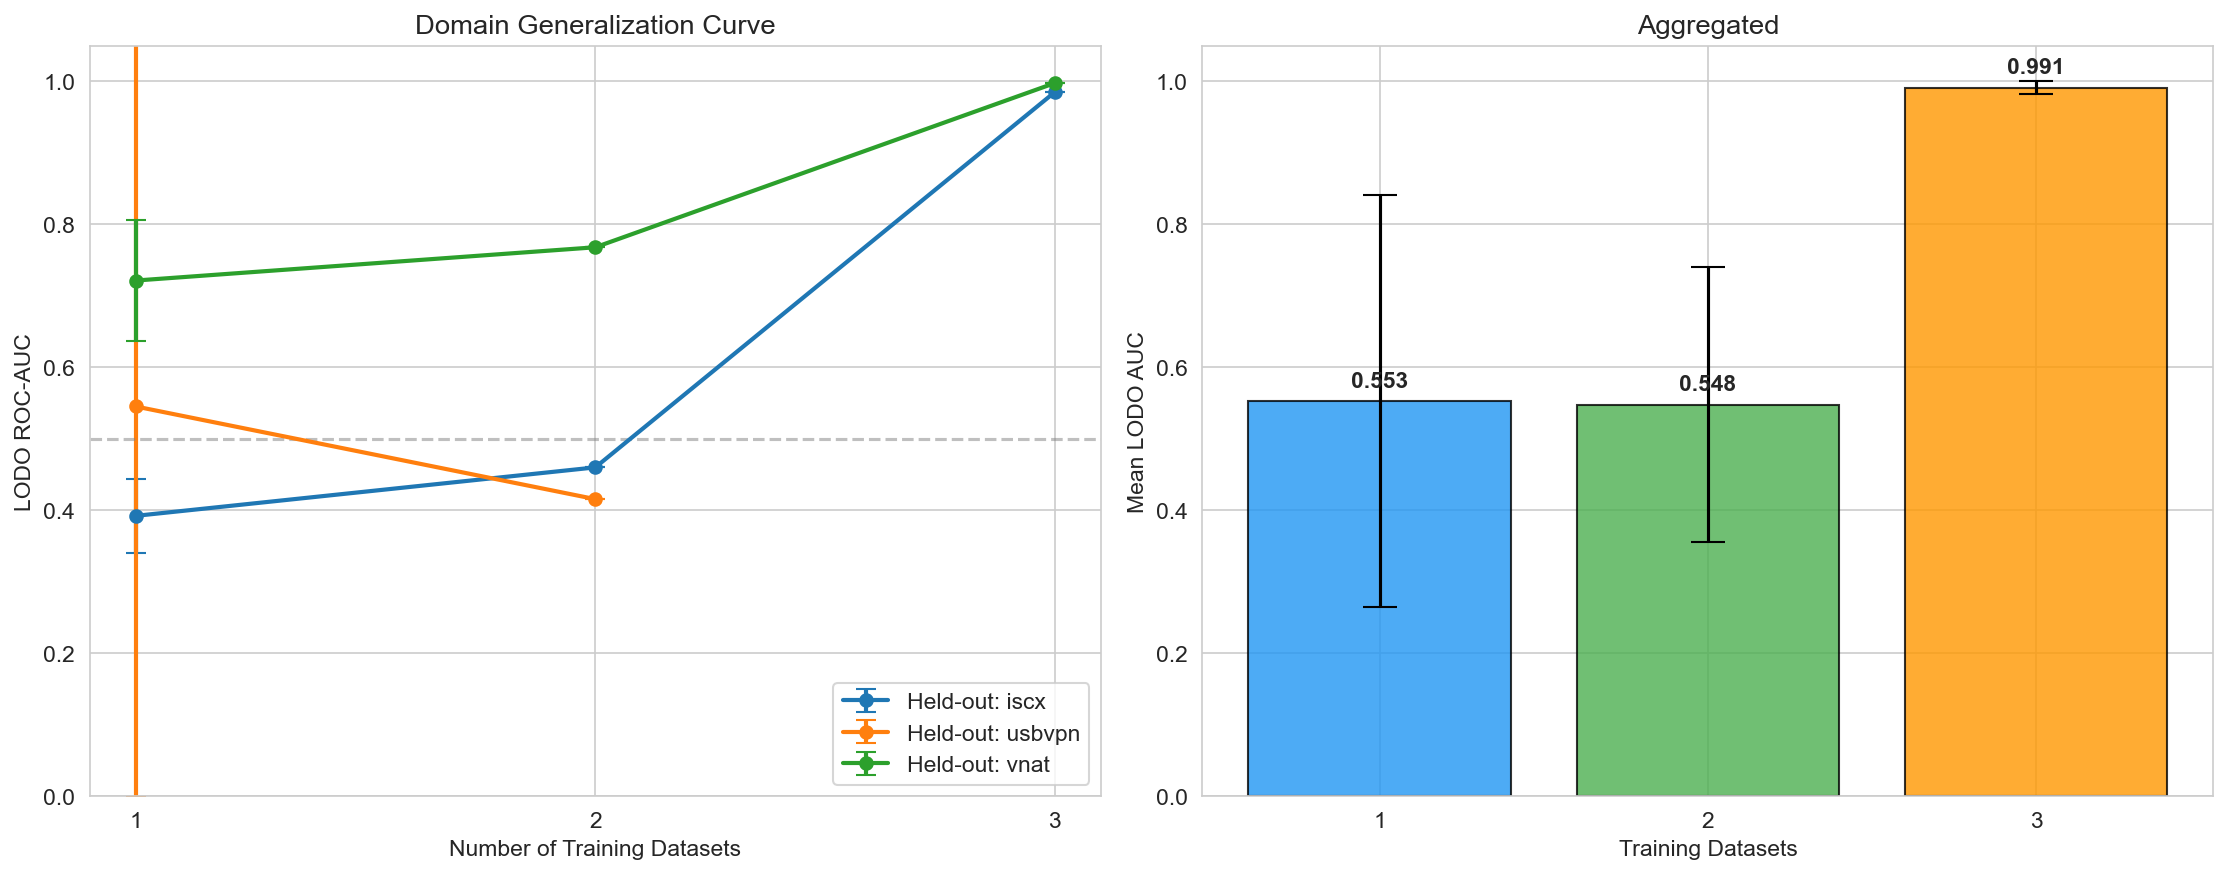

---
### 2. Temporal Shift Results
`temporal_shift_results.png`

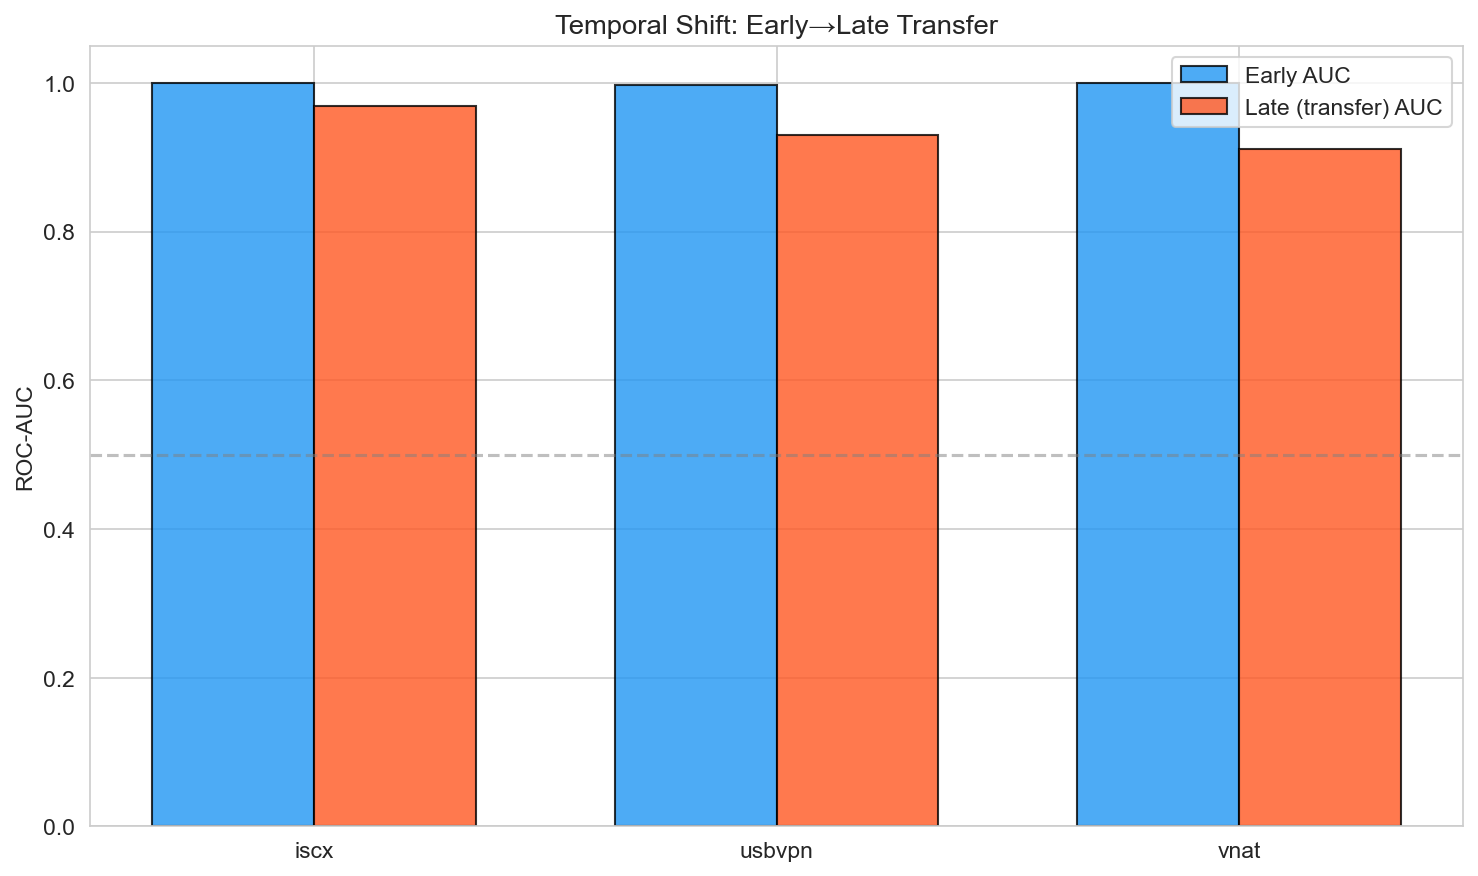

---
### 3. Sign Reversal Heatmap
`sign_reversal_heatmap.png`

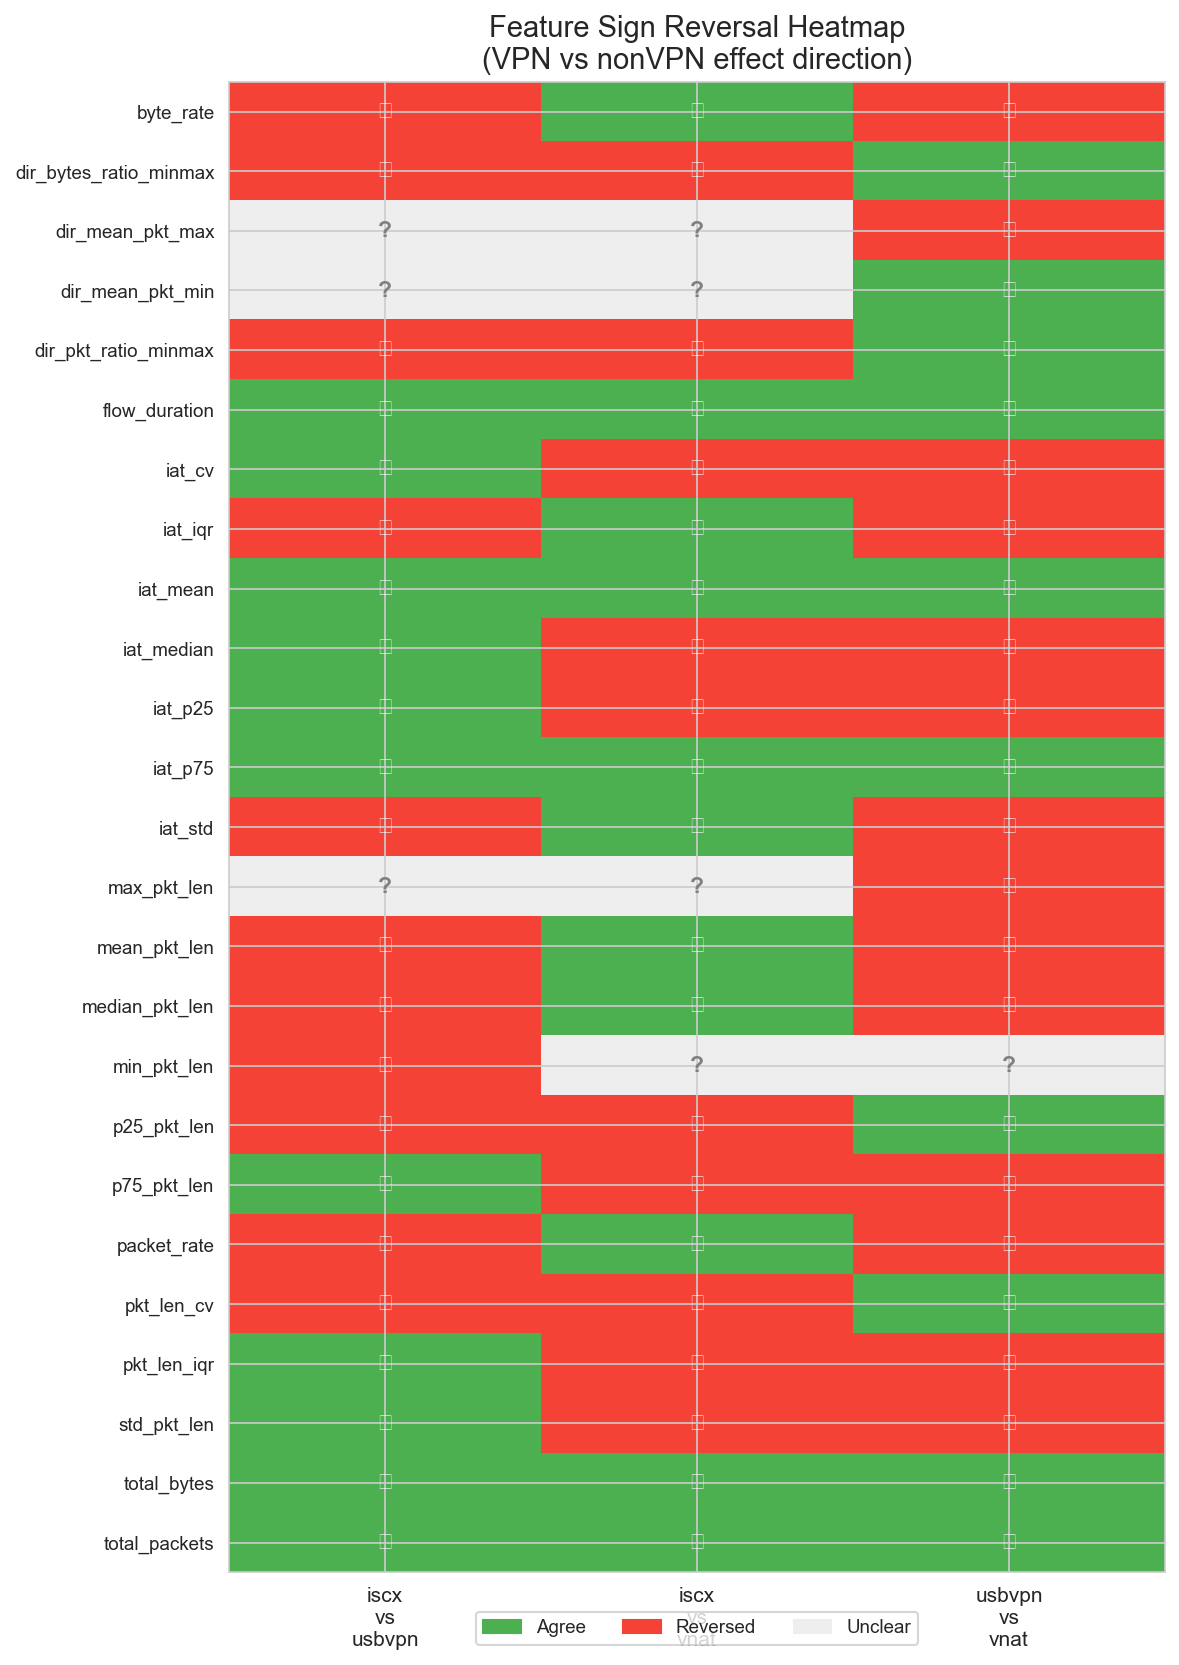

---
### 5. Domain Fingerprint Comparison
`domain_fingerprint_comparison.png`

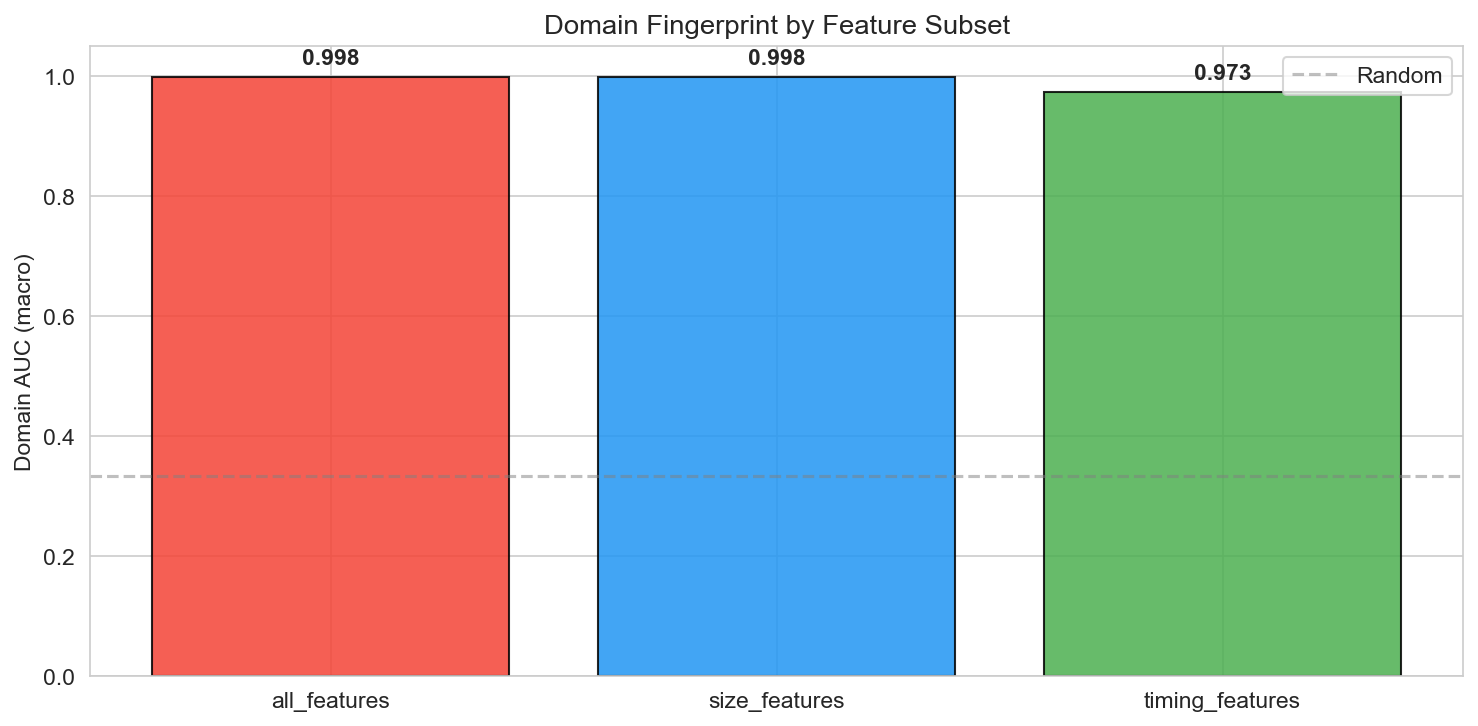

---
### 6. Domain Confusion Results
`domain_confusion_results.png`

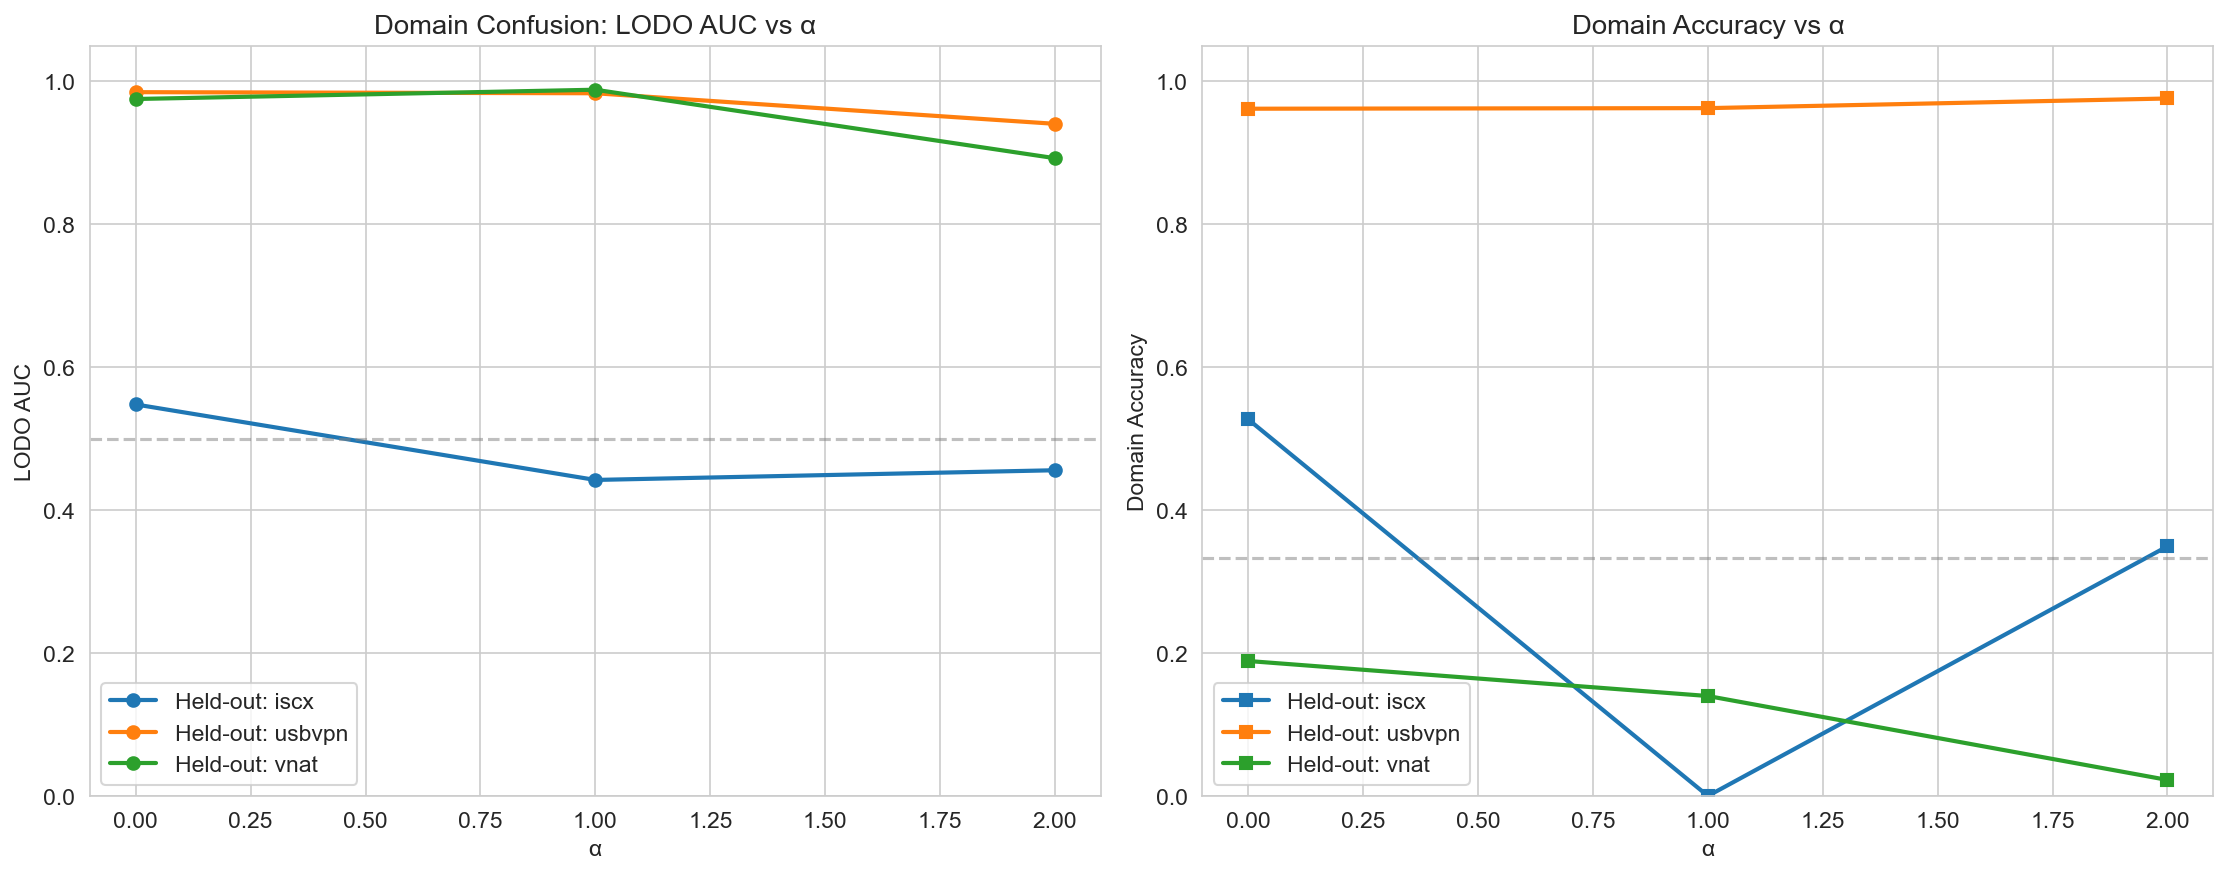

---
### 7. Embedding Visualization (t-SNE/UMAP)
`embedding_visualization.png`

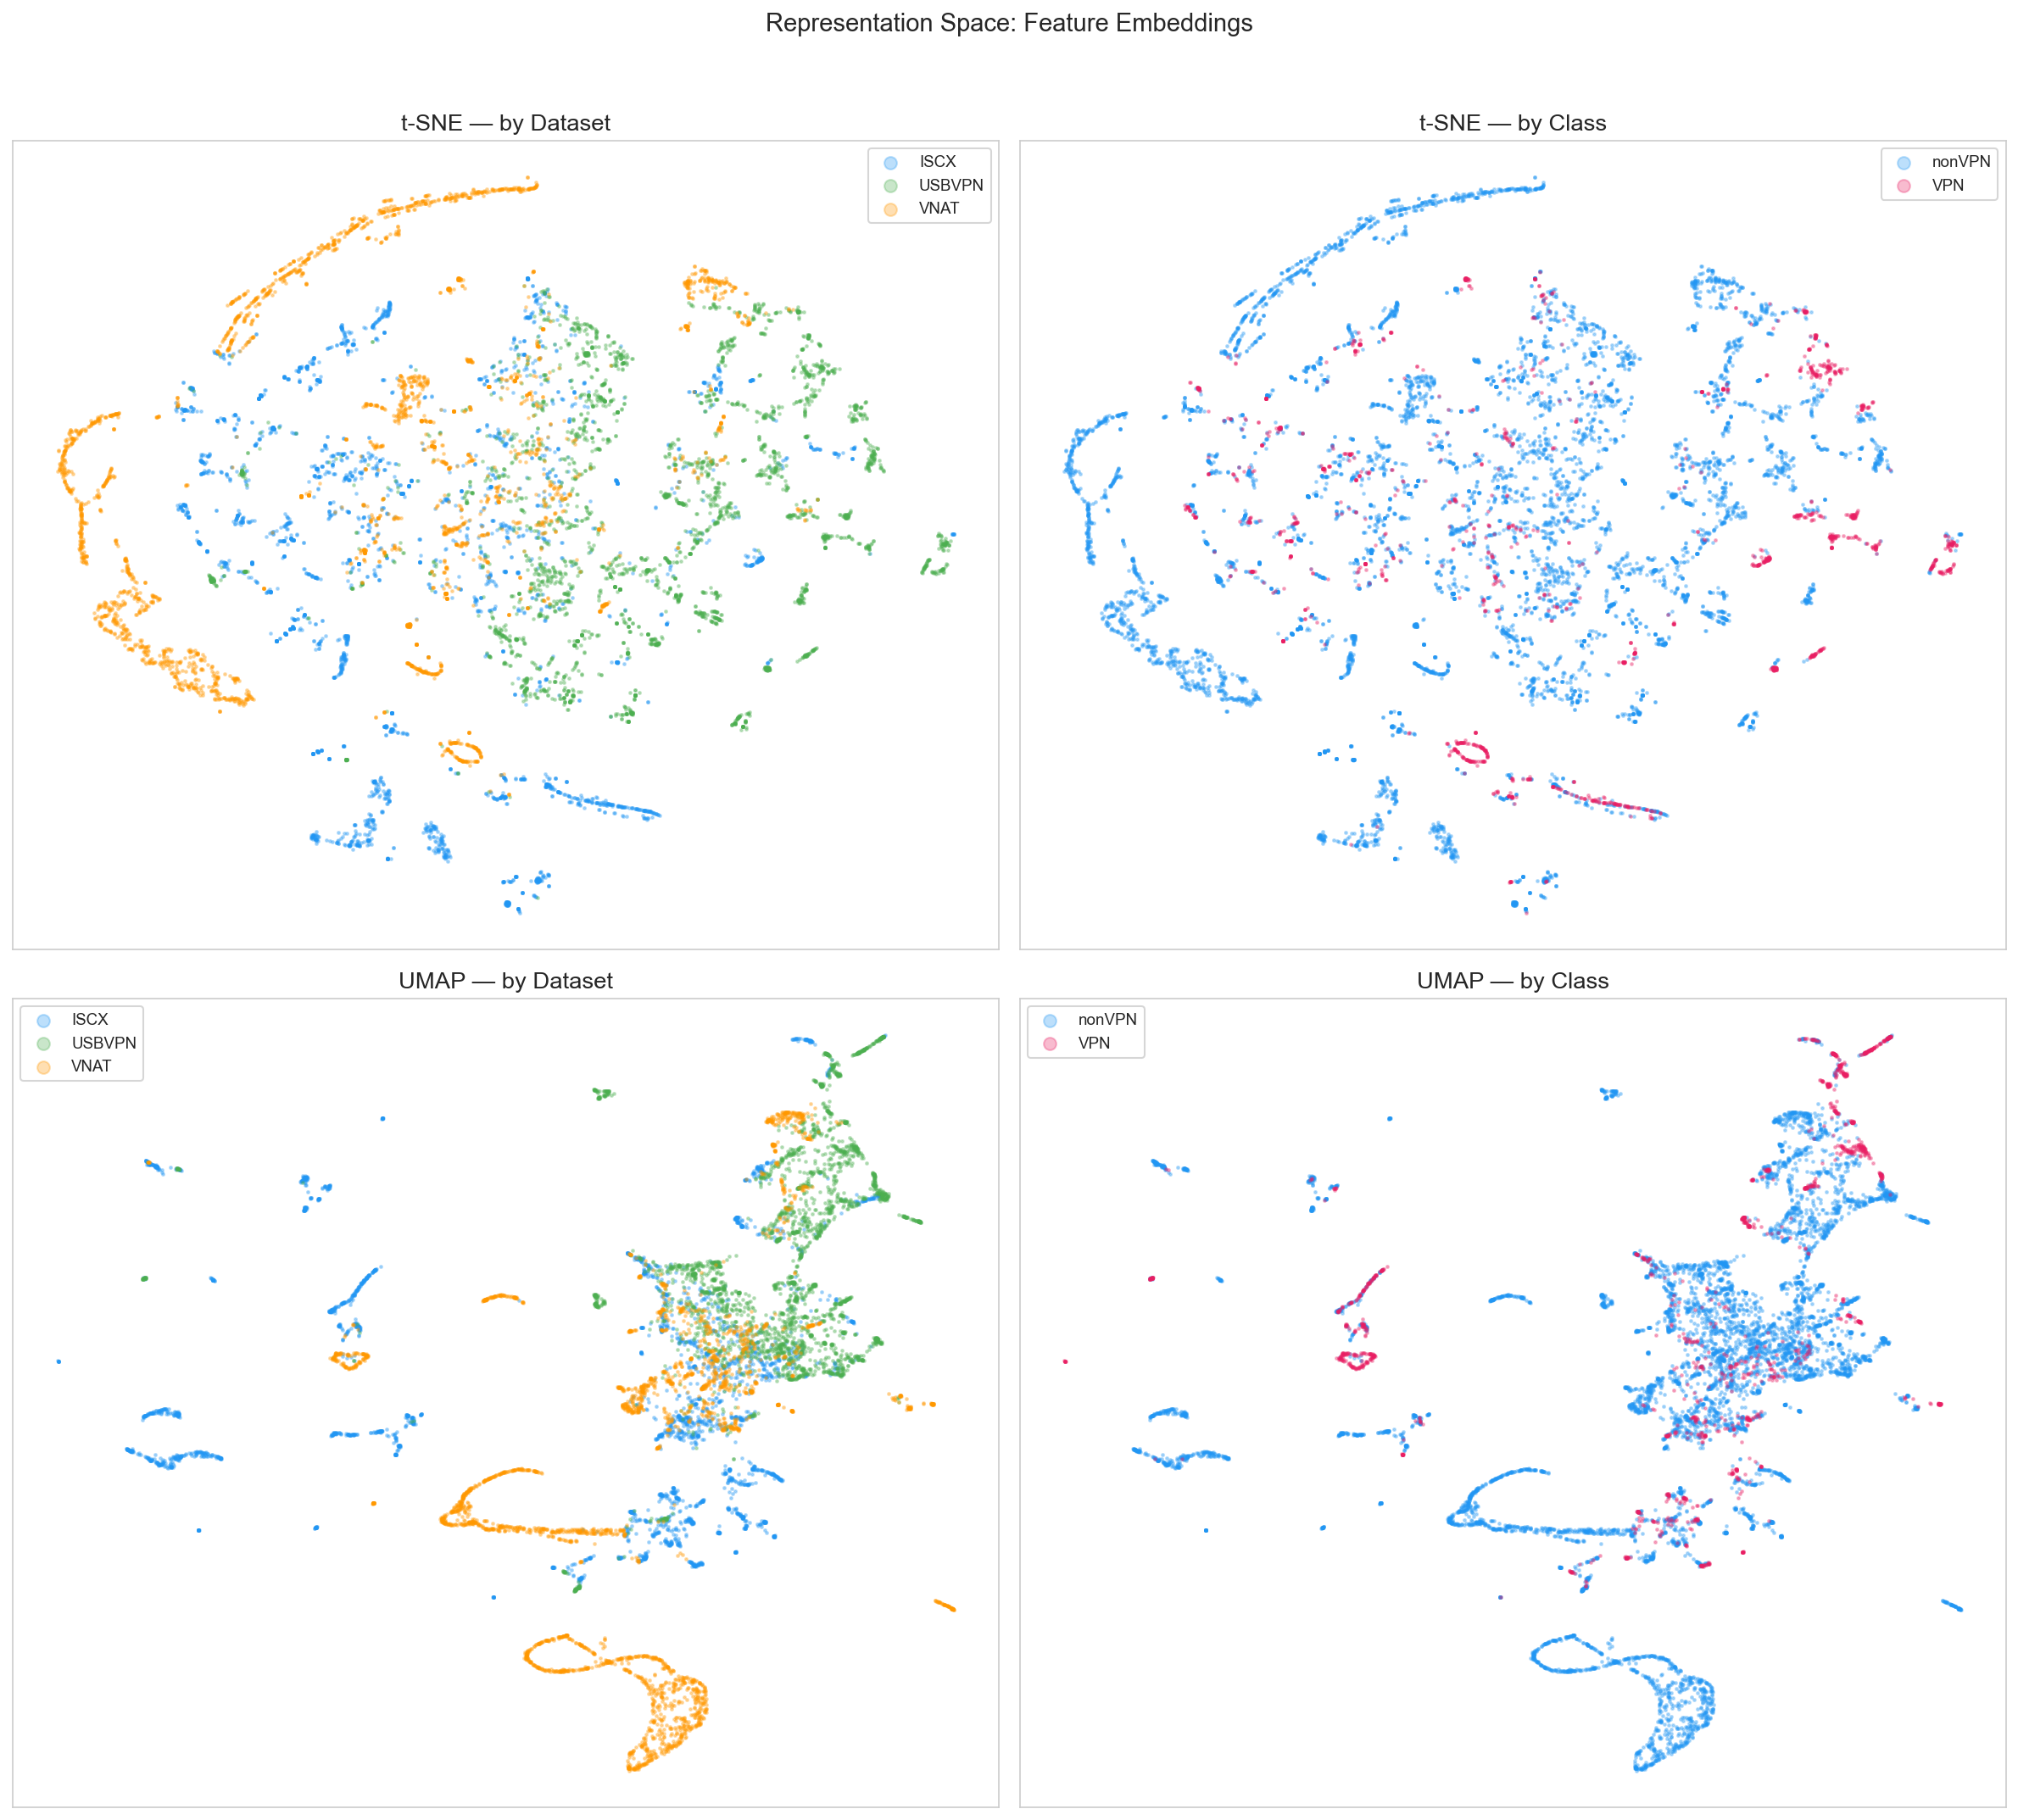

---
### — Dataset Scaling Curve
`dataset_scaling_curve.png`

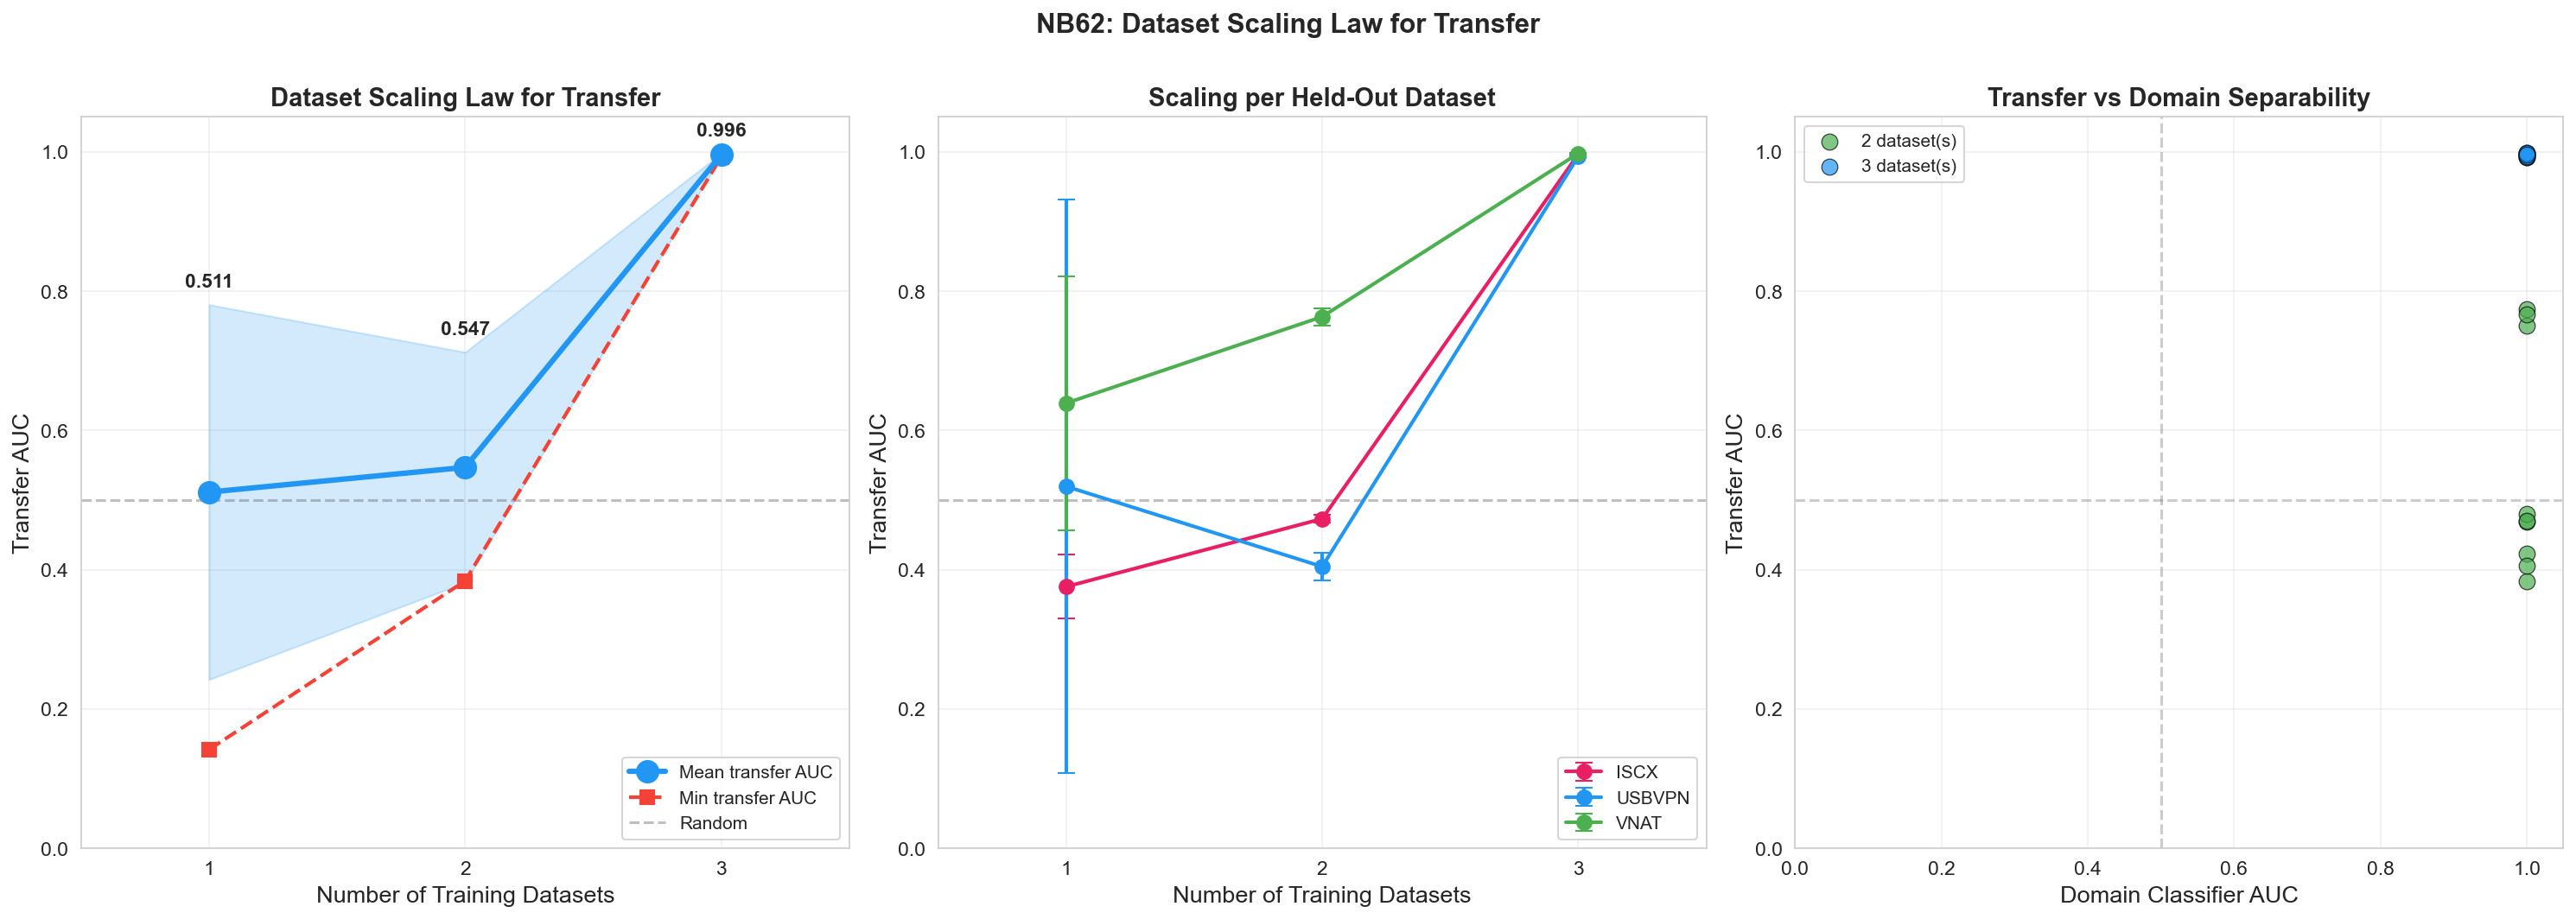

---
### — Deployment Robustness Curves
`deployment_robustness_curves.png`

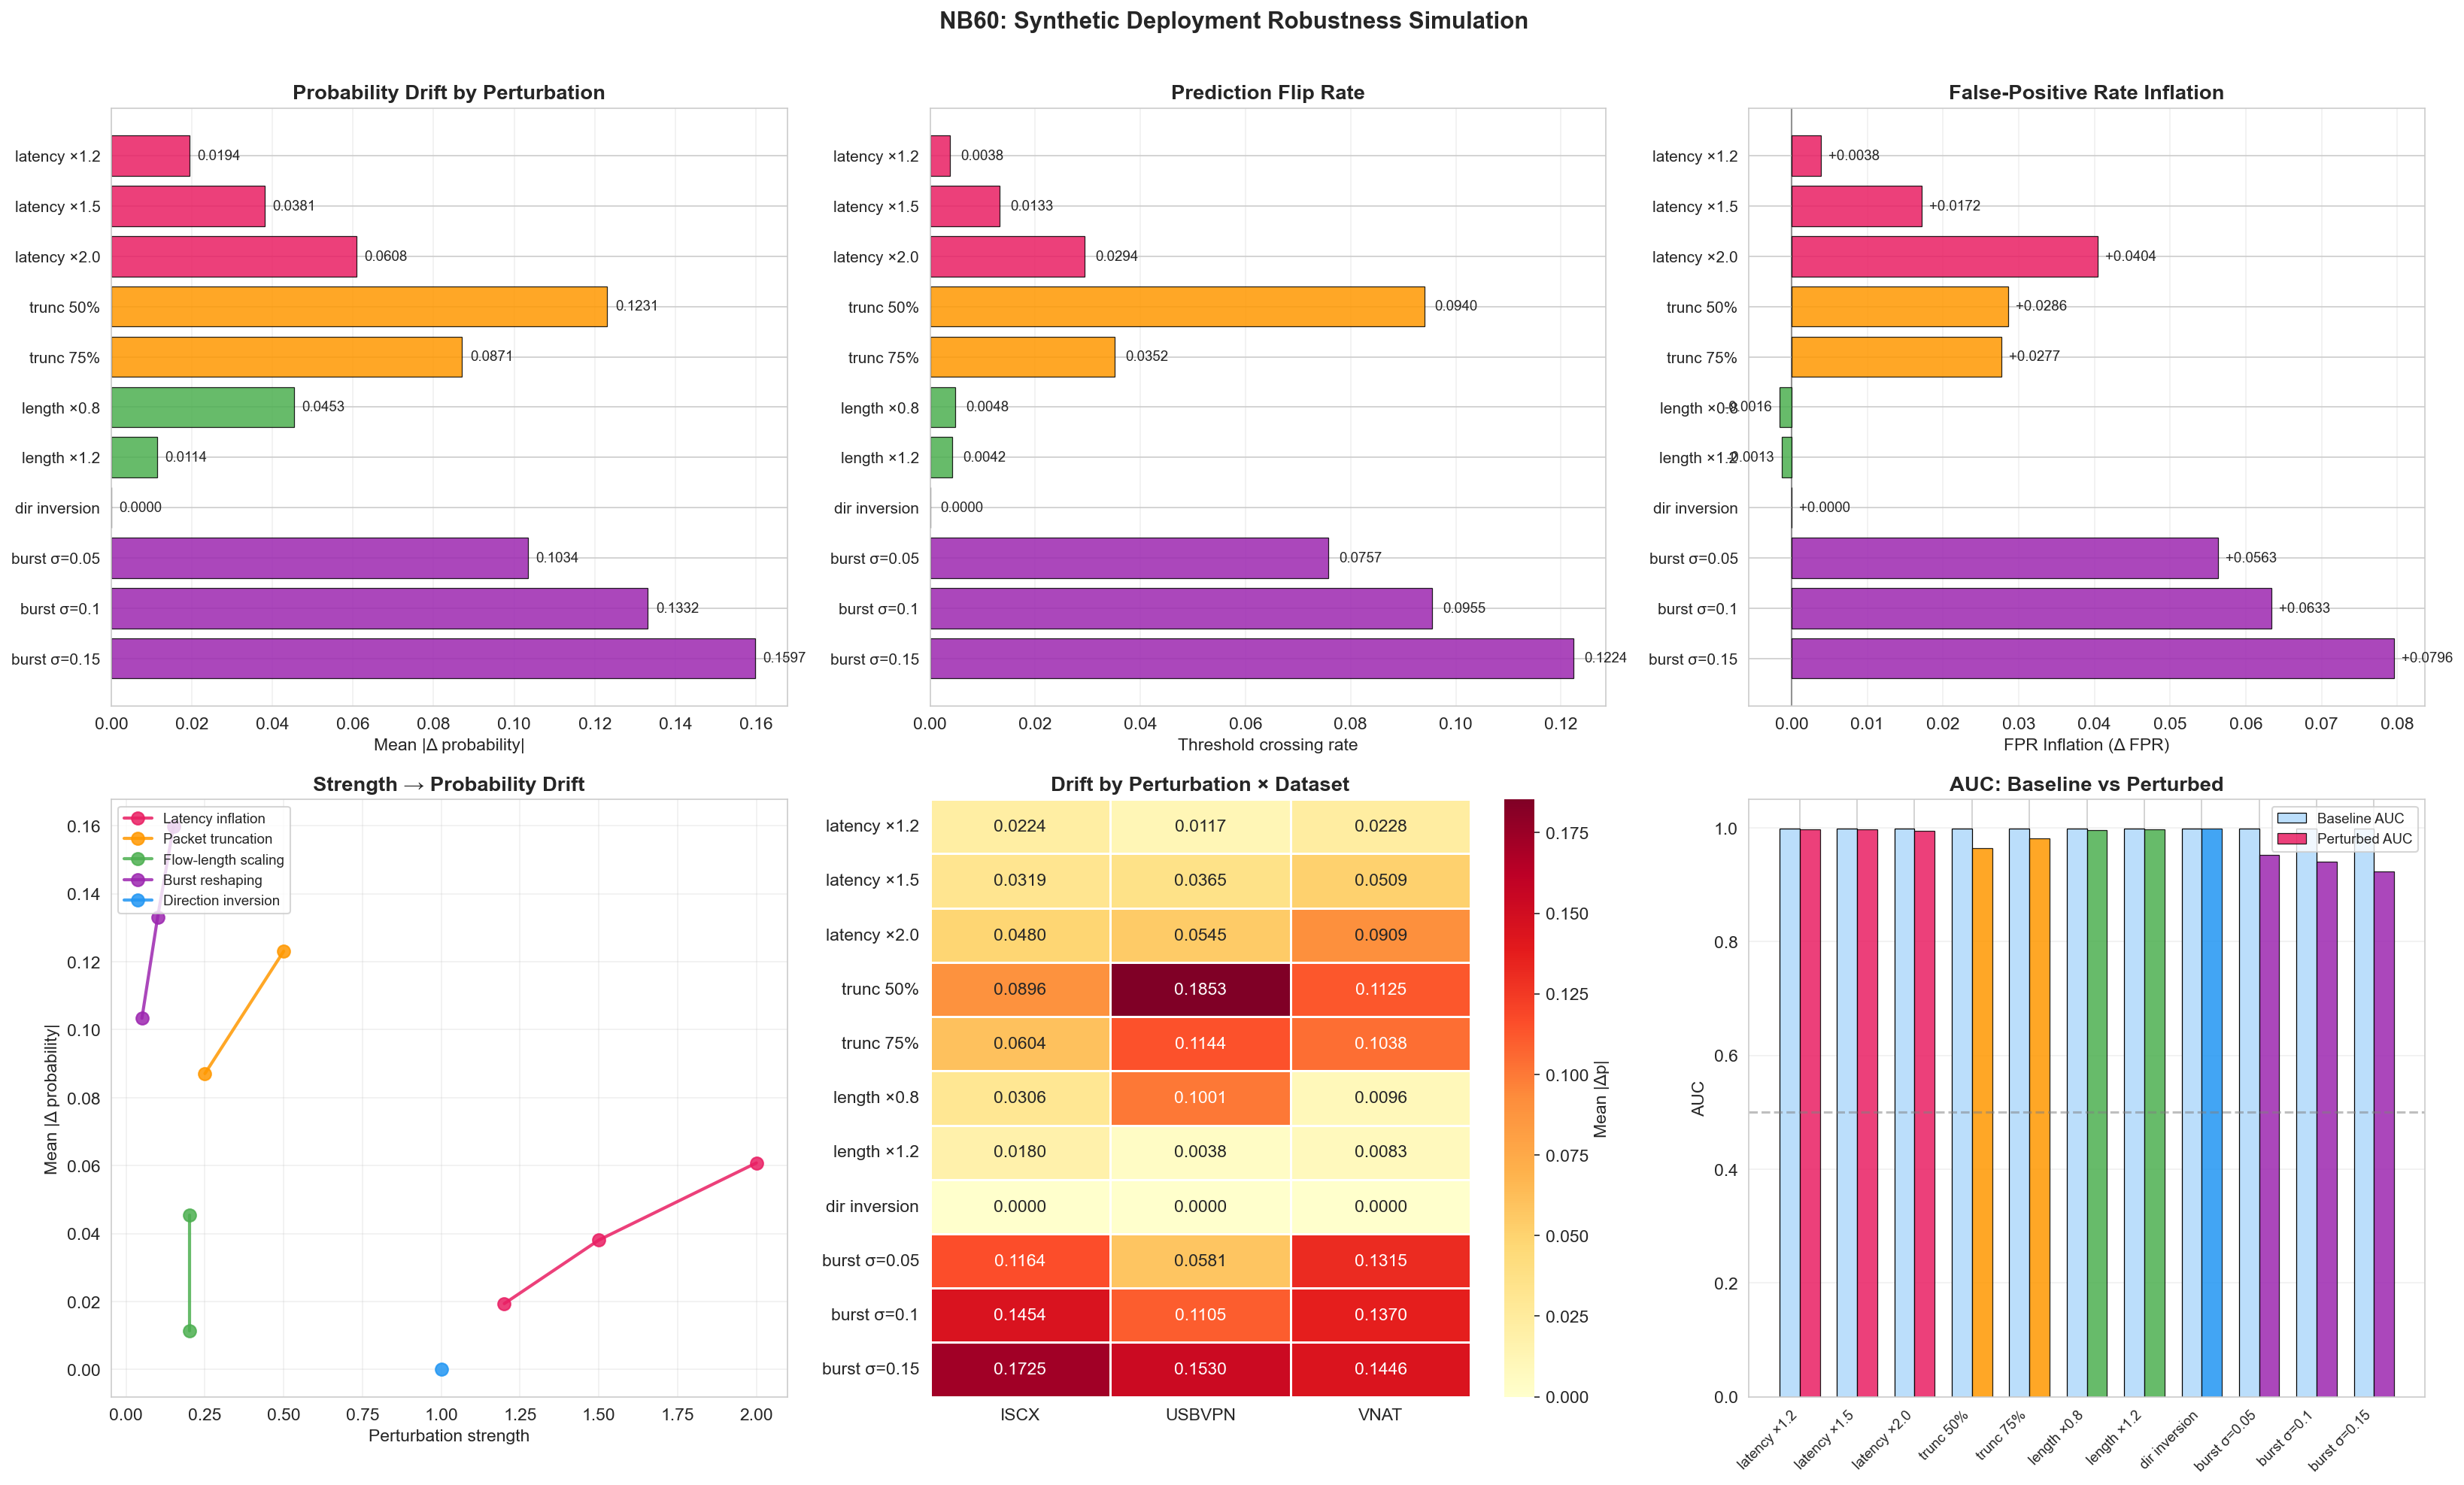

---
### — Deployment Robustness Distributions
`deployment_robustness_distributions.png`

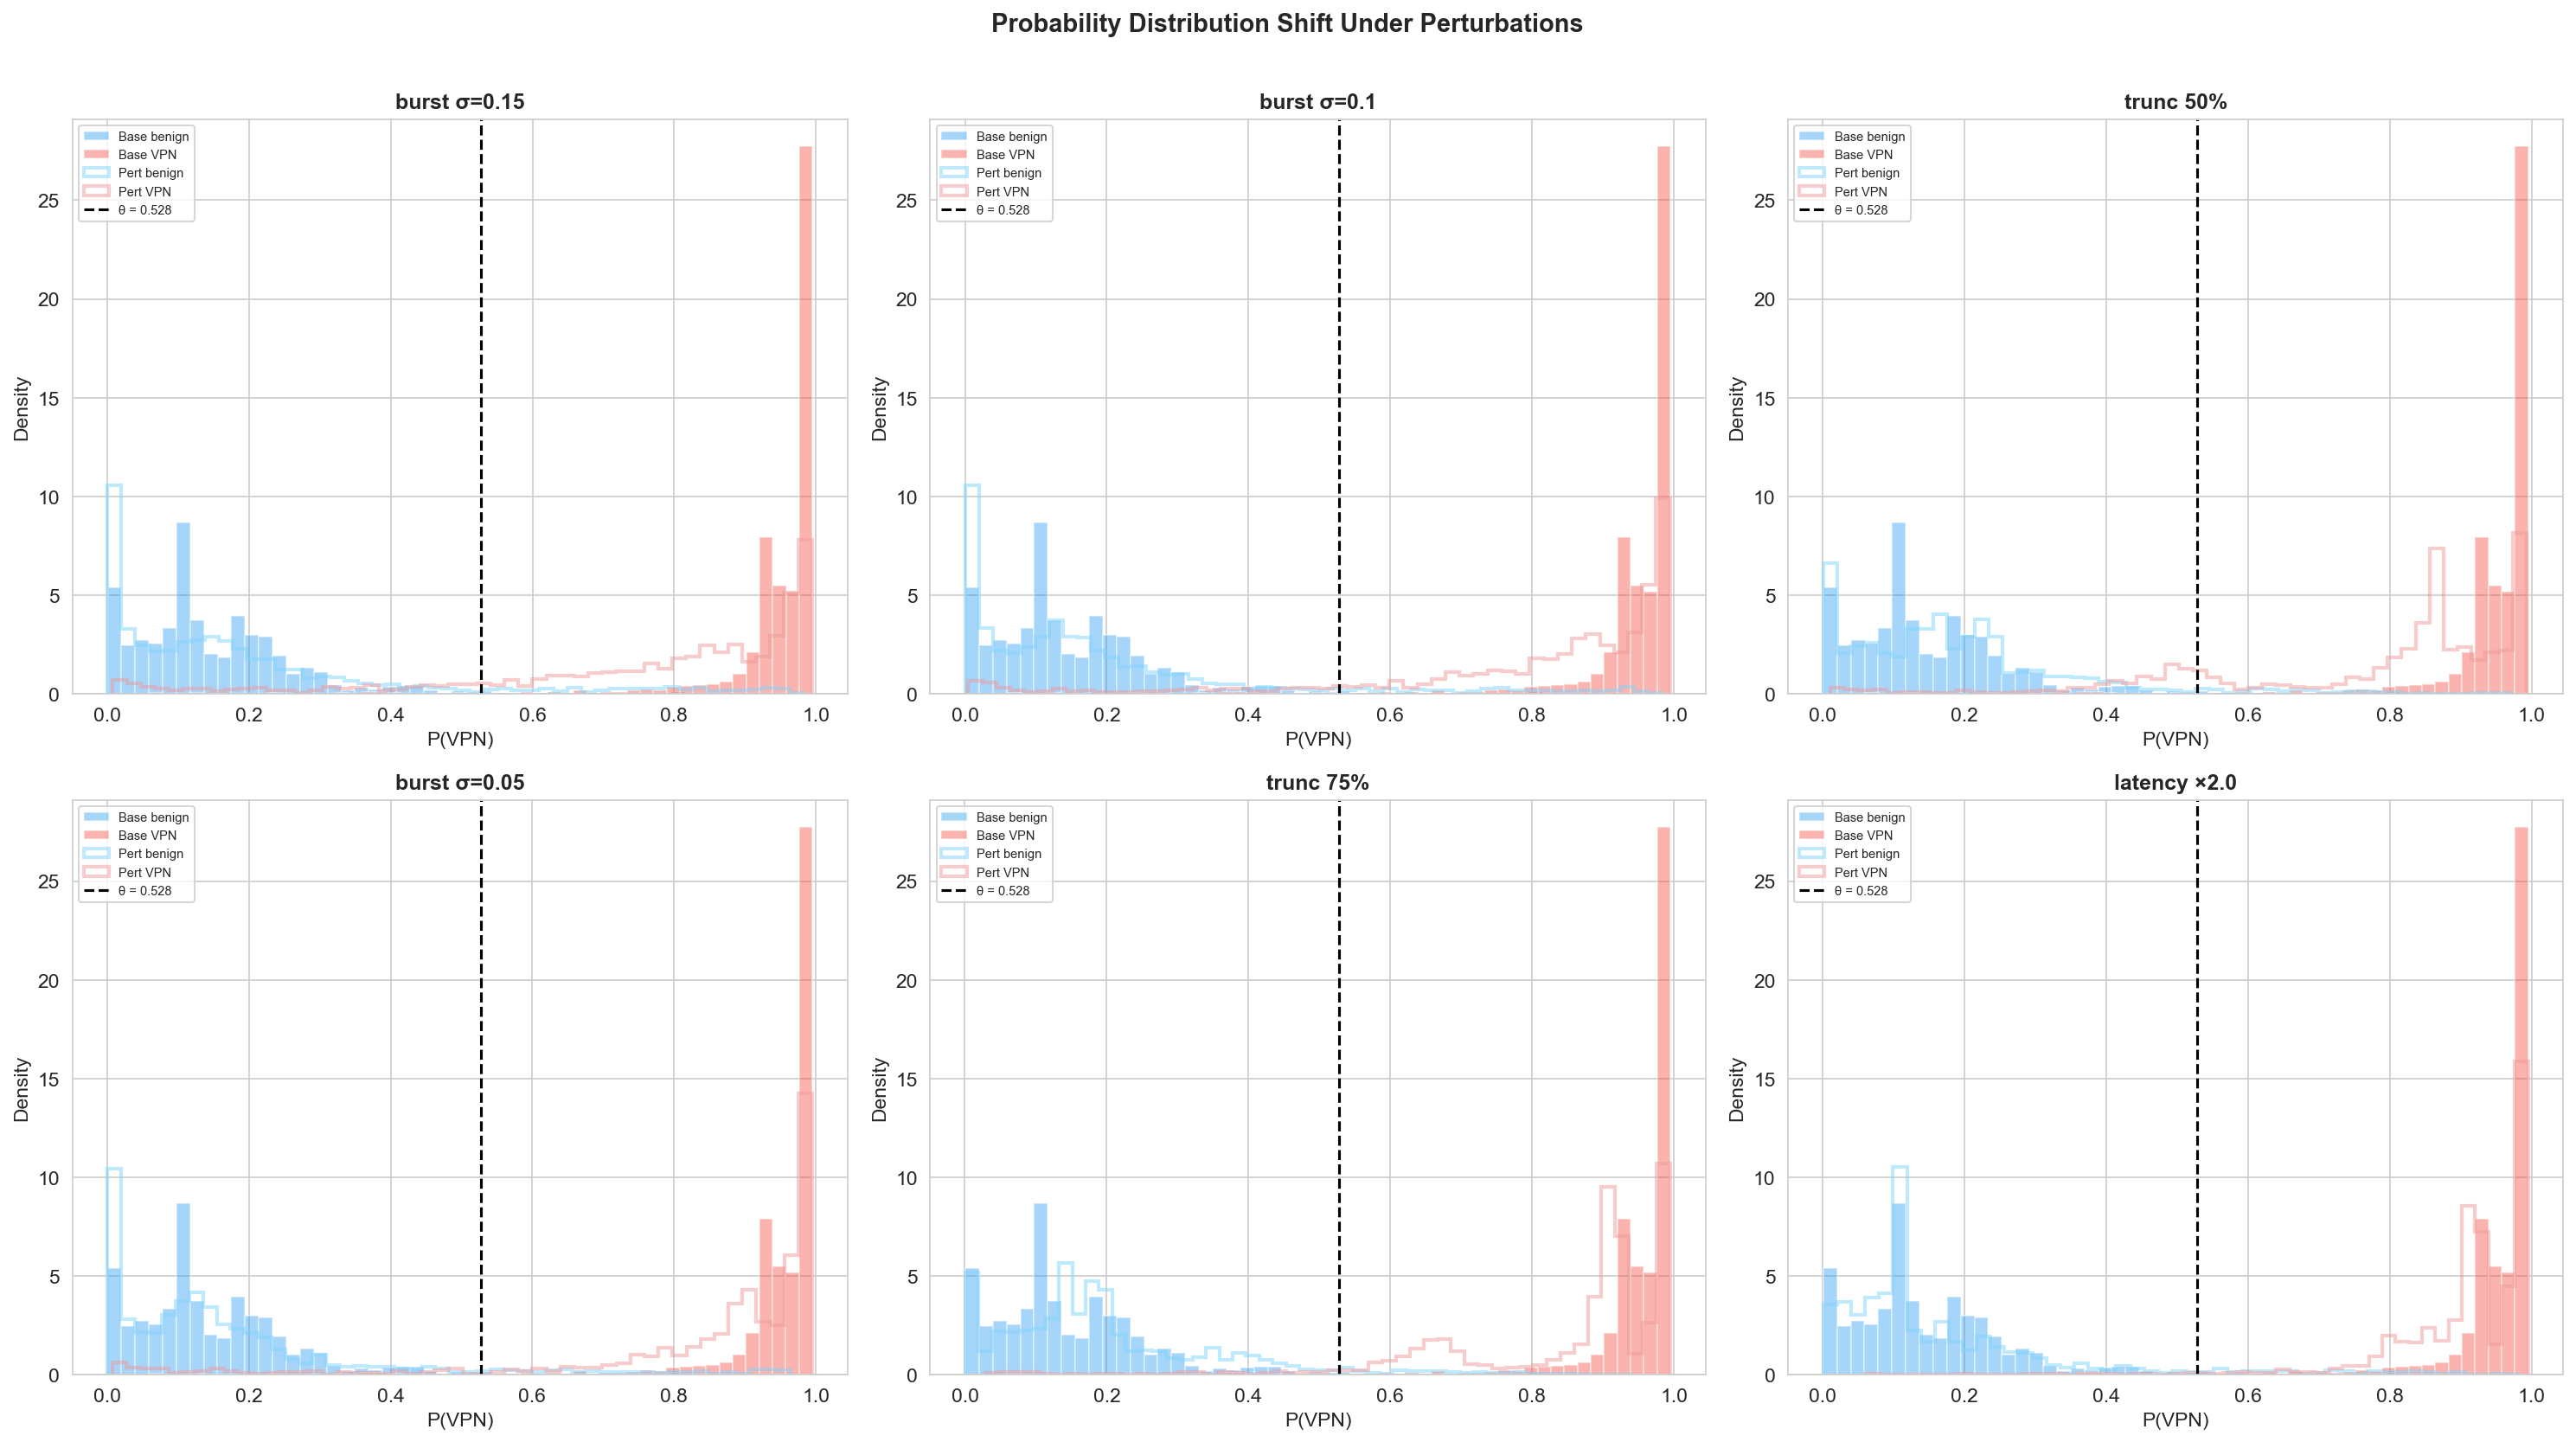

---
### — Deployment Stability Curve
`deployment_stability_curve.png`

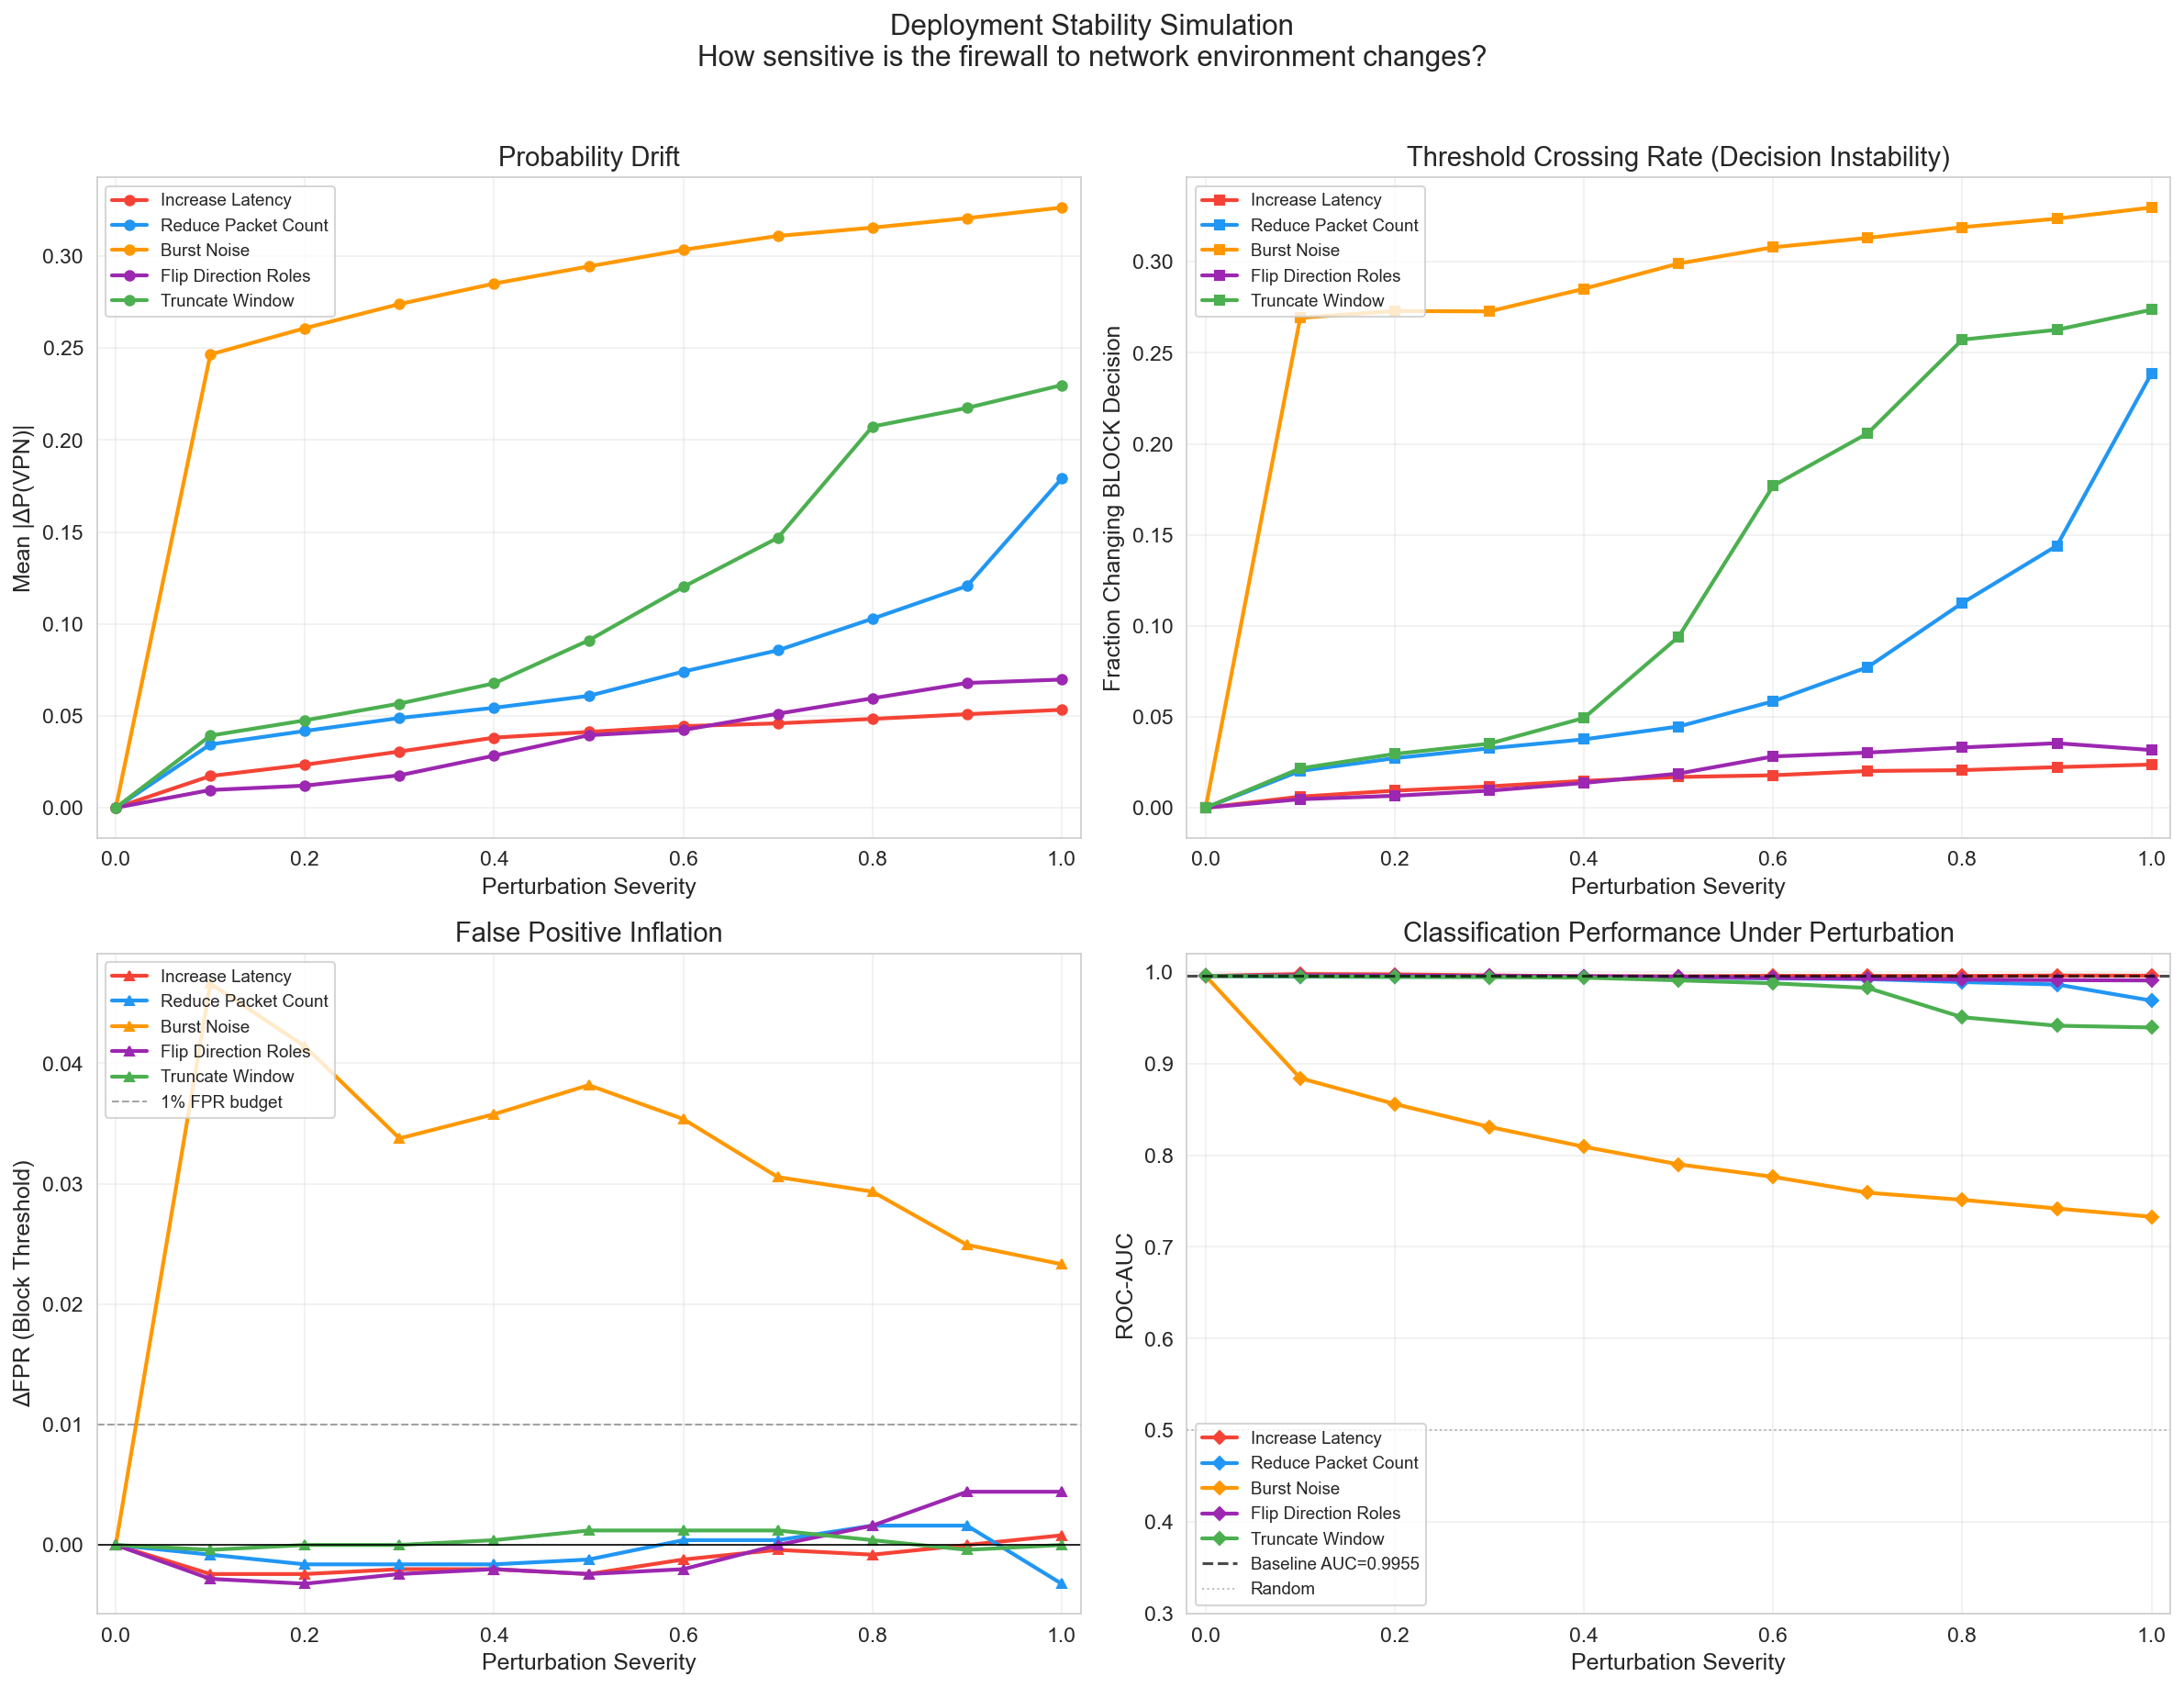

---
### — Sign Reversal Transfer Plot
`sign_reversal_transfer_plot.png`

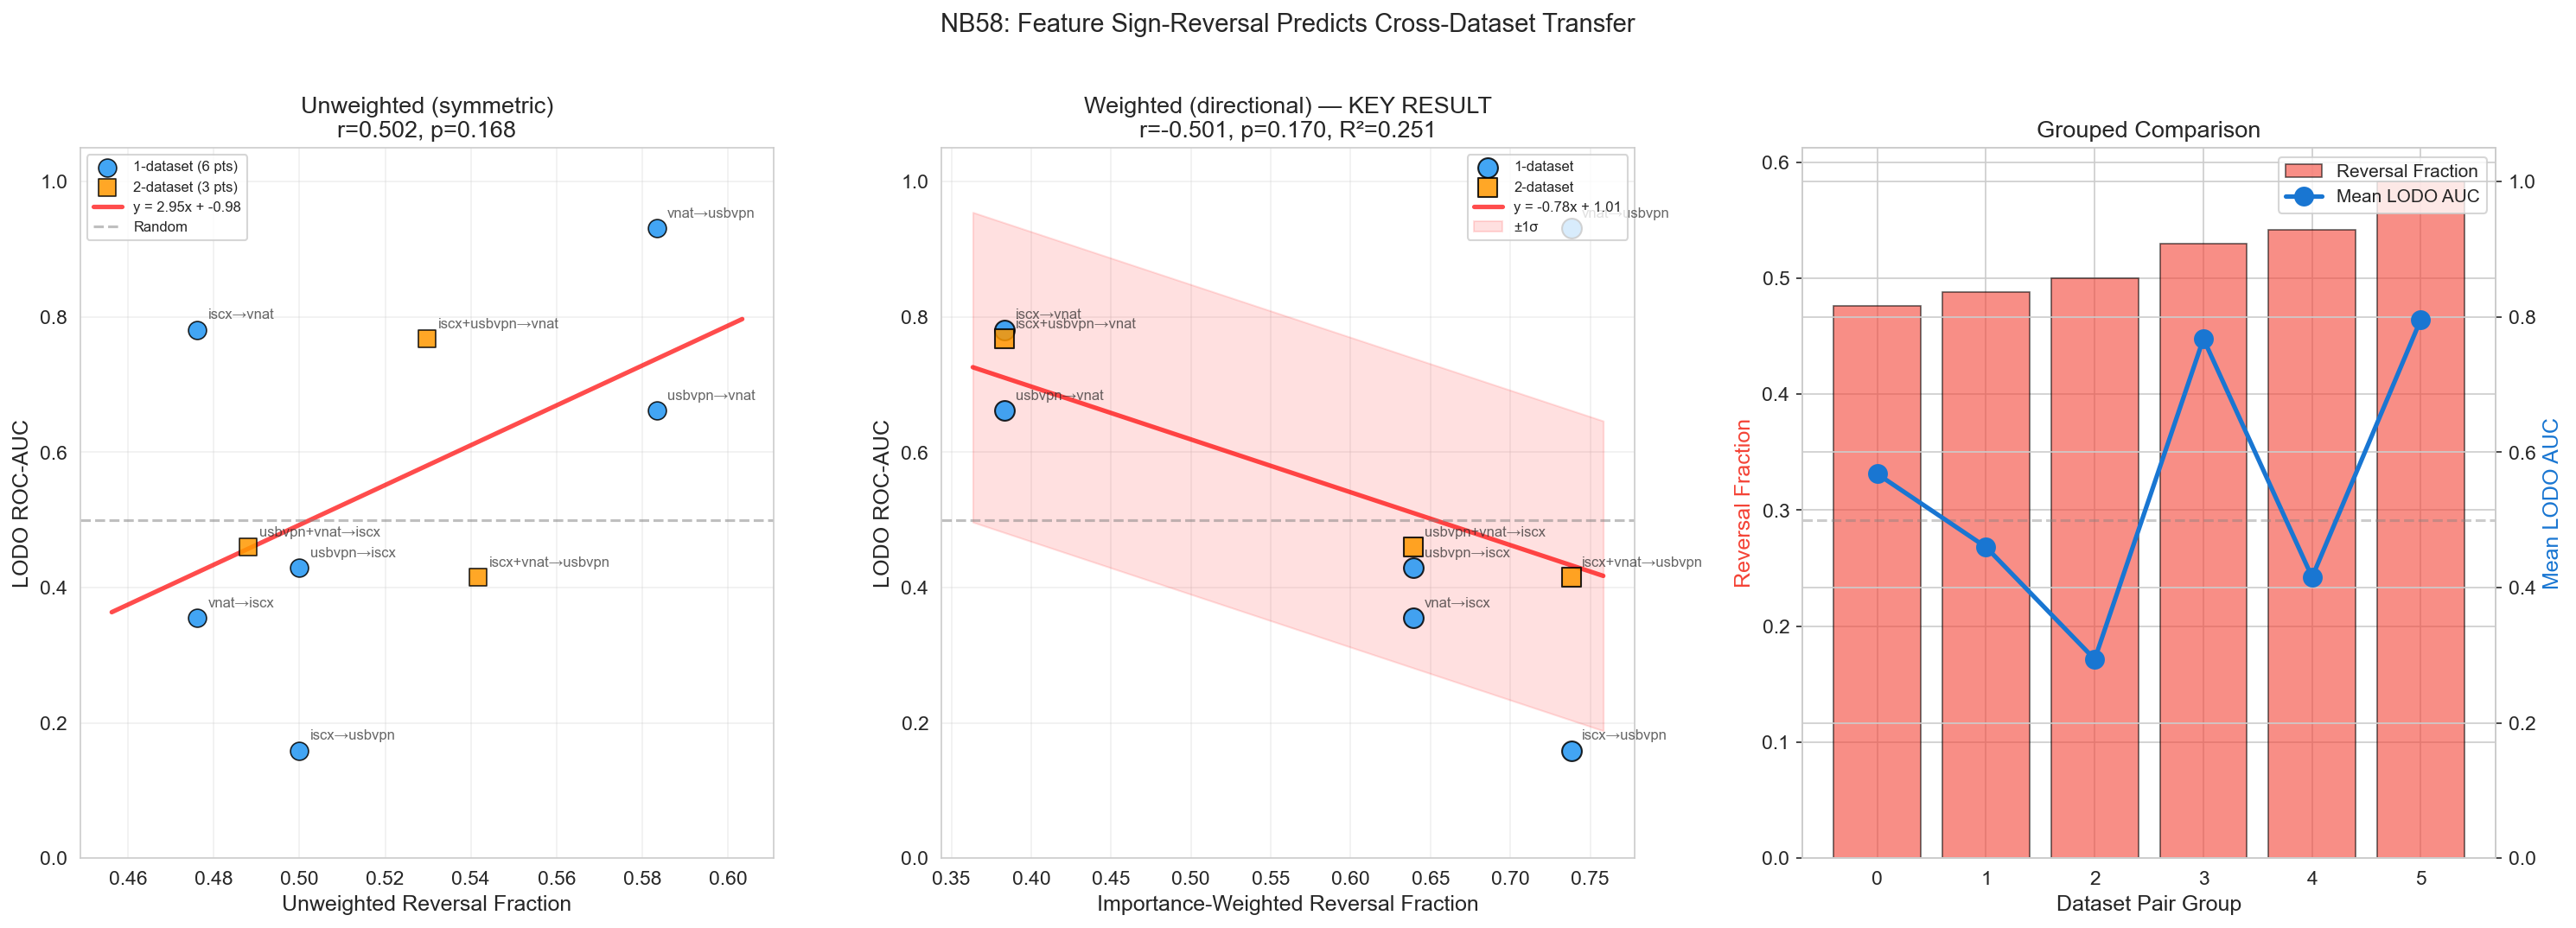

---
### — Stable vs Reversing Transfer Plot
`stable_vs_reversing_transfer_plot.png`

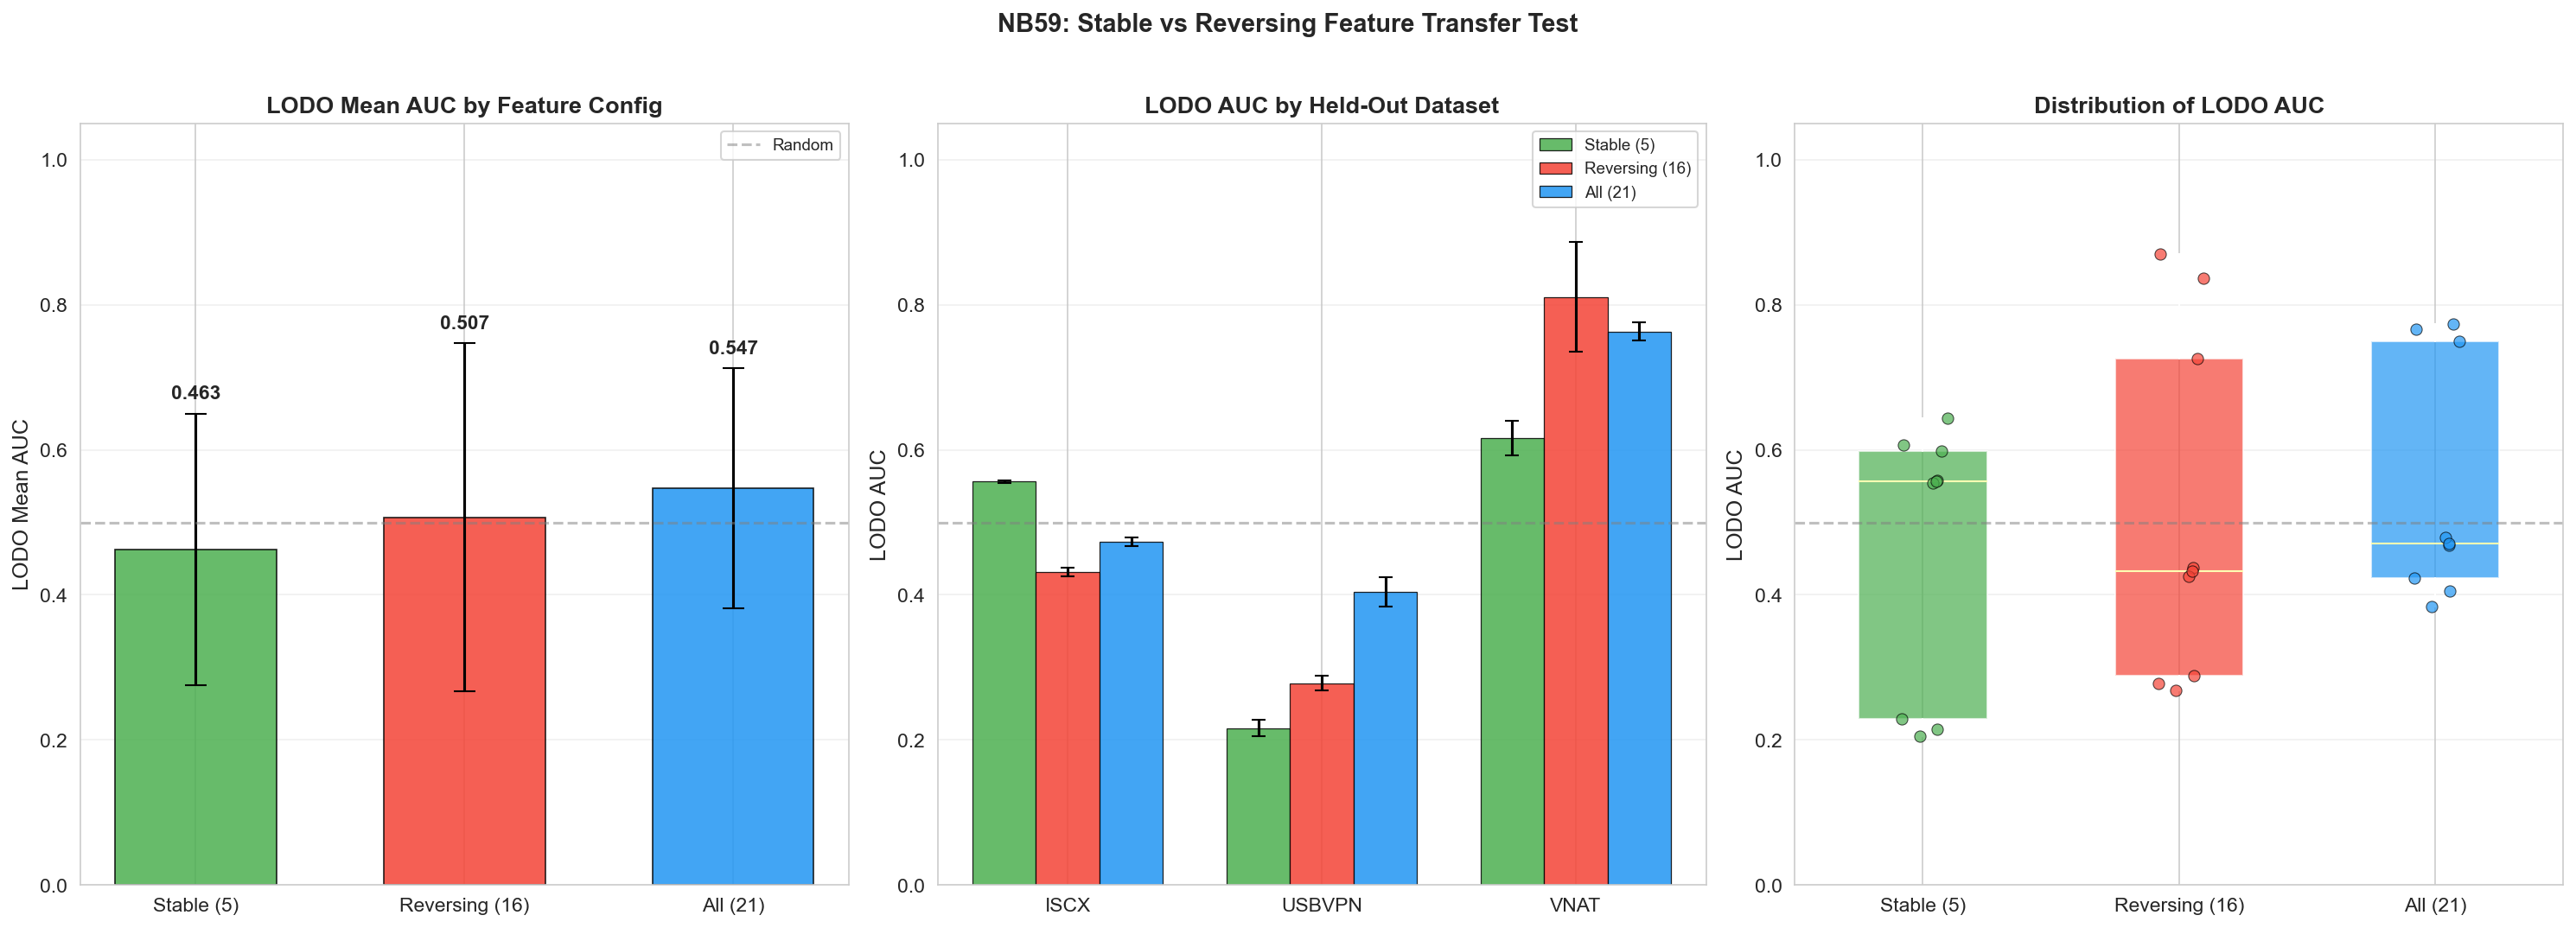

---
### — UMAP: Combined Panel
`umap_combined_panel.png`

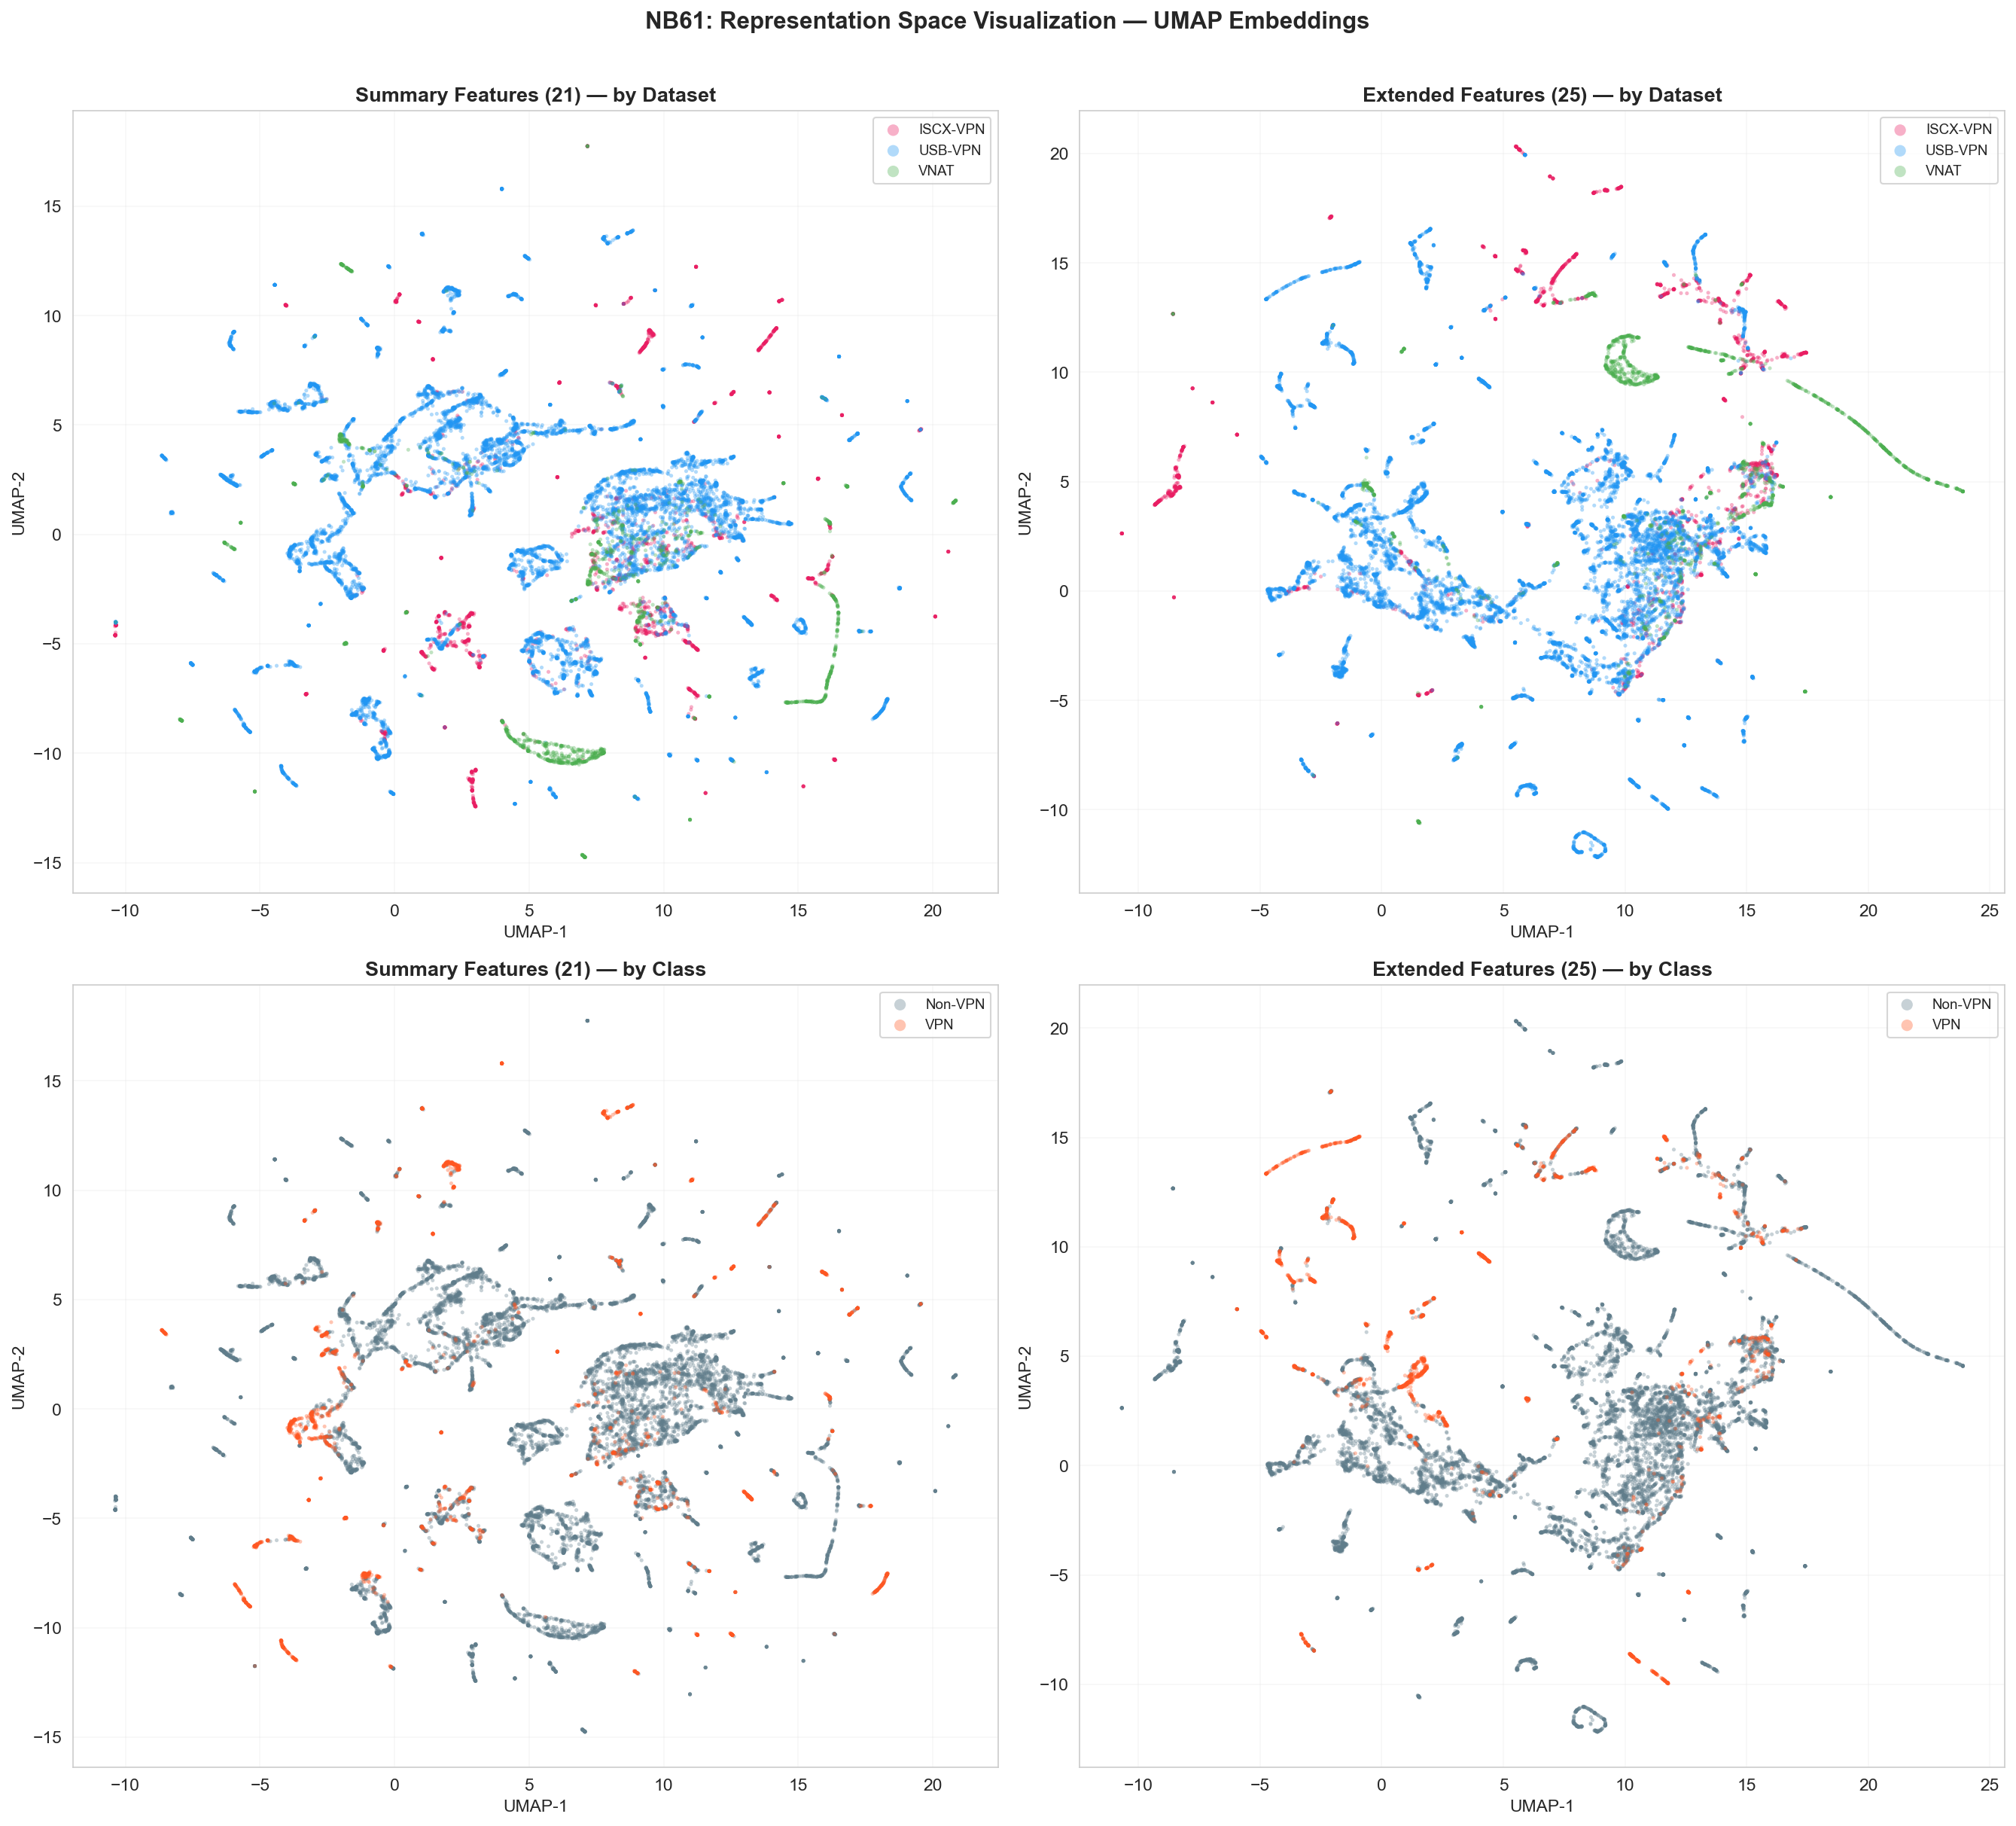

---
### — UMAP: Sequence + Class
`umap_sequence_class.png`

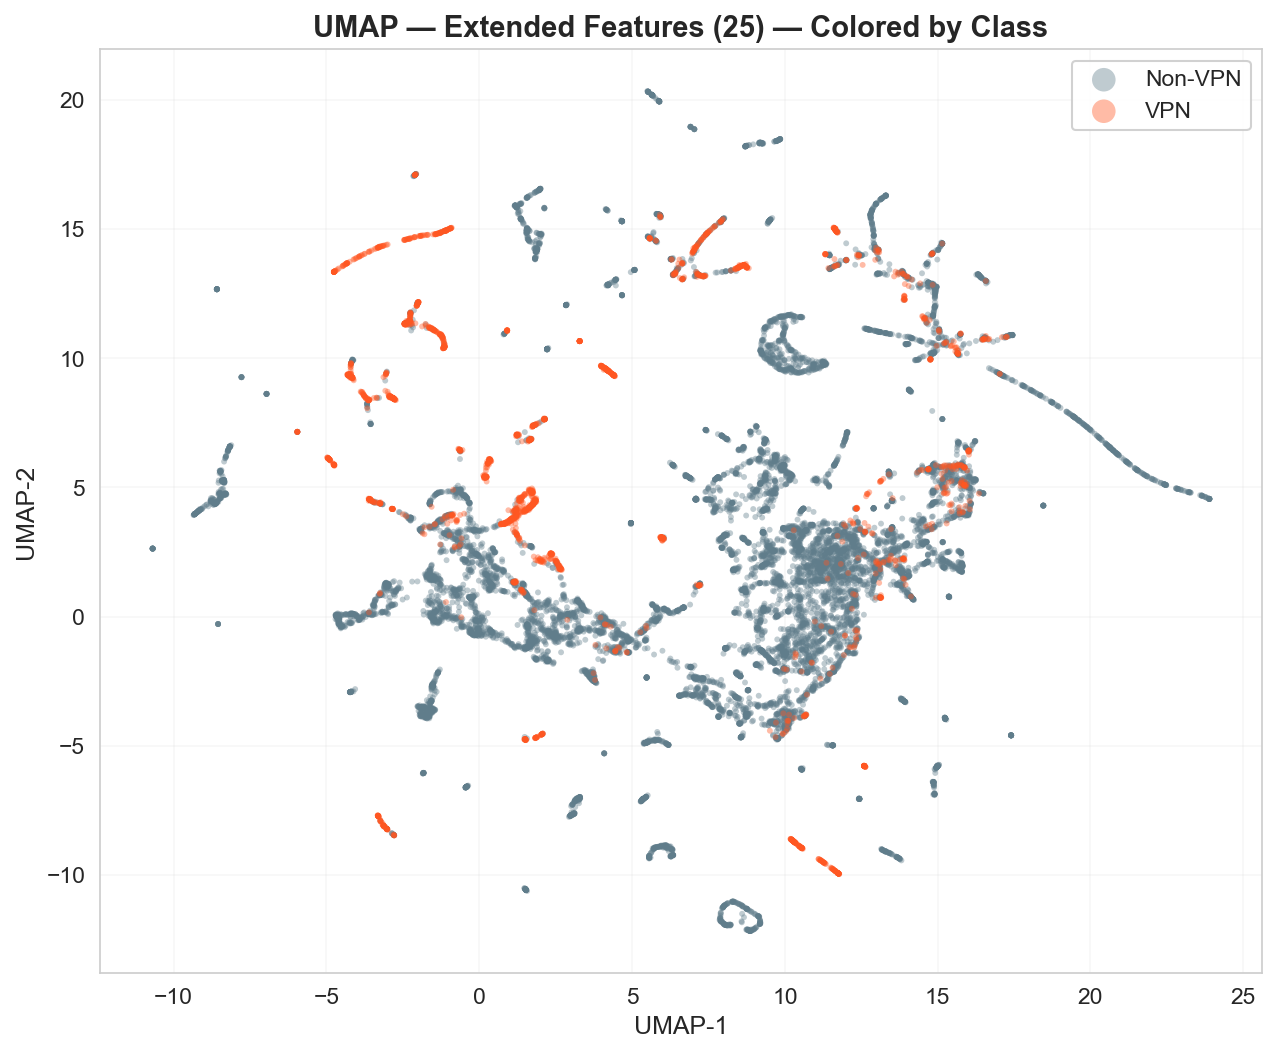

---
### — UMAP: Sequence + Dataset
`umap_sequence_dataset.png`

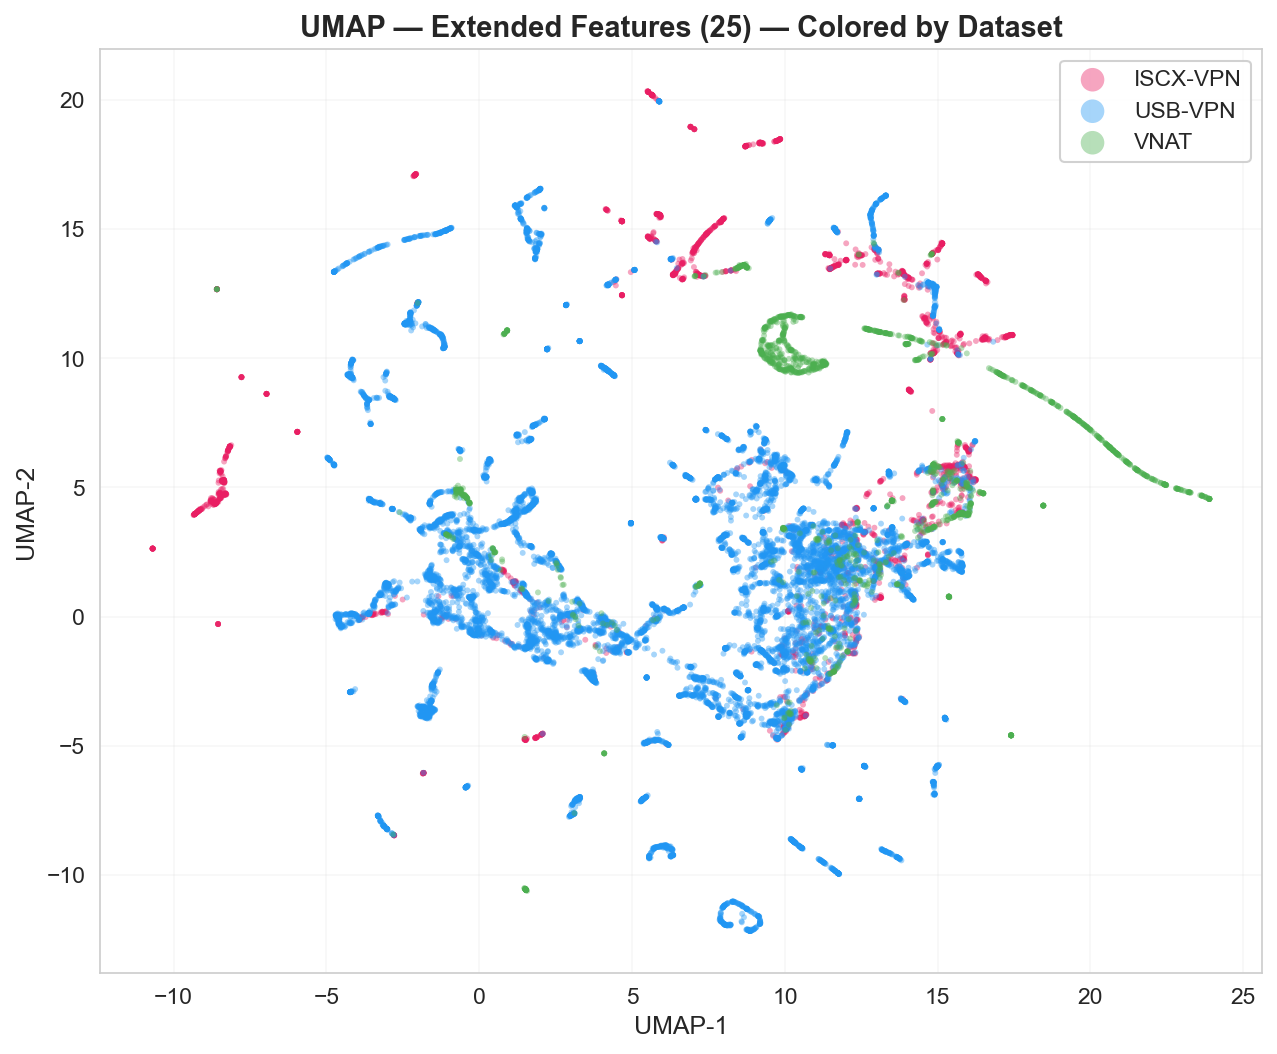

---
### — UMAP: Summary + Class
`umap_summary_class.png`

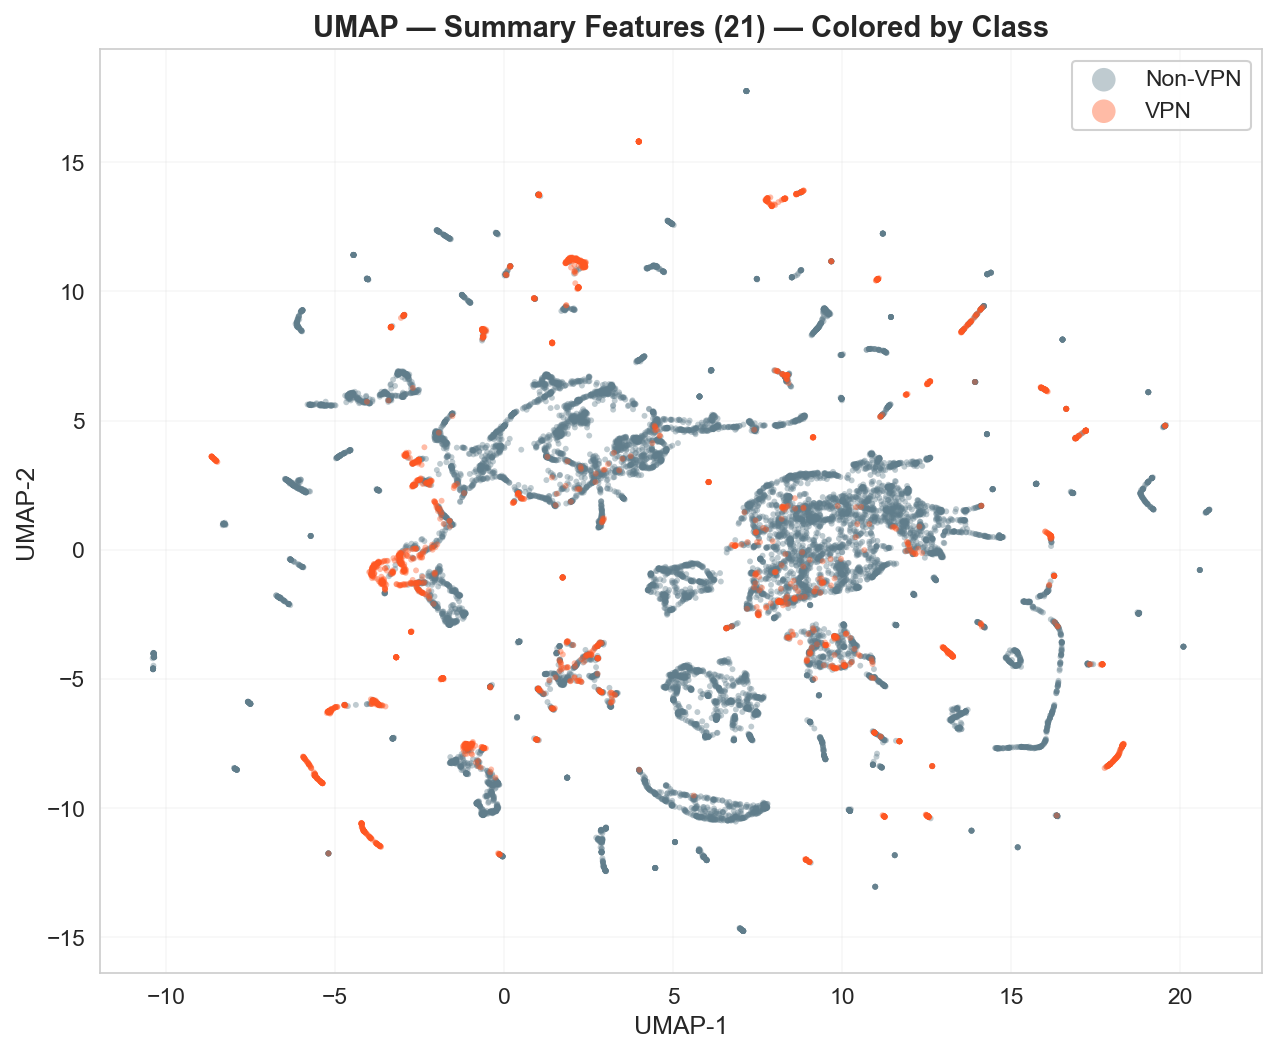

---
### — UMAP: Summary + Dataset
`umap_summary_dataset.png`

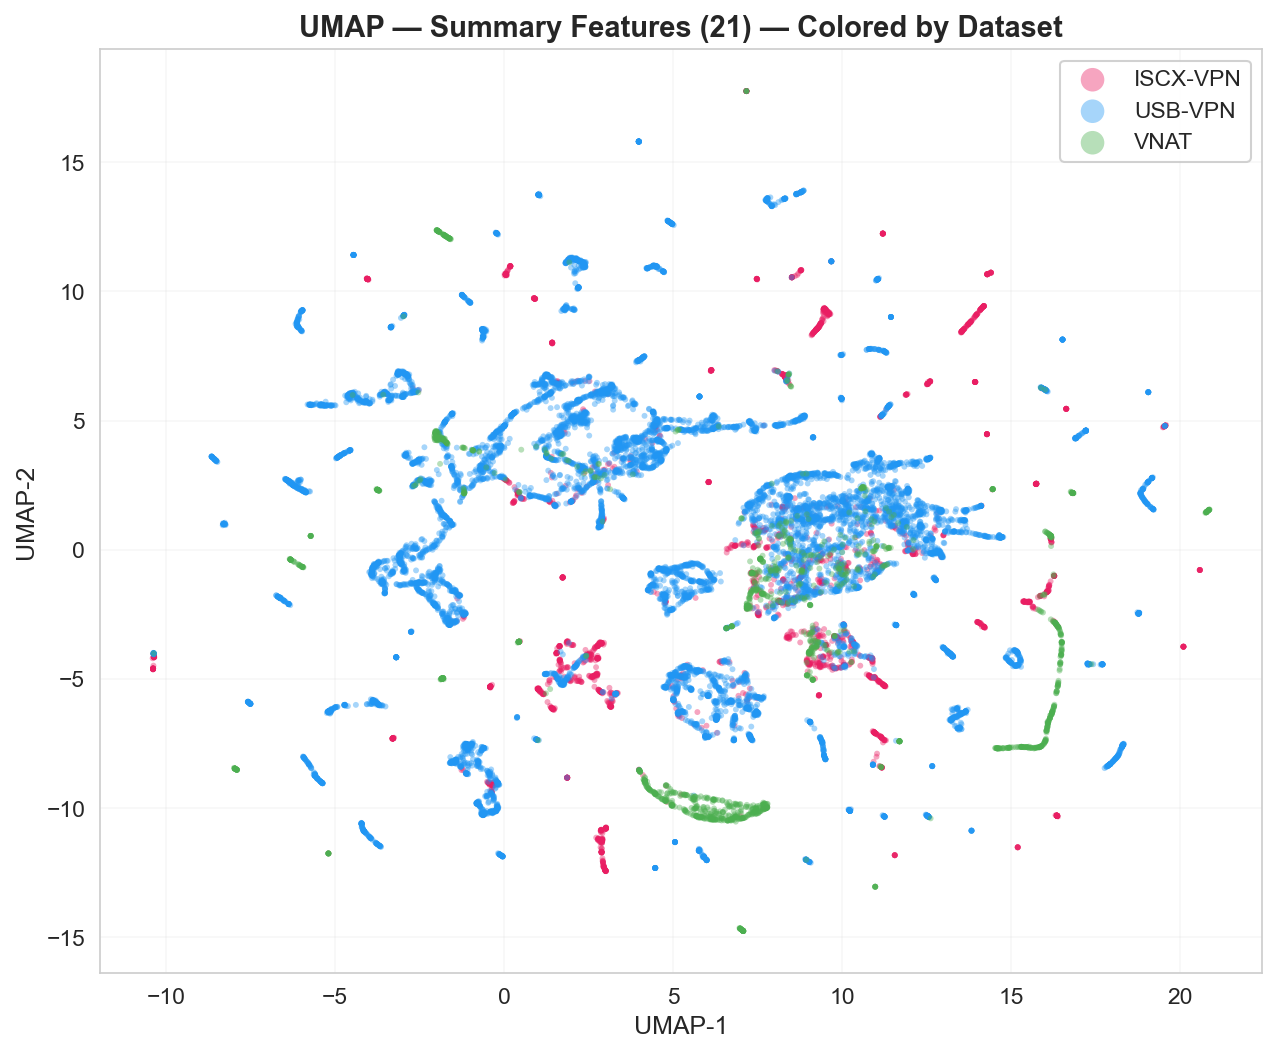


✅ NB57 gallery complete.


In [2]:
# ── Results Gallery: NB57 — Display all figures and tables ────────
import sys, json
from pathlib import Path
import pandas as pd
from IPython.display import display, Image, Markdown

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent

CONF  = ROOT / "artifacts" / "conference_eval"
FIGS  = CONF / "figures"
_EVAL = ROOT / "artifacts" / "eval"

# ── 10 conference experiments: CSV tables ──────────────────────

csv_manifest = [
    ("1. Domain Generalization Curves",       "domain_generalization_curve.csv",         CONF),
    ("2. Temporal Shift Simulation",          "temporal_shift_results.csv",              CONF),
    ("3. Sign Reversal Matrix",               "sign_reversal_matrix.csv",                CONF),
    ("4. Domain-Invariant Feature Discovery", "domain_invariant_feature_subset.csv",     CONF),
    ("5. Domain Fingerprint Analysis",        "sequence_domain_fingerprint_results.csv", CONF),
    ("6. Adversarial Domain Confusion Test",  "domain_confusion_results.csv",            CONF),
    ("8. Fourth Dataset Integration",         "four_dataset_transfer_results.csv",       CONF),
    ("9. Deployment Stability Simulation",    "deployment_stability_results.csv",        CONF),
    ("10. Firewall Operating Points",         "firewall_operating_points.csv",           _EVAL),
    ("— Dataset Scaling Curve",               "dataset_scaling_curve.csv",               CONF),
    ("— Dataset Scaling (full)",              "dataset_scaling_curve_full.csv",          CONF),
    ("— Deployment Robustness",               "deployment_robustness_results.csv",       CONF),
    ("— Feature Importance Stability",        "feature_importance_stability.csv",        CONF),
    ("— Sign Reversal Transfer Regression",   "sign_reversal_transfer_regression.csv",   CONF),
    ("— Stable vs Reversing Transfer",        "stable_vs_reversing_transfer.csv",        CONF),
    ("— Stable vs Reversing Transfer (full)", "stable_vs_reversing_transfer_full.csv",   CONF),
    ("— UMAP Cluster Analysis",              "umap_cluster_analysis.csv",               CONF),
]

display(Markdown("# 📋 Conference Evaluation — All CSV Tables\n"))
for title, fname, directory in csv_manifest:
    p = directory / fname
    if p.exists():
        try:
            tbl = pd.read_csv(p)
            display(Markdown(f"### {title}\n`{fname}`"))
            for col in tbl.select_dtypes(include="float").columns:
                tbl[col] = tbl[col].map(lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")
            display(tbl)
        except Exception as e:
            print(f"  ⚠ Could not load {fname}: {e}")
    else:
        print(f"  ✗ {fname} — not found")

# ── JSON summaries ────────────────────────────────────────────

json_files = [
    ("Dataset Scaling Summary",       "dataset_scaling_summary.json"),
    ("Deployment Robustness Summary", "deployment_robustness_summary.json"),
    ("UMAP Representation Summary",   "umap_representation_summary.json"),
]

display(Markdown("\n---\n# 🏁 JSON Summaries\n"))
for title, fname in json_files:
    p = CONF / fname
    if p.exists():
        data = json.loads(p.read_text(encoding="utf-8"))
        display(Markdown(f"### {title}\n`{fname}`"))
        display(Markdown(f"```json\n{json.dumps(data, indent=2, default=str)[:4000]}\n```"))

# ── PNG figures ───────────────────────────────────────────────

png_manifest = [
    ("1. Domain Generalization Curve",          "domain_generalization_curve.png"),
    ("2. Temporal Shift Results",               "temporal_shift_results.png"),
    ("3. Sign Reversal Heatmap",                "sign_reversal_heatmap.png"),
    ("5. Domain Fingerprint Comparison",        "domain_fingerprint_comparison.png"),
    ("6. Domain Confusion Results",             "domain_confusion_results.png"),
    ("7. Embedding Visualization (t-SNE/UMAP)", "embedding_visualization.png"),
    ("— Dataset Scaling Curve",                 "dataset_scaling_curve.png"),
    ("— Deployment Robustness Curves",          "deployment_robustness_curves.png"),
    ("— Deployment Robustness Distributions",   "deployment_robustness_distributions.png"),
    ("— Deployment Stability Curve",            "deployment_stability_curve.png"),
    ("— Sign Reversal Transfer Plot",           "sign_reversal_transfer_plot.png"),
    ("— Stable vs Reversing Transfer Plot",     "stable_vs_reversing_transfer_plot.png"),
    ("— UMAP: Combined Panel",                  "umap_combined_panel.png"),
    ("— UMAP: Sequence + Class",                "umap_sequence_class.png"),
    ("— UMAP: Sequence + Dataset",              "umap_sequence_dataset.png"),
    ("— UMAP: Summary + Class",                 "umap_summary_class.png"),
    ("— UMAP: Summary + Dataset",               "umap_summary_dataset.png"),
]

display(Markdown("\n---\n# 🖼 Conference Evaluation — All Figures\n"))
for title, fname in png_manifest:
    p = CONF / fname
    if not p.exists():
        p = FIGS / fname          # also check figures/ subdirectory
    if p.exists():
        display(Markdown(f"---\n### {title}\n`{fname}`"))
        try:
            display(Image(filename=str(p), width=900))
        except Exception as e:
            print(f"  ⚠ Could not display {fname}: {e}")
    else:
        print(f"  ✗ {fname} — not found")

print("\n✅ NB57 gallery complete.")